# Figure 4 analyses

This notebook now contains four Figure 4 components:

1. Wildtype-vs-wildtype structural alignment using TM-align.
2. Selected wildtype/variant RMSF comparisons transferred from the original notebook.
3. A replicate-aware MD variant-family comparison workflow built from the combined metric CSVs in `Data/Figure4/Round_3_additional_metric_csvs/by_metric`.
4. WT ChimeraX coloring commands that average WT-relative residue signals across all variants in each family.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Scripts':
    PROJECT_ROOT = PROJECT_ROOT.parent

HELPER_DIR = PROJECT_ROOT / 'Scripts' / 'Helpers'
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

import helper_fugure4
importlib.reload(helper_fugure4)

build_symmetric_pair_metric_matrix = helper_fugure4.build_symmetric_pair_metric_matrix
build_variant_pair_summary_df = helper_fugure4.build_variant_pair_summary_df
compute_variant_delta_rmsf_df = helper_fugure4.compute_variant_delta_rmsf_df
compute_wildtype_similarity_table = helper_fugure4.compute_wildtype_similarity_table
discover_md_rmsf_catalog = helper_fugure4.discover_md_rmsf_catalog
discover_structure_families = helper_fugure4.discover_structure_families
filter_rmsf_to_allowed_variants = helper_fugure4.filter_rmsf_to_allowed_variants
filter_tm_summary_by_minimum_melting_temperature = helper_fugure4.filter_tm_summary_by_minimum_melting_temperature
filter_variant_delta_rmsf_df = helper_fugure4.filter_variant_delta_rmsf_df
load_md_rmsf_long_df = helper_fugure4.load_md_rmsf_long_df
load_tsa_tm_delta_summary = helper_fugure4.load_tsa_tm_delta_summary
build_tm_delta_row_label_map = helper_fugure4.build_tm_delta_row_label_map
build_tm_median_sort_map = helper_fugure4.build_tm_median_sort_map
plot_family_rmsf_overview = helper_fugure4.plot_family_rmsf_overview
plot_pairwise_metric_heatmap = helper_fugure4.plot_pairwise_metric_heatmap
plot_variant_pair_rmsf = helper_fugure4.plot_variant_pair_rmsf
plot_wildtype_tm_score_boxplot = helper_fugure4.plot_wildtype_tm_score_boxplot

build_md_variant_analysis_bundle = helper_fugure4.build_md_variant_analysis_bundle
compute_md_family_pair_interest_df = helper_fugure4.compute_md_family_pair_interest_df
compute_md_family_residue_interest_df = helper_fugure4.compute_md_family_residue_interest_df
compute_md_variant_order = helper_fugure4.compute_md_variant_order
plot_md_family_delta_heatmap = helper_fugure4.plot_md_family_delta_heatmap
plot_md_family_local_signal_heatmap = helper_fugure4.plot_md_family_local_signal_heatmap
plot_md_family_pair_heatmaps = helper_fugure4.plot_md_family_pair_heatmaps
plot_md_family_rmsf_panels = helper_fugure4.plot_md_family_rmsf_panels
plot_md_family_secondary_structure_summary = helper_fugure4.plot_md_family_secondary_structure_summary
plot_md_variant_family_pattern_heatmap = helper_fugure4.plot_md_variant_family_pattern_heatmap
plot_md_variant_pair_delta_bars = helper_fugure4.plot_md_variant_pair_delta_bars
plot_md_variant_signal_dashboard = helper_fugure4.plot_md_variant_signal_dashboard
save_md_variant_figure = helper_fugure4.save_md_variant_figure
export_md_variant_molstar_views = helper_fugure4.export_md_variant_molstar_views
export_wildtype_overlay_molstar_views = helper_fugure4.export_wildtype_overlay_molstar_views
export_wildtype_superposition_molstar_view = helper_fugure4.export_wildtype_superposition_molstar_view
build_wildtype_chimerax_command_bundle = helper_fugure4.build_wildtype_chimerax_command_bundle
build_wildtype_chimerax_interaction_gain_focus_table = helper_fugure4.build_wildtype_chimerax_interaction_gain_focus_table
build_variant_chimerax_interaction_closeup_table = helper_fugure4.build_variant_chimerax_interaction_closeup_table
MD_VARIANT_PAIR_METRICS = helper_fugure4.MD_VARIANT_PAIR_METRICS

plt.style.use('default')
pd.set_option('display.max_colwidth', 200)


In [2]:
FIGURE4_STRUCTURE_DIR = PROJECT_ROOT / 'Data' / 'Figure4'
THERMALGAN_MD_ANALYSIS_DIR = Path(
    '../Data/Figure4/MD_Analysis'
)
TSA_RESULT_SUMMARY_PATH = Path(
    '../Data/Figure3/TSA_summary_round3.csv'
)
FIGURE4_OUTPUT_DIR = PROJECT_ROOT / 'Results' / 'Figure4'

FIGURE4_MD_METRIC_DIR = PROJECT_ROOT / 'Data' / 'Figure4' / 'Round_3_additional_metric_csvs' / 'by_metric'
FIGURE4_MD_MUTATION_METADATA_PATH = PROJECT_ROOT / 'Data' / 'Figure4' / 'mutation_metadata.csv'
FIGURE4_MD_OUTPUT_ROOT = PROJECT_ROOT / 'sandra' / 'MD_SIM' / 'Round_3_additional_metric_csvs'
FIGURE4_MD_METRIC_WINDOW = 'longest_stop_mixed_stop' #'latest'
# Options: 'latest', numeric stops like 100000/300000, full suffixes like '0_300000',
# or shared named suffixes like 'longest_stop_mixed_stop' / '0_longest_stop_mixed_stop'.
# 'latest' will use the largest shared window available across the required MD metric tables.
SAVE_MD_VARIANT_PLOTS = True

FIGURE4_MOLSTAR_OUTPUT_DIR = FIGURE4_OUTPUT_DIR / 'molstar'
FIGURE4_MOLSTAR_METRICS = ('rmsf', 'rmsd', 'hbond_pairs', 'saltbridge_pairs')
FIGURE4_MOLSTAR_Z_THRESHOLD = 1.5
FIGURE4_MOLSTAR_VIEWER_HEIGHT_PX = 560
FIGURE4_MOLSTAR_MAX_PREVIEWERS = 6
FIGURE4_WT_SUPERPOSITION_REFERENCE_FAMILY = None

TMALIGN_EXECUTABLE = None
TMALIGN_ALLOW_CA_FALLBACK = True
WT_TM_SCORE_BOXPLOT_WIDTH_MM = 30
WT_TM_SCORE_BOXPLOT_HEIGHT_MM = 50
WT_TM_PLOT_FONT_SIZE_PT = 5.5
WT_TM_PLOT_STRIP_MARKER_SIZE = 16
RMSF_OVERVIEW_FIGURE_WIDTH_MM = 150
RMSF_OVERVIEW_FIGURE_HEIGHT_MM = 100
RMSF_OVERVIEW_FONT_SIZE_PT = 5.5
DELTA_RMSF_FIGURE_WIDTH_MM = 110
DELTA_RMSF_FIGURE_ROW_HEIGHT_MM = 10.7
DELTA_RMSF_FIGURE_BASE_HEIGHT_MM = 45.7
DELTA_RMSF_FONT_SIZE_PT = 5.5
DELTA_RMSF_COLORBAR_HEIGHT_MM = 28
DELTA_RMSF_COLORBAR_WIDTH_MM = 4
DELTA_RMSF_COLORBAR_PAD_MM = 4
DELTA_RMSF_YTICK_FONTFAMILY = 'DejaVu Sans Mono'
DELTA_RMSF_YTICK_EXTRA_COLUMNS = 1
DELTA_RMSF_SHOW_YTICK_TM_METADATA = False
RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS = None
RMSF_OVERVIEW_EXCLUDE_MISSING_TM = False
SAVE_RMSF_OVERVIEW_PDFS = True

SELECTED_RMSF_VARIANTS_BY_FAMILY = {
    'A0A372IUB3': ['A0A372IUB3_1847_model_x_0', 'A0A372IUB3_1792_model_x_0'],
    'A0A2S1LEZ1': ['A0A2S1LEZ1_362_New_17444_0', 'A0A2S1LEZ1_337_New_17444_0'],
    'MGYP001421927114': ['MGYP001421927114_1306_model_x_0', 'MGYP001421927114_1344_model_x_0'],
}

FIGURE4_STRUCTURE_DIR, FIGURE4_MD_METRIC_DIR, FIGURE4_MD_MUTATION_METADATA_PATH, FIGURE4_MD_METRIC_WINDOW


(PosixPath('/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4'),
 PosixPath('/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/Round_3_additional_metric_csvs/by_metric'),
 PosixPath('/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/mutation_metadata.csv'),
 'longest_stop_mixed_stop')

## Wildtype Structural Similarity

This section keeps only the wildtype-vs-wildtype alignment from the source notebook. Variant-vs-wildtype structure comparisons are omitted.

,family_id,sample_name,pdb_path,is_wildtype
0,A0A2S1LEZ1,A0A2S1LEZ1,/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/A0A2S1LEZ1.pdb,True
1,A0A372IUB3,A0A372IUB3,/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/A0A372IUB3.pdb,True
2,MGYP001421927114,MGYP001421927114,/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/MGYP001421927114.pdb,True


Wildtype similarity method: official executable at /Users/sandravi/miniforge3/envs/jupyterlab/bin/TMalign


,wildtype_a,wildtype_b,mean_tm_score,tm_score_to_wildtype_a,tm_score_to_wildtype_b,rmsd_angstrom,aligned_length,alignment_method,alignment_note
0,A0A372IUB3,MGYP001421927114,0.970890,0.98623,0.95555,0.84,308,official_tmalign,Official TM-align/USalign executable
1,A0A2S1LEZ1,A0A372IUB3,0.970475,0.96583,0.97512,0.84,305,official_tmalign,Official TM-align/USalign executable
2,A0A2S1LEZ1,MGYP001421927114,0.955765,0.96619,0.94534,1.08,308,official_tmalign,Official TM-align/USalign executable


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,1.000000,0.970475,0.955765
A0A372IUB3,0.970475,1.000000,0.970890
MGYP001421927114,0.955765,0.970890,1.000000


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,0.00,0.84,1.08
A0A372IUB3,0.84,0.00,0.84
MGYP001421927114,1.08,0.84,0.00


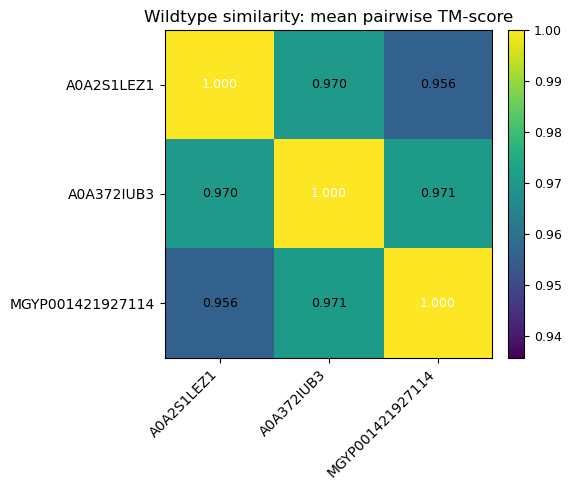

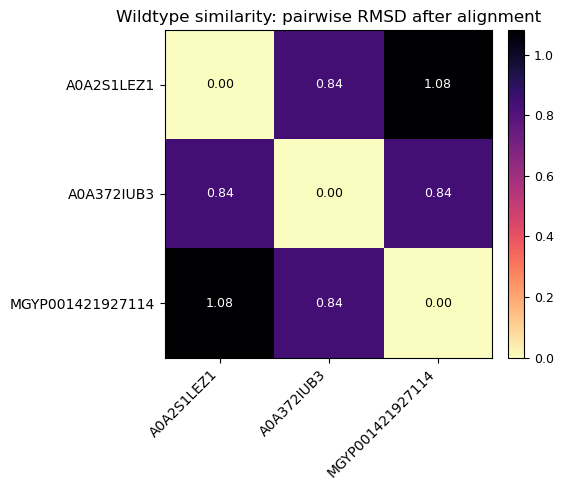

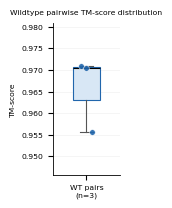

In [3]:
structure_family_df = discover_structure_families(FIGURE4_STRUCTURE_DIR)
wildtype_structure_df = structure_family_df.loc[structure_family_df['is_wildtype']].copy()

display(wildtype_structure_df)

wildtype_similarity_df, resolved_tmalign_executable = compute_wildtype_similarity_table(
    structure_family_df=structure_family_df,
    preferred_executable=TMALIGN_EXECUTABLE,
    allow_ca_fallback=TMALIGN_ALLOW_CA_FALLBACK,
)

wildtype_labels = list(wildtype_structure_df['family_id'])
wildtype_similarity_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    diagonal_value=1.0,
    labels=wildtype_labels,
)
wildtype_rmsd_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='rmsd_angstrom',
    diagonal_value=0.0,
    labels=wildtype_labels,
)

if resolved_tmalign_executable:
    print(f'Wildtype similarity method: official executable at {resolved_tmalign_executable}')
elif TMALIGN_ALLOW_CA_FALLBACK:
    print(
        'Wildtype similarity method: CA-based fallback. '
        'Set TMALIGN_EXECUTABLE to a TM-align/USalign binary for interpretable WT-vs-WT alignments.'
    )
else:
    print('Wildtype similarity method: not computed because no TM-align executable was found.')

display(
    wildtype_similarity_df[
        [
            'wildtype_a', 'wildtype_b', 'mean_tm_score',
            'tm_score_to_wildtype_a', 'tm_score_to_wildtype_b',
            'rmsd_angstrom', 'aligned_length',
            'alignment_method', 'alignment_note',
        ]
    ]
)
display(wildtype_similarity_matrix_df)
display(wildtype_rmsd_matrix_df)

tm_vmin = None
if not wildtype_similarity_matrix_df.empty:
    tm_vmin = max(
        0.0,
        float(np.nanmin(wildtype_similarity_matrix_df.to_numpy(dtype=float))) - 0.02,
    )

rmsd_vmax = None
if not wildtype_rmsd_matrix_df.empty:
    rmsd_values = wildtype_rmsd_matrix_df.to_numpy(dtype=float)
    if not np.isnan(rmsd_values).all():
        rmsd_vmax = float(np.nanmax(rmsd_values))

plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_similarity_matrix_df,
    title='Wildtype similarity: mean pairwise TM-score',
    cmap='viridis',
    value_format='{:.3f}',
    vmin=tm_vmin,
    vmax=1.0,
)
plt.show()
plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_rmsd_matrix_df,
    title='Wildtype similarity: pairwise RMSD after alignment',
    cmap='magma_r',
    value_format='{:.2f}',
    vmin=0.0,
    vmax=rmsd_vmax,
)
plt.show()
plot_wildtype_tm_score_boxplot(
    wildtype_similarity_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    figure_width_mm=WT_TM_SCORE_BOXPLOT_WIDTH_MM,
    figure_height_mm=WT_TM_SCORE_BOXPLOT_HEIGHT_MM,
    title='Wildtype pairwise TM-score distribution',
    ylabel='TM-score',
    title_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    label_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    tick_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    strip_marker_size=WT_TM_PLOT_STRIP_MARKER_SIZE,
)
plt.savefig(f"../Results/Figure4/TMAlign_boxplot.pdf")
plt.show()

## Limited RMSF Analysis

This section keeps only selected wildtype/variant pair comparisons. The family-level aggregate and cross-family RMSF analyses from the source notebook are left out.

In [4]:
md_rmsf_catalog_df = discover_md_rmsf_catalog(
    THERMALGAN_MD_ANALYSIS_DIR,
    allowed_family_ids=wildtype_labels,
)
md_rmsf_df = load_md_rmsf_long_df(md_rmsf_catalog_df)
variant_delta_rmsf_df = compute_variant_delta_rmsf_df(md_rmsf_df)
selected_variant_delta_rmsf_df = filter_variant_delta_rmsf_df(
    variant_delta_rmsf_df,
    selected_variants_by_family=SELECTED_RMSF_VARIANTS_BY_FAMILY,
)

selected_variant_request_df = pd.DataFrame(
    [
        {'family_id': family_id, 'sample_name': sample_name}
        for family_id, sample_names in SELECTED_RMSF_VARIANTS_BY_FAMILY.items()
        for sample_name in sample_names
    ]
).drop_duplicates()

available_selected_variant_df = selected_variant_request_df.merge(
    selected_variant_delta_rmsf_df[['family_id', 'sample_name']].drop_duplicates(),
    on=['family_id', 'sample_name'],
    how='left',
    indicator=True,
)
missing_selected_variant_df = available_selected_variant_df.loc[
    available_selected_variant_df['_merge'] == 'left_only',
    ['family_id', 'sample_name'],
].reset_index(drop=True)

pairwise_rmsf_summary_df = build_variant_pair_summary_df(selected_variant_delta_rmsf_df)

selected_catalog_df = md_rmsf_catalog_df.loc[
    md_rmsf_catalog_df['is_wildtype']
    | md_rmsf_catalog_df['sample_name'].isin(selected_variant_request_df['sample_name'])
].copy()

display(
    selected_catalog_df[
        [
            'family_id', 'sample_name', 'md_sample_name', 'is_wildtype',
            'window_start_frame', 'window_stop_frame',
        ]
    ]
)

if not missing_selected_variant_df.empty:
    print('Requested RMSF pairs that were not found:')
    display(missing_selected_variant_df)

display(
    pairwise_rmsf_summary_df[
        [
            'family_id', 'sample_name', 'n_residues',
            'mean_delta_rmsf_angstrom', 'mean_abs_delta_rmsf_angstrom',
            'max_abs_delta_rmsf_angstrom', 'peak_residue_number', 'peak_delta_rmsf_angstrom',
        ]
    ]
)

,family_id,sample_name,md_sample_name,is_wildtype,window_start_frame,window_stop_frame
0,A0A2S1LEZ1,A0A2S1LEZ1,A0A2S1LEZ1_WT,True,100000,500000
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,A0A2S1LEZ1_337_New_17444_0,False,100000,500000
4,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,A0A2S1LEZ1_362_New_17444_0,False,100000,500000
9,A0A372IUB3,A0A372IUB3,A0A372IUB3_WT,True,100000,500000
13,A0A372IUB3,A0A372IUB3_1792_model_x_0,A0A372IUB3_1792_model_x_0,False,100000,500000
18,A0A372IUB3,A0A372IUB3_1847_model_x_0,A0A372IUB3_1847_model_x_0,False,100000,500000
35,MGYP001421927114,MGYP001421927114,MGYP001421927114_WT,True,100000,500000
36,MGYP001421927114,MGYP001421927114_1306_model_x_0,MGYP001421927114_1306_model_x_0,False,100000,500000
37,MGYP001421927114,MGYP001421927114_1344_model_x_0,MGYP001421927114_1344_model_x_0,False,100000,500000


,family_id,sample_name,n_residues,mean_delta_rmsf_angstrom,mean_abs_delta_rmsf_angstrom,max_abs_delta_rmsf_angstrom,peak_residue_number,peak_delta_rmsf_angstrom
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,311,0.169775,1.072457,6.787865,221,-6.787865
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,311,-0.001417,1.049097,6.413406,299,6.413406
2,A0A372IUB3,A0A372IUB3_1792_model_x_0,308,-1.343158,1.378277,7.817152,59,-7.817152
3,A0A372IUB3,A0A372IUB3_1847_model_x_0,308,-0.272109,0.719733,6.238048,61,-6.238048
4,MGYP001421927114,MGYP001421927114_1344_model_x_0,318,0.365426,1.445382,13.003321,49,13.003321
5,MGYP001421927114,MGYP001421927114_1306_model_x_0,318,-0.359886,0.733935,4.755583,306,-4.755583


A0A372IUB3 | A0A372IUB3_1847_model_x_0


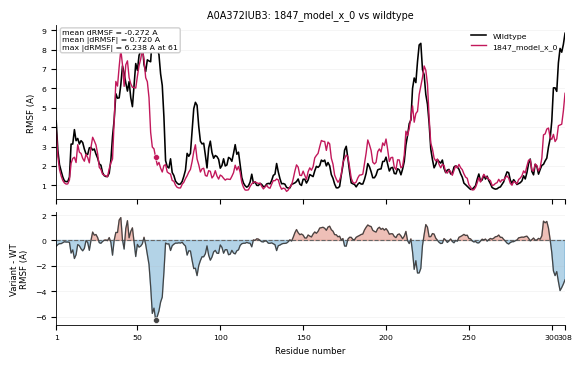

A0A372IUB3 | A0A372IUB3_1792_model_x_0


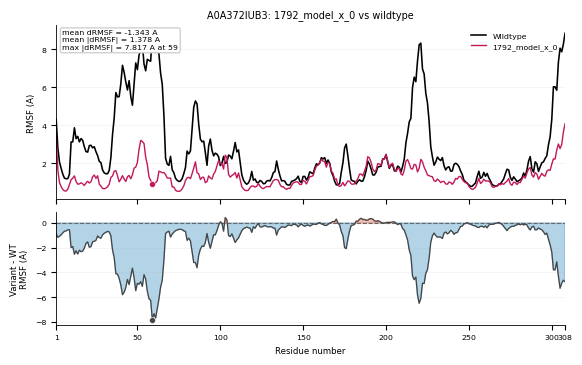

A0A2S1LEZ1 | A0A2S1LEZ1_362_New_17444_0


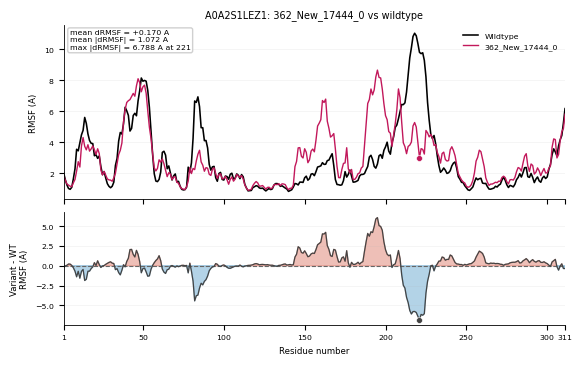

A0A2S1LEZ1 | A0A2S1LEZ1_337_New_17444_0


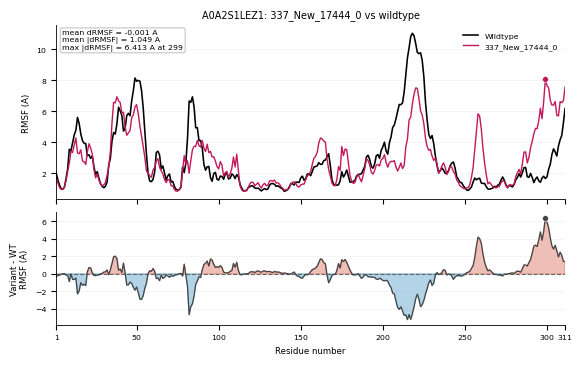

MGYP001421927114 | MGYP001421927114_1306_model_x_0


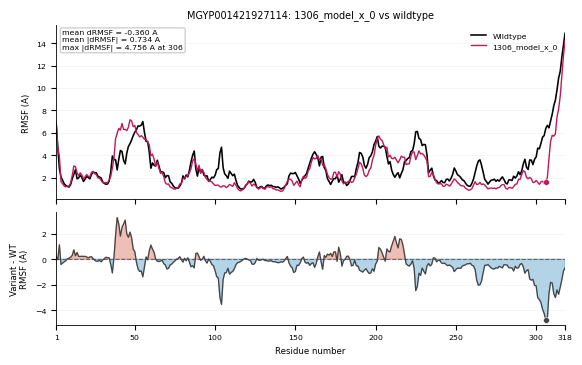

MGYP001421927114 | MGYP001421927114_1344_model_x_0


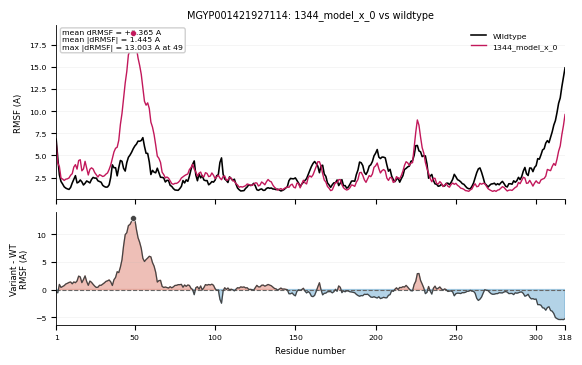

In [5]:
selected_pair_order_df = selected_variant_request_df.merge(
    pairwise_rmsf_summary_df[['family_id', 'sample_name']],
    on=['family_id', 'sample_name'],
    how='inner',
)

for row in selected_pair_order_df.itertuples(index=False):
    print(f"{row.family_id} | {row.sample_name}")
    plot_variant_pair_rmsf(
        family_id=row.family_id,
        sample_name=row.sample_name,
        md_rmsf_df=md_rmsf_df,
        variant_delta_rmsf_df=selected_variant_delta_rmsf_df,
    )
    plt.show()

## Family RMSF Overview Heatmaps

This section transfers the family RMSF overview plots from the original structure-analysis notebook. When `RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS` is set, variants below that median melting-temperature threshold are excluded from the overview heatmaps.

In [6]:
tm_summary_df = load_tsa_tm_delta_summary(
    result_summary_path=TSA_RESULT_SUMMARY_PATH,
    sample_catalog_df=md_rmsf_catalog_df,
)

all_rmsf_overview_variant_names = (
    md_rmsf_catalog_df.loc[~md_rmsf_catalog_df['is_wildtype'], 'sample_name']
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

tm_variant_lookup_df = (
    tm_summary_df.loc[
        tm_summary_df['sample_name'].notna() & (~tm_summary_df['is_wildtype']),
        ['family_id', 'sample_name', 'median_tm_celsius', 'delta_tm_to_wildtype_celsius'],
    ]
    .drop_duplicates(subset=['family_id', 'sample_name'])
    .reset_index(drop=True)
)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is None:
    overview_tm_summary_df = tm_summary_df.copy()
    overview_allowed_variant_names = all_rmsf_overview_variant_names
    excluded_rmsf_overview_variant_df = pd.DataFrame(
        columns=[
            'family_id', 'sample_name', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius', 'exclusion_reason',
        ]
    )
else:
    overview_tm_summary_df = filter_tm_summary_by_minimum_melting_temperature(
        tm_summary_df=tm_summary_df,
        minimum_median_tm_celsius=RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS,
        exclude_missing_tm=RMSF_OVERVIEW_EXCLUDE_MISSING_TM,
    )
    median_tm_lookup = {
        row.sample_name: float(row.median_tm_celsius)
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name) and pd.notna(row.median_tm_celsius)
    }
    low_tm_variant_name_set = {
        row.sample_name
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name)
        and pd.notna(row.median_tm_celsius)
        and float(row.median_tm_celsius) < float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
    }
    measured_variant_name_set = set(tm_variant_lookup_df['sample_name'].dropna().astype(str))

    if RMSF_OVERVIEW_EXCLUDE_MISSING_TM:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name in measured_variant_name_set
            and sample_name in median_tm_lookup
            and float(median_tm_lookup[sample_name]) >= float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
        ]
    else:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name not in low_tm_variant_name_set
        ]

    excluded_variant_rows = []
    for sample_name in all_rmsf_overview_variant_names:
        if sample_name in overview_allowed_variant_names:
            continue
        tm_match_df = tm_variant_lookup_df.loc[tm_variant_lookup_df['sample_name'] == sample_name]
        if tm_match_df.empty:
            family_id = sample_name.split('_', 1)[0]
            median_tm = np.nan
            delta_tm = np.nan
            reason = 'missing Tm'
        else:
            family_id = tm_match_df['family_id'].iloc[0]
            median_tm = tm_match_df['median_tm_celsius'].iloc[0]
            delta_tm = tm_match_df['delta_tm_to_wildtype_celsius'].iloc[0]
            if pd.isna(median_tm):
                reason = 'missing Tm'
            else:
                reason = f"median Tm < {float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS):0.1f} C"
        excluded_variant_rows.append(
            {
                'family_id': family_id,
                'sample_name': sample_name,
                'median_tm_celsius': median_tm,
                'delta_tm_to_wildtype_celsius': delta_tm,
                'exclusion_reason': reason,
            }
        )

    excluded_rmsf_overview_variant_df = pd.DataFrame(excluded_variant_rows)
    if not excluded_rmsf_overview_variant_df.empty:
        excluded_rmsf_overview_variant_df = excluded_rmsf_overview_variant_df.sort_values(
            ['family_id', 'median_tm_celsius', 'sample_name'],
            ascending=[True, True, True],
        ).reset_index(drop=True)

overview_md_rmsf_df, overview_variant_delta_rmsf_df = filter_rmsf_to_allowed_variants(
    md_rmsf_df=md_rmsf_df,
    variant_delta_rmsf_df=variant_delta_rmsf_df,
    allowed_variant_names=overview_allowed_variant_names,
)

overview_rmsf_tm_row_label_map = build_tm_delta_row_label_map(overview_tm_summary_df)
overview_rmsf_tm_sort_map = build_tm_median_sort_map(overview_tm_summary_df)

overview_variant_count_df = (
    overview_variant_delta_rmsf_df[['family_id', 'sample_name']]
    .drop_duplicates()
    .groupby('family_id', as_index=False)
    .agg(n_variants_plotted=('sample_name', 'size'))
)

display(overview_variant_count_df)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is not None and not excluded_rmsf_overview_variant_df.empty:
    display(excluded_rmsf_overview_variant_df)


,family_id,n_variants_plotted
0,A0A2S1LEZ1,8
1,A0A372IUB3,25
2,MGYP001421927114,6


A0A2S1LEZ1
/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A2S1LEZ1_RMSF.pdf


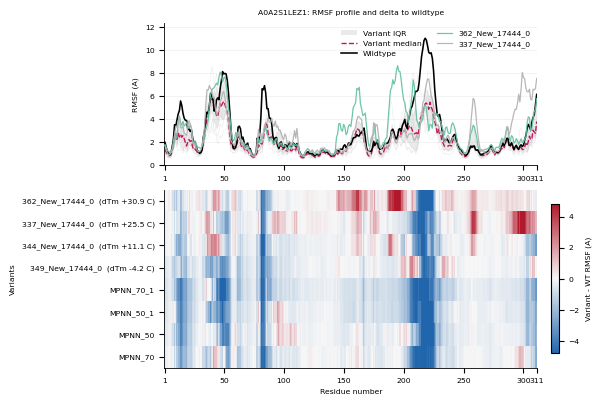

A0A372IUB3
/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A372IUB3_RMSF.pdf


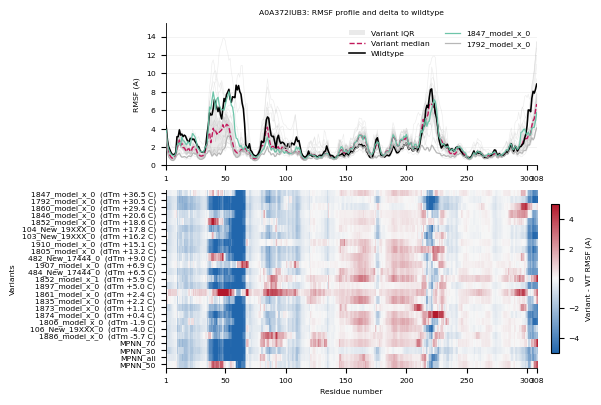

MGYP001421927114
/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_MGYP001421927114_RMSF.pdf


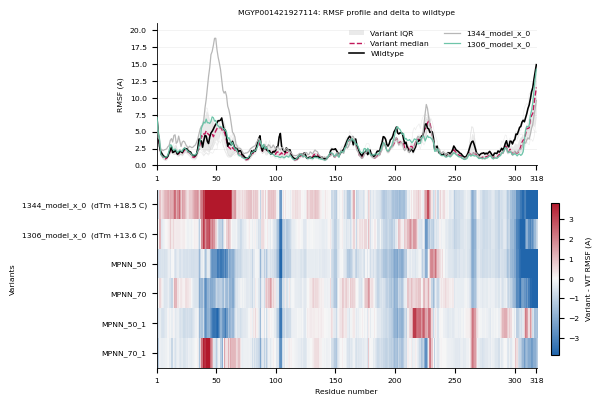

In [7]:
if SAVE_RMSF_OVERVIEW_PDFS:
    FIGURE4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for family_id in wildtype_labels:
    family_variant_count_series = overview_variant_count_df.loc[
        overview_variant_count_df['family_id'] == family_id,
        'n_variants_plotted',
    ]
    if family_variant_count_series.empty or int(family_variant_count_series.iloc[0]) == 0:
        print(f"{family_id}: no variants remain after the Tm filter")
        continue

    print(family_id)
    family_figure = plot_family_rmsf_overview(
        family_id=family_id,
        md_rmsf_df=overview_md_rmsf_df,
        variant_delta_rmsf_df=overview_variant_delta_rmsf_df,
        selected_variant_names=SELECTED_RMSF_VARIANTS_BY_FAMILY.get(family_id),
        sample_row_label_map=overview_rmsf_tm_row_label_map,
        sample_sort_value_map=overview_rmsf_tm_sort_map,
        figure_width_mm=RMSF_OVERVIEW_FIGURE_WIDTH_MM,
        figure_height_mm=RMSF_OVERVIEW_FIGURE_HEIGHT_MM,
        title_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        label_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        tick_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        legend_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
    )
    if SAVE_RMSF_OVERVIEW_PDFS:
        output_path = FIGURE4_OUTPUT_DIR / f"Structure_{family_id}_RMSF.pdf"
        family_figure.savefig(output_path, bbox_inches='tight')
        print(output_path)
    plt.show()


## MD Variant Family Comparison Workflow

This section replaces the older standalone script workflow. It compares each wildtype with all of its matched variants using the combined per-metric CSVs and keeps the replicate handling explicit.

When TSA measurements are available, the variant labels in this workflow are annotated with the experimental melting-temperature shift to wildtype (`dTm`), mirroring the `Family RMSF Overview Heatmaps` section.

Change `FIGURE4_MD_METRIC_WINDOW` in the config cell above to switch between numeric exports such as 100 ns or 300 ns, or to target a shared named suffix such as `longest_stop_mixed_stop`. Use `'latest'` if you want the notebook to automatically pick the longest shared window available.

The workflow keeps the replicate handling explicit:

1. Aggregate each metric at the replicate level first.
2. Summarize each system by the mean and standard deviation across replicates.
3. Compare each variant mean to its family wildtype mean.

The generated tables and plots are written to `sandra/MD_SIM/Round_3_additional_metric_csvs/` so the notebook and the saved outputs stay in sync.


In [8]:
if 'tm_summary_df' not in globals() or tm_summary_df is None or tm_summary_df.empty:
    md_rmsf_catalog_df = discover_md_rmsf_catalog(THERMALGAN_MD_ANALYSIS_DIR)
    tm_summary_df = load_tsa_tm_delta_summary(
        result_summary_path=TSA_RESULT_SUMMARY_PATH,
        sample_catalog_df=md_rmsf_catalog_df,
    )

md_variant_bundle = build_md_variant_analysis_bundle(
    metric_dir=FIGURE4_MD_METRIC_DIR,
    mutation_metadata_path=FIGURE4_MD_MUTATION_METADATA_PATH,
    metric_window=FIGURE4_MD_METRIC_WINDOW,
    tm_summary_df=tm_summary_df,
)

md_variant_tm_context_df = (
    md_variant_bundle.metadata_df.loc[
        ~md_variant_bundle.metadata_df['is_wildtype'],
        [
            'family', 'system', 'short_label', 'tm_display_label', 'mutation_count',
            'median_tm_celsius', 'wildtype_median_tm_celsius', 'delta_tm_to_wildtype_celsius',
        ],
    ]
    .rename(columns={'family': 'family_id', 'system': 'variant_system'})
    .sort_values(['family_id', 'mutation_count', 'variant_system'])
    .reset_index(drop=True)
)

MD_VARIANT_RUN_OUTPUT_ROOT = FIGURE4_MD_OUTPUT_ROOT / md_variant_bundle.metric_window_suffix
MD_VARIANT_PLOT_DIR = MD_VARIANT_RUN_OUTPUT_ROOT / 'plots'
MD_VARIANT_SUMMARY_DIR = MD_VARIANT_RUN_OUTPUT_ROOT / 'summary_tables'
GLOBAL_MD_VARIANT_SUMMARY_DIR = MD_VARIANT_SUMMARY_DIR / 'global'
FAMILY_MD_VARIANT_SUMMARY_DIR = MD_VARIANT_SUMMARY_DIR / 'family'

for directory in [
    MD_VARIANT_PLOT_DIR / 'rmsf',
    MD_VARIANT_PLOT_DIR / 'interaction_heatmaps',
    MD_VARIANT_PLOT_DIR / 'top_pair_deltas',
    MD_VARIANT_PLOT_DIR / 'neighborhood',
    MD_VARIANT_PLOT_DIR / 'secondary_structure',
    MD_VARIANT_PLOT_DIR / 'interaction_counts',
    MD_VARIANT_PLOT_DIR / 'interaction_boxplots',
    MD_VARIANT_PLOT_DIR / 'dashboard',
    GLOBAL_MD_VARIANT_SUMMARY_DIR,
    FAMILY_MD_VARIANT_SUMMARY_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

md_variant_tm_context_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'variant_experimental_tm_summary.csv',
    index=False,
)
md_variant_bundle.rmsf_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_rmsf_summary.csv',
    index=False,
)
md_variant_bundle.sasa_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_sasa_summary.csv',
    index=False,
)
md_variant_bundle.global_sasa_replicate_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_replicate_global_sasa_summary.csv',
    index=False,
)
md_variant_bundle.ss_residue_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_secondary_structure_summary.csv',
    index=False,
)
md_variant_bundle.ss_counts_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_secondary_structure_fraction_summary.csv',
    index=False,
)
for metric_name, summary_df in md_variant_bundle.interaction_count_summary_by_metric.items():
    summary_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_frame_{metric_name}_summary.csv',
        index=False,
    )
for metric_name, replicate_df in md_variant_bundle.interaction_count_replicate_by_metric.items():
    replicate_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_replicate_{metric_name}_summary.csv',
        index=False,
    )
for metric_name, block_df in md_variant_bundle.interaction_count_block_by_metric.items():
    block_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_timeblock_{metric_name}_summary.csv',
        index=False,
    )
md_variant_bundle.rmsf_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_rmsf_delta_vs_wt.csv',
    index=False,
)
md_variant_bundle.sasa_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_sasa_delta_vs_wt.csv',
    index=False,
)
md_variant_bundle.ss_residue_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_secondary_structure_delta_vs_wt.csv',
    index=False,
)
for metric_name, delta_df in md_variant_bundle.interaction_count_delta_by_metric.items():
    delta_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'all_variants_{metric_name}_count_delta_vs_wt.csv',
        index=False,
    )
for metric_name, delta_df in md_variant_bundle.pair_delta_by_metric.items():
    delta_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'all_variants_{metric_name}_delta_vs_wt.csv',
        index=False,
    )
md_variant_bundle.variant_signal_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'variant_signal_summary.csv',
    index=False,
)
md_variant_bundle.family_pattern_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'family_pattern_summary.csv',
    index=False,
)

for family_id in md_variant_bundle.family_ids:
    family_dir = FAMILY_MD_VARIANT_SUMMARY_DIR / family_id
    family_dir.mkdir(parents=True, exist_ok=True)

    md_variant_bundle.rmsf_delta_df.loc[
        md_variant_bundle.rmsf_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_rmsf_delta_vs_wt.csv', index=False)
    md_variant_bundle.sasa_delta_df.loc[
        md_variant_bundle.sasa_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_sasa_delta_vs_wt.csv', index=False)
    md_variant_bundle.global_sasa_replicate_df.loc[
        md_variant_bundle.global_sasa_replicate_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_global_sasa_summary.csv', index=False)
    md_variant_bundle.ss_residue_delta_df.loc[
        md_variant_bundle.ss_residue_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_secondary_structure_delta_vs_wt.csv', index=False)

    for metric_name, delta_df in md_variant_bundle.interaction_count_delta_by_metric.items():
        delta_df.loc[delta_df['family'].eq(family_id)].to_csv(
            family_dir / f'{family_id}_{metric_name}_count_delta_vs_wt.csv',
            index=False,
        )

    for metric_name, delta_df in md_variant_bundle.pair_delta_by_metric.items():
        delta_df.loc[delta_df['family'].eq(family_id)].to_csv(
            family_dir / f'{family_id}_{metric_name}_delta_vs_wt.csv',
            index=False,
        )

print('Families loaded:', md_variant_bundle.family_ids)
print(
    'Resolved MD metric window:',
    md_variant_bundle.metric_window_suffix,
    f"(start={md_variant_bundle.metric_window_start}, stop={md_variant_bundle.metric_window_stop})",
)
print('Window-specific output root:', MD_VARIANT_RUN_OUTPUT_ROOT)
display(md_variant_tm_context_df)
display(
    md_variant_bundle.metadata_df[
        [
            'system', 'family', 'is_wildtype', 'mutation_count', 'mutation_resids',
            'mutation_labels', 'tm_display_label', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius',
        ]
    ]
)
display(
    md_variant_bundle.variant_signal_df[
        [
            'global_rank', 'family', 'variant_label', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius', 'composite_stabilizing_score',
            'delta_rmsf_neighborhood_mean', 'contact_gain_total',
            'saltbridge_gain_total', 'hbond_gain_total',
            'delta_sasa_neighborhood_mean', 'delta_ordered_ss_neighborhood_mean',
        ]
    ].head(10)
)


Families loaded: ['A0A2S1LEZ1', 'A0A372IUB3', 'MGYP001421927114']
Resolved MD metric window: 0_longest_stop_mixed_stop (start=0, stop=500000)
Window-specific output root: /Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop


,family_id,variant_system,short_label,tm_display_label,mutation_count,median_tm_celsius,wildtype_median_tm_celsius,delta_tm_to_wildtype_celsius
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,362_New_17444_0,362_New_17444_0 (dTm +30.9 C),36,71.3416,40.4335,30.9081
1,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,344_New_17444_0 (dTm +11.1 C),37,51.5084,40.4335,11.0749
2,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,337_New_17444_0 (dTm +25.5 C),38,65.9163,40.4335,25.4828
3,A0A372IUB3,A0A372IUB3_1897_model_x_0,1897_model_x_0,1897_model_x_0 (dTm +5.0 C),10,60.9217,55.9120,5.0097
4,A0A372IUB3,A0A372IUB3_1852_model_x_1,1852_model_x_1,1852_model_x_1 (dTm +5.9 C),12,61.8301,55.9120,5.9181
5,A0A372IUB3,A0A372IUB3_1860_model_x_0,1860_model_x_0,1860_model_x_0 (dTm +29.4 C),13,85.3535,55.9120,29.4415
6,A0A372IUB3,A0A372IUB3_1792_model_x_0,1792_model_x_0,1792_model_x_0 (dTm +30.5 C),14,86.3846,55.9120,30.4726
7,A0A372IUB3,A0A372IUB3_1847_model_x_0,1847_model_x_0,1847_model_x_0 (dTm +36.5 C),14,92.3836,55.9120,36.4716
8,A0A372IUB3,A0A372IUB3_1910_model_x_0,1910_model_x_0,1910_model_x_0 (dTm +15.1 C),14,70.9832,55.9120,15.0712
9,A0A372IUB3,A0A372IUB3_1805_model_x_0,1805_model_x_0,1805_model_x_0 (dTm +13.2 C),18,69.0969,55.9120,13.1849


,system,family,is_wildtype,mutation_count,mutation_resids,mutation_labels,tm_display_label,median_tm_celsius,delta_tm_to_wildtype_celsius
0,A0A2S1LEZ1,A0A2S1LEZ1,True,0,NaN,NaN,WT,40.4335,0.0000
1,A0A2S1LEZ1_362_New_17444_0,A0A2S1LEZ1,False,36,46 48 50 56 67 69 70 78 97 122 124 130 150 158 159 170 187 195 208 210 211 213 215 216 217 218 220 236 247 260 262 292 297 301 302 303,M46L;C48A;T50P;T56V;K67A;A69K;N70G;S78A;G97N;M122V;T124V;L130Y;S150A;L158E;A159L;M170T;A187S;T195S;A208E;T210G;M211V;G213I;A215K;T216L;L217K;T218G;L220K;L236M;M247V;Q260Y;D262G;F292L;D297E;Q301K;M...,362_New_17444_0 (dTm +30.9 C),71.3416,30.9081
2,A0A2S1LEZ1_344_New_17444_0,A0A2S1LEZ1,False,37,46 48 50 56 63 67 69 70 78 97 122 124 130 150 158 159 170 187 195 197 208 210 211 213 215 216 217 218 220 236 247 260 292 297 301 302 303,M46L;C48A;T50P;T56V;N63G;K67A;A69K;N70G;S78A;G97N;M122V;T124V;L130Y;S150A;L158E;A159L;M170T;A187S;T195S;F197L;A208E;T210G;M211V;G213I;A215K;T216A;L217K;T218G;L220K;L236M;M247V;Q260L;F292L;D297E;Q3...,344_New_17444_0 (dTm +11.1 C),51.5084,11.0749
3,A0A2S1LEZ1_337_New_17444_0,A0A2S1LEZ1,False,38,46 48 50 56 63 67 69 70 78 97 122 124 150 154 156 158 159 187 189 195 197 208 210 211 213 215 216 217 218 220 236 247 260 262 297 301 302 303,M46L;C48A;T50A;T56V;N63G;K67A;A69K;N70G;S78A;G97N;M122V;T124V;S150A;T154Y;L156I;L158E;A159L;A187S;Y189V;T195S;F197L;A208E;T210G;M211V;G213E;A215K;T216L;L217K;T218G;L220K;L236M;M247V;Q260L;D262G;D2...,337_New_17444_0 (dTm +25.5 C),65.9163,25.4828
4,A0A372IUB3,A0A372IUB3,True,0,NaN,NaN,WT,55.9120,0.0000
5,A0A372IUB3_1897_model_x_0,A0A372IUB3,False,10,34 43 70 127 128 132 161 207 253 278,V34I;G43A;N70G;Q127Y;T128V;Q132V;K161G;Q207E;F253Y;Q278K,1897_model_x_0 (dTm +5.0 C),60.9217,5.0097
6,A0A372IUB3_1852_model_x_1,A0A372IUB3,False,12,43 70 127 128 161 168 207 246 253 278 289 303,G43A;N70G;Q127Y;T128V;K161G;T168Q;Q207E;K246R;F253Y;Q278K;E289K;C303M,1852_model_x_1 (dTm +5.9 C),61.8301,5.9181
7,A0A372IUB3_1860_model_x_0,A0A372IUB3,False,13,34 43 57 70 127 128 131 168 207 246 253 278 303,V34I;G43A;A57V;N70G;Q127Y;T128V;R131K;T168Q;Q207E;K246R;F253Y;Q278K;C303M,1860_model_x_0 (dTm +29.4 C),85.3535,29.4415
8,A0A372IUB3_1792_model_x_0,A0A372IUB3,False,14,34 43 70 127 128 132 207 219 246 253 263 265 278 303,V34I;G43A;N70G;Q127Y;T128V;Q132V;Q207E;Y219L;K246R;F253Y;Y263I;I265L;Q278K;C303M,1792_model_x_0 (dTm +30.5 C),86.3846,30.4726
9,A0A372IUB3_1847_model_x_0,A0A372IUB3,False,14,34 43 70 127 132 138 154 161 168 170 219 246 278 303,V34I;G43A;N70G;Q127Y;Q132V;N138E;T154A;K161G;T168Q;F170L;Y219L;K246R;Q278K;C303M,1847_model_x_0 (dTm +36.5 C),92.3836,36.4716


,global_rank,family,variant_label,median_tm_celsius,delta_tm_to_wildtype_celsius,composite_stabilizing_score,delta_rmsf_neighborhood_mean,contact_gain_total,saltbridge_gain_total,hbond_gain_total,delta_sasa_neighborhood_mean,delta_ordered_ss_neighborhood_mean
0,1.0,A0A372IUB3,Variant13 (dTm +16.2 C),72.1360,16.2240,0.736842,-0.225170,266.062617,7.248557,52.618347,-0.268407,0.001705
1,2.0,A0A372IUB3,Variant10 (dTm +17.8 C),73.7585,17.8465,0.728070,-0.286242,247.182120,6.557090,51.753197,-0.199738,0.012395
2,3.0,A0A372IUB3,Variant12 (dTm +9.0 C),64.8800,8.9680,0.701754,-0.169883,262.852857,9.131543,51.090457,-0.440176,-0.004989
3,3.0,A0A372IUB3,Variant11 (dTm +6.5 C),62.3620,6.4500,0.701754,-0.125057,250.228057,8.033803,50.212993,-0.106245,0.017690
4,4.0,A0A372IUB3,Variant14 (dTm +6.9 C),62.8599,6.9479,0.675439,0.004546,266.162907,6.373910,52.670340,-0.987639,-0.005293
5,5.0,A0A372IUB3,Variant7 (dTm +13.2 C),69.0969,13.1849,0.657895,-0.275765,163.982213,7.143280,33.802343,-0.834524,0.010868
6,6.0,A0A372IUB3,Variant9 (dTm +18.6 C),74.5336,18.6216,0.596491,-0.058596,241.060423,9.535437,52.110477,0.125579,-0.001130
7,7.0,A0A372IUB3,Variant1 (dTm +30.5 C),86.3846,30.4726,0.570175,-0.535807,146.506923,4.962773,29.058610,-0.678345,0.017183
8,8.0,A0A372IUB3,Variant8 (dTm +20.6 C),76.5092,20.5972,0.552632,-0.269847,161.052490,6.039580,34.304283,-0.672196,0.008496
9,9.0,A0A372IUB3,Variant6 (dTm +15.1 C),70.9832,15.0712,0.517544,-0.166600,153.437960,6.978040,34.906717,-0.131384,0.006076


### How residues and pairs of interest are ranked

The notebook uses **replicate-aware effect-size summaries**, not a formal residue-wise significance test.

- For each residue, the WT and the variant are each summarized by a **mean RMSF across replicates** and a **replicate standard deviation**.
- The main residue ranking statistic is the **mean absolute RMSF delta to WT** across variants in the same family.
- A second scale-aware statistic is also reported:
  `standardized delta = (variant mean - WT mean) / sqrt(variant SD^2 + WT SD^2)`.
- This standardized delta tells you whether the WT-vs-variant shift is large relative to replicate-to-replicate spread, but it is still an **effect-size score**, not a p-value.
- For contact, salt-bridge, and H-bond heatmaps, the “most varied to WT” pairs are ranked by the **largest absolute occupancy shift to WT** across variants in that family.

So the current workflow is statistical in the sense that it uses replicate means and replicate variation, but it does **not** claim formal significance testing or multiple-testing correction.


In [9]:
md_family_residue_interest_tables = {
    family_id: compute_md_family_residue_interest_df(
        rmsf_delta_df=md_variant_bundle.rmsf_delta_df,
        family_id=family_id,
    )
    for family_id in md_variant_bundle.family_ids
}
md_family_pair_interest_tables = {
    family_id: {
        metric_name: compute_md_family_pair_interest_df(
            pair_summary_df=md_variant_bundle.pair_summary_by_metric[metric_name],
            metadata_df=md_variant_bundle.metadata_df,
            family_id=family_id,
        )
        for metric_name in MD_VARIANT_PAIR_METRICS
    }
    for family_id in md_variant_bundle.family_ids
}

for family_id in md_variant_bundle.family_ids:
    print()
    print(f'{family_id}: top RMSF-ranked residues')
    display(
        md_family_residue_interest_tables[family_id][
            [
                'interest_rank', 'resid', 'resname',
                'mean_delta_rmsf', 'mean_abs_delta_rmsf',
                'mean_abs_standardized_delta_rmsf',
                'fraction_variants_lower_than_wt',
            ]
        ].head(12)
    )



A0A2S1LEZ1: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,50,PRO,3.077482,3.077482,0.785984,0.000000
1,2,44,ASP,2.443243,2.519347,0.810922,0.333333
2,3,43,LEU,2.424675,2.471206,0.837496,0.333333
3,4,45,ILE,2.089915,2.397057,0.712116,0.333333
4,5,46,LEU,2.012572,2.374976,0.681234,0.333333
5,6,47,GLN,1.968157,2.194373,0.604584,0.333333
6,7,52,THR,2.186558,2.186558,0.582267,0.000000
7,8,51,ASN,2.159734,2.159734,0.553769,0.000000
8,9,53,GLY,2.079218,2.126193,0.606668,0.333333
9,10,48,ALA,1.585419,2.060407,0.604920,0.333333



A0A372IUB3: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,57,VAL,-2.225521,2.225521,0.973430,1.000000
1,2,61,GLY,-1.948089,2.063607,0.618455,0.928571
2,3,56,ASP,-2.040870,2.040870,0.970717,1.000000
3,4,63,ASN,-1.847371,2.014643,0.684589,0.928571
4,5,60,LEU,-1.870418,1.982876,0.657501,0.928571
5,6,64,ASP,-1.762454,1.945473,0.771054,0.928571
6,7,57,THR,-1.929189,1.929189,0.859949,1.000000
7,8,62,THR,-1.801800,1.912621,0.630904,0.928571
8,9,59,ILE,-1.837399,1.876965,0.588724,0.928571
9,10,58,LYS,-1.874179,1.874179,0.857106,1.000000



MGYP001421927114: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,46,ASP,3.530710,3.530710,0.834473,0.0
1,2,44,ALA,3.192852,3.192852,0.962016,0.0
2,3,43,LYS,3.185221,3.185221,1.072739,0.0
3,4,47,ILE,3.181970,3.181970,0.700835,0.0
4,5,45,LEU,3.102211,3.102211,0.898341,0.0
5,6,48,ALA,3.078639,3.078639,0.626978,0.0
6,7,312,CYS,-2.984476,2.984476,1.200629,1.0
7,8,49,GLU,2.981730,2.981730,0.561152,0.0
8,9,42,GLY,2.925654,2.925654,1.160175,0.0
9,10,203,THR,2.878574,2.878574,1.987189,0.0


### Per-family RMSF overlays

How to read these panels:

- **Black line**: WT mean RMSF across the WT replicates.
- **Gray band**: WT replicate standard deviation around that mean.
- **Colored line**: one variant mean RMSF across its replicates.
- **Faint colored band**: replicate standard deviation for that variant.
- **Downward triangles below the x-axis**: mutation positions from `mutation_metadata.csv`.

Interpretation: when the colored variant line sits below the WT line in a residue region, that region is less flexible in the variant than in the WT.


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/rmsf/A0A2S1LEZ1_rmsf_vs_wt.png


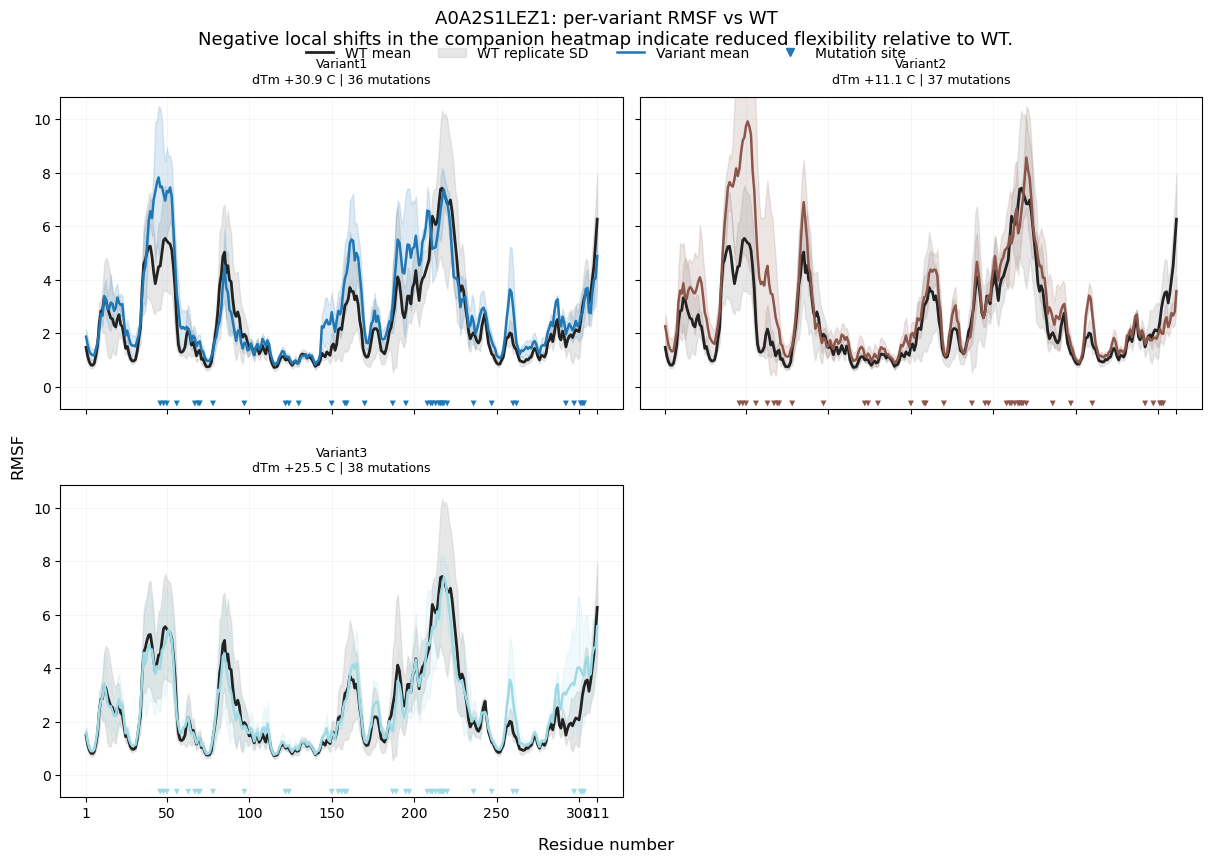

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/rmsf/A0A372IUB3_rmsf_vs_wt.png


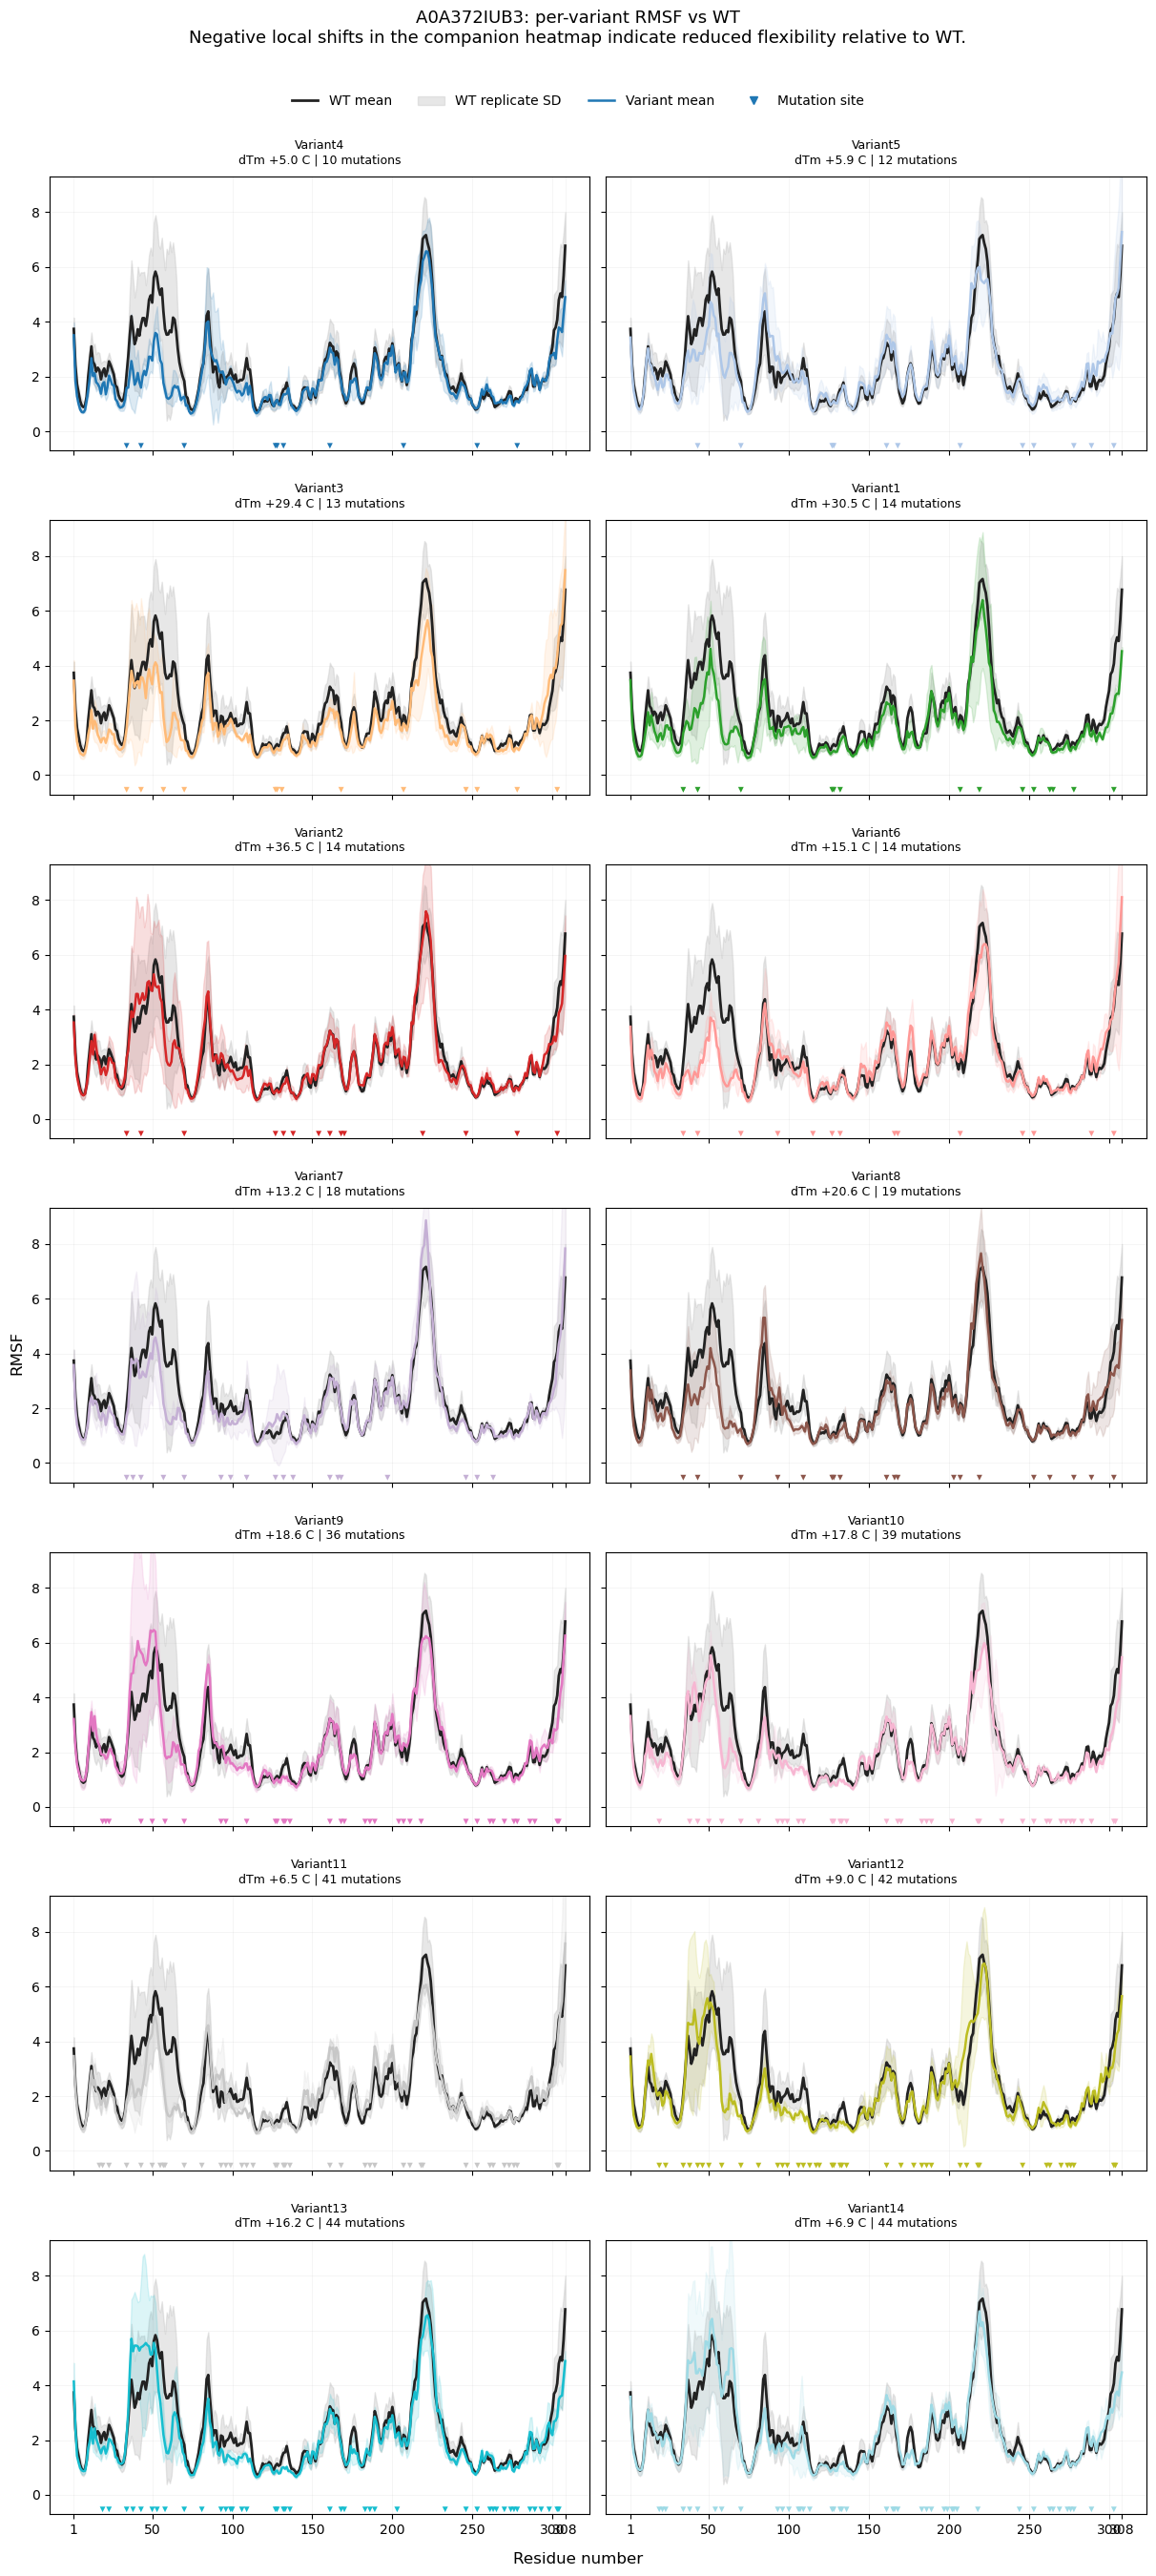

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/rmsf/MGYP001421927114_rmsf_vs_wt.png


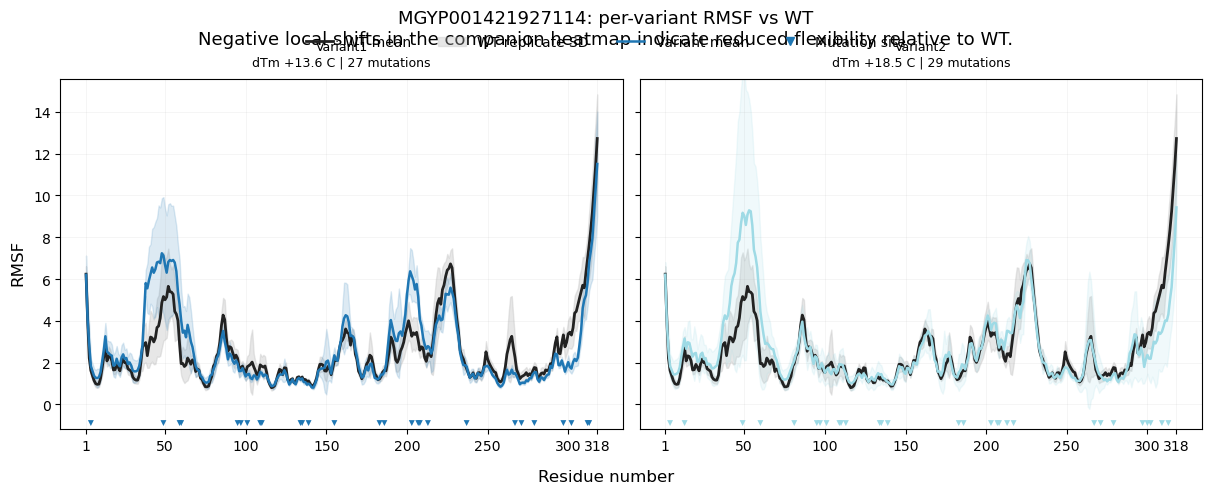

In [10]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_rmsf_panels(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        rmsf_summary_df=md_variant_bundle.rmsf_summary_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'rmsf' / f'{family_id}_rmsf_vs_wt.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Delta RMSF heatmaps

How to read these heatmaps:

- **Each row** is one variant in a WT family.
- **Each column** is one residue number.
- **Color** is `variant mean RMSF - WT mean RMSF`.
- **Blue** means the variant is less flexible than WT at that residue.
- **Red** means the variant is more flexible than WT at that residue.
- **Black squares** mark mutated residues.

These are direct mean differences after replicate aggregation. They are not p-values.


../Results/Figure4/A0A2S1LEZ1_delta_rmsf_heatmap.pdf


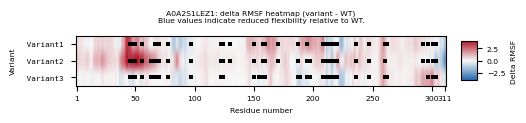

../Results/Figure4/A0A372IUB3_delta_rmsf_heatmap.pdf


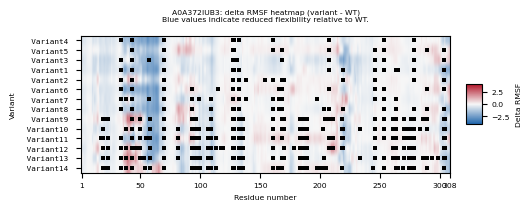

../Results/Figure4/MGYP001421927114_delta_rmsf_heatmap.pdf


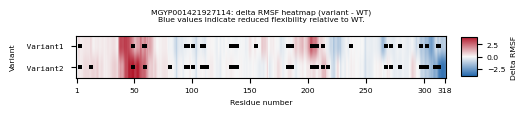

In [11]:
DELTA_RMSF_FIGURE_WIDTH_MM = 135
DELTA_RMSF_FIGURE_ROW_HEIGHT_MM = 3
DELTA_RMSF_FIGURE_BASE_HEIGHT_MM = 10
DELTA_RMSF_FONT_SIZE_PT = 5.5
DELTA_RMSF_COLORBAR_HEIGHT_MM = 10
DELTA_RMSF_COLORBAR_WIDTH_MM = 4
DELTA_RMSF_COLORBAR_PAD_MM = 4
DELTA_RMSF_YTICK_FONTFAMILY = 'DejaVu Sans Mono'
DELTA_RMSF_YTICK_EXTRA_COLUMNS = 1
DELTA_RMSF_SHOW_YTICK_TM_METADATA = False

for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_delta_heatmap(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        delta_df=md_variant_bundle.rmsf_delta_df,
        value_column='delta_rmsf',
        title=(
            f'{family_id}: delta RMSF heatmap (variant - WT)\n'
            'Blue values indicate reduced flexibility relative to WT.'
        ),
        colorbar_label='Delta RMSF',
        figure_width_mm=DELTA_RMSF_FIGURE_WIDTH_MM,
        figure_row_height_mm=DELTA_RMSF_FIGURE_ROW_HEIGHT_MM,
        figure_base_height_mm=DELTA_RMSF_FIGURE_BASE_HEIGHT_MM,
        colorbar_height_mm=DELTA_RMSF_COLORBAR_HEIGHT_MM,
        colorbar_width_mm=DELTA_RMSF_COLORBAR_WIDTH_MM,
        colorbar_pad_mm=DELTA_RMSF_COLORBAR_PAD_MM,
        y_tick_fontfamily=DELTA_RMSF_YTICK_FONTFAMILY,
        y_tick_extra_columns=DELTA_RMSF_YTICK_EXTRA_COLUMNS,
        show_y_tick_tm_metadata=DELTA_RMSF_SHOW_YTICK_TM_METADATA,
        title_size_pt=DELTA_RMSF_FONT_SIZE_PT,
        label_size_pt=DELTA_RMSF_FONT_SIZE_PT,
        tick_size_pt=DELTA_RMSF_FONT_SIZE_PT,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = Path(f"../Results/Figure4/{family_id}_delta_rmsf_heatmap.pdf") #MD_VARIANT_PLOT_DIR / 'rmsf' / f'{family_id}_delta_rmsf_heatmap.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Interaction-count trajectories relative to WT

These plots show the total interaction counts over time for each family, centered on the WT trajectory.

How to read these panels:

- **One row per metric**: residue contacts, H-bonds, and salt bridges.
- **Colored lines**: variant mean count across replicates minus the WT mean count at the same timepoint.
- **Black horizontal line at zero**: the WT mean trajectory after centering.
- **Gray band around zero**: WT replicate standard deviation at each timepoint.
- **Positive values** mean the variant has more of that interaction type than WT at that timepoint; **negative values** mean fewer.

The x-axis is trajectory time in ns, inferred from the exported frame spacing used in the combined MD metric CSVs.


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_counts/A0A2S1LEZ1_interaction_count_trajectories.png


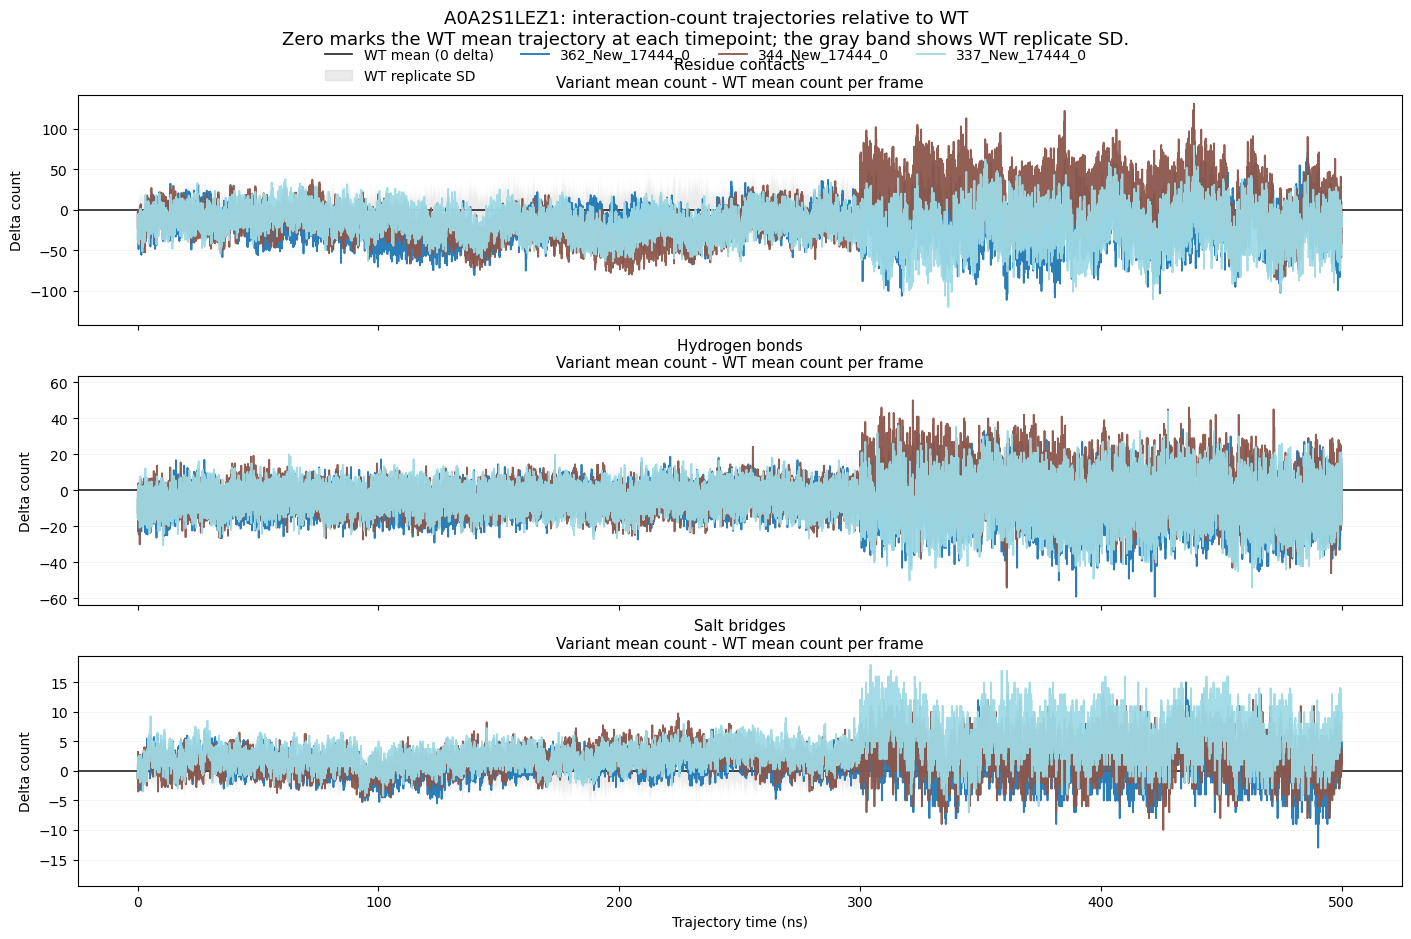

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_counts/A0A372IUB3_interaction_count_trajectories.png


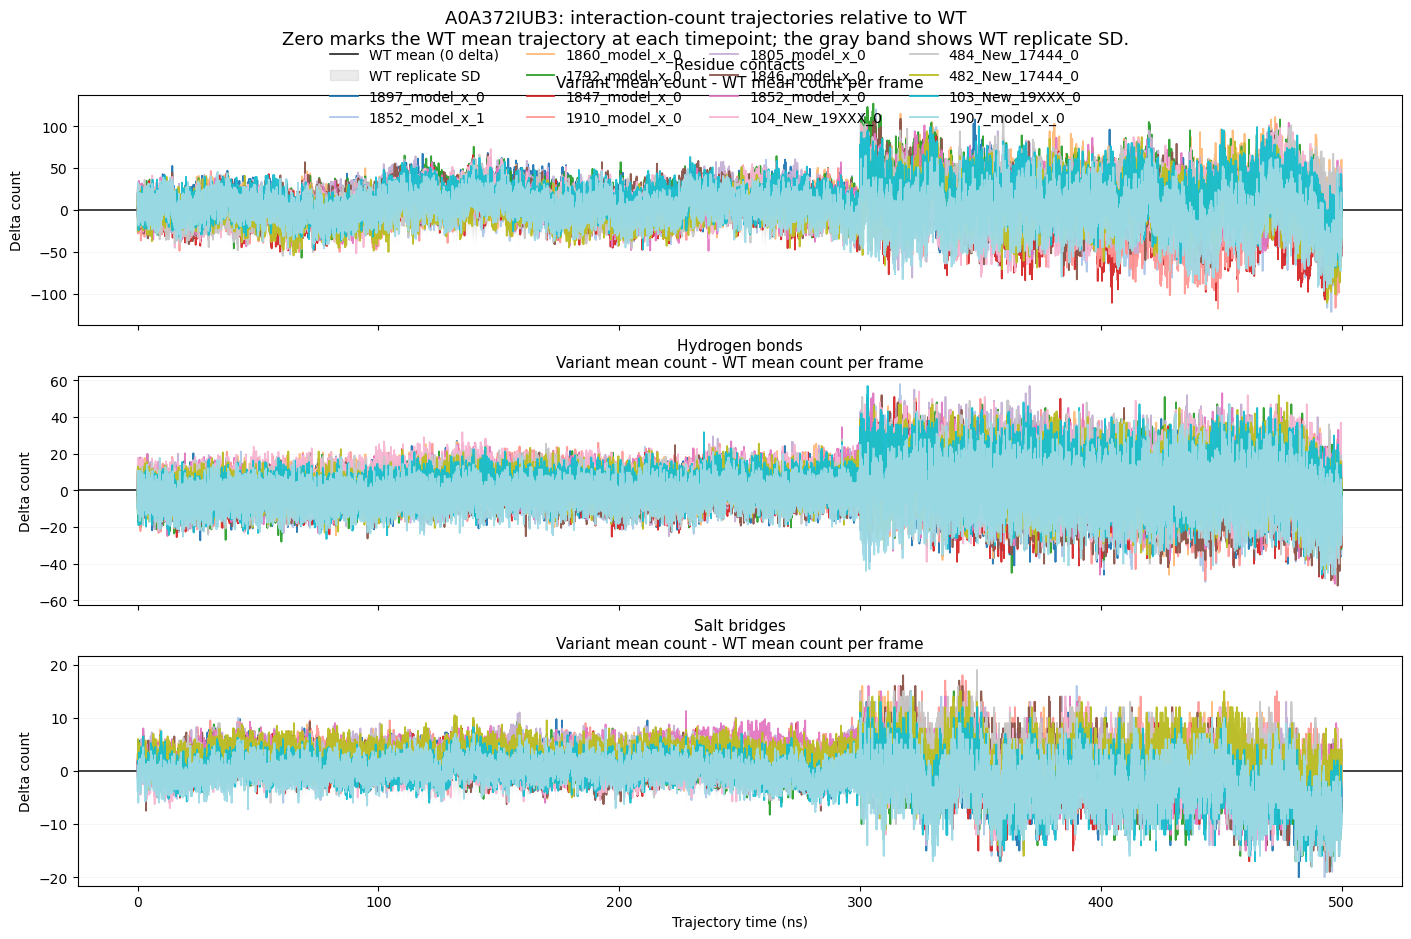

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_counts/MGYP001421927114_interaction_count_trajectories.png


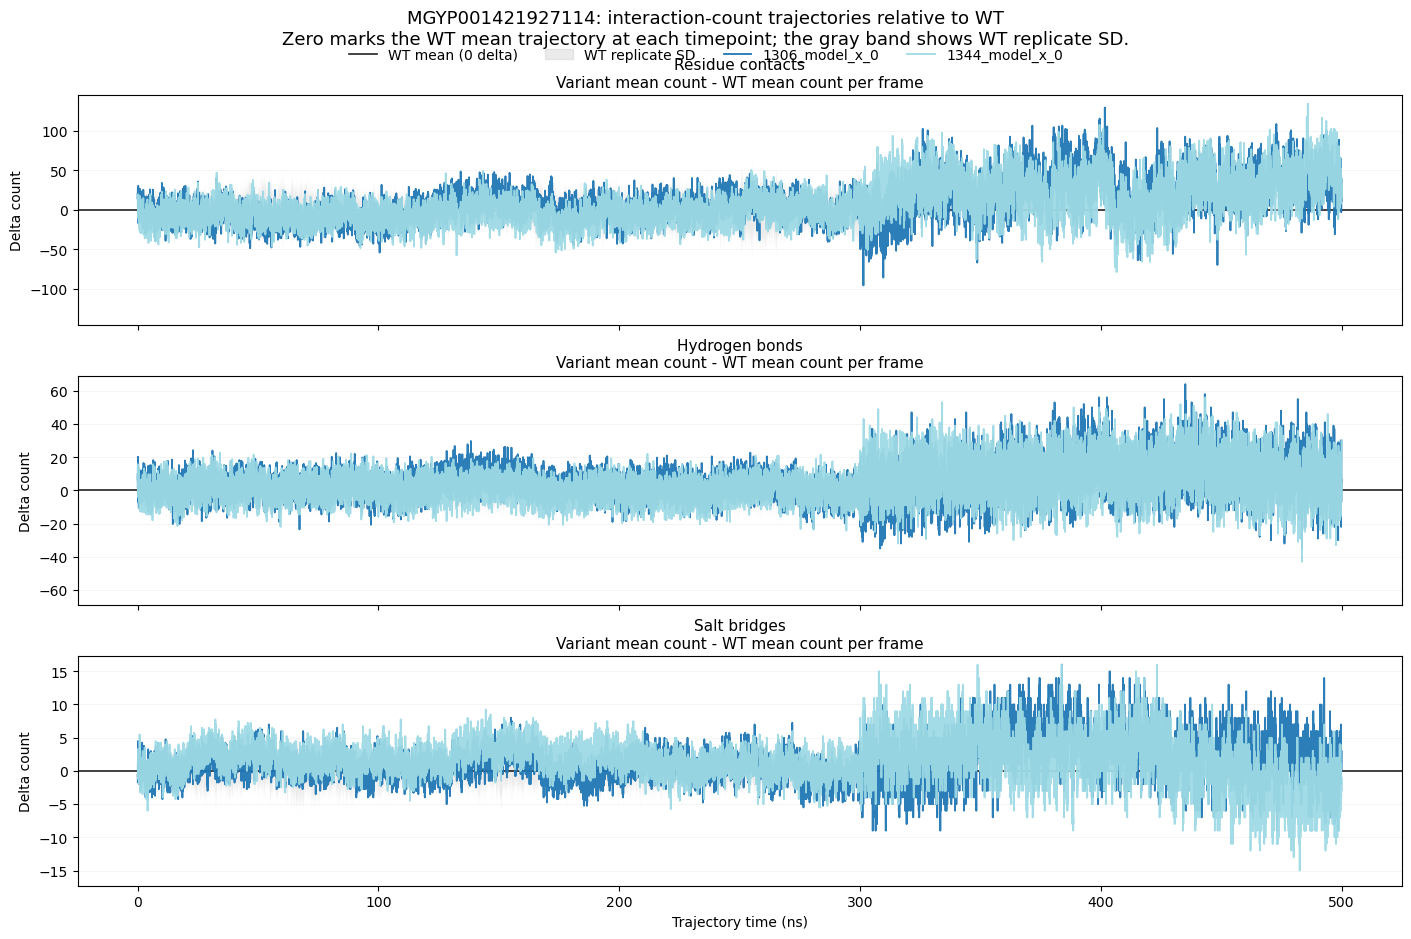

In [12]:
for family_id in md_variant_bundle.family_ids:
    figure = helper_fugure4.plot_md_family_interaction_count_trajectories(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_summary_by_metric=md_variant_bundle.interaction_count_summary_by_metric,
        interaction_count_delta_by_metric=md_variant_bundle.interaction_count_delta_by_metric,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_counts' / f'{family_id}_interaction_count_trajectories.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Absolute interaction-count and SASA boxplots

These plots show the interaction metrics in absolute units for WT and all variants in each family.

How to read these panels:

- **One box per system**: WT plus all variants in the family.
- **Contacts, H-bonds, and salt bridges** use the distribution of per-frame replicate-mean counts across the analysis window.
- **Time-block stars for counts**: contacts, H-bonds, and salt bridges use a distribution-shift test on contiguous 100-frame block means (about 2 ns per block), with permutation KS p-values and Benjamini-Hochberg correction within each family.
- **Global SASA** uses residue-summed mean SASA per replicate over the same window, because the current combined SASA export is window-averaged rather than framewise.
- **SASA stars** use a Welch test on replicate means, also with Benjamini-Hochberg correction within each family.
- **Radius of gyration** is not included here because it is not present in the current combined Figure 4 metric exports.


,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,A0A2S1LEZ1,337_New_17444_0,Global SASA,14817.488461,14529.039562,288.448898,welch_ttest,4,4,0.076649,0.076649,,higher
1,A0A2S1LEZ1,344_New_17444_0,Global SASA,14924.561150,14529.039562,395.521587,welch_ttest,4,4,0.053197,0.063836,,higher
2,A0A2S1LEZ1,362_New_17444_0,Global SASA,14828.552879,14529.039562,299.513317,welch_ttest,4,4,0.070499,0.076649,,higher
3,A0A2S1LEZ1,337_New_17444_0,Hydrogen bonds,156.153371,160.744929,-4.591557,block_permutation_ks,700,700,0.000500,0.000666,***,lower
4,A0A2S1LEZ1,344_New_17444_0,Hydrogen bonds,157.353186,160.744929,-3.391743,block_permutation_ks,700,700,0.000500,0.000666,***,lower
5,A0A2S1LEZ1,362_New_17444_0,Hydrogen bonds,154.958200,160.744929,-5.786729,block_permutation_ks,700,700,0.000500,0.000666,***,lower
6,A0A2S1LEZ1,337_New_17444_0,Residue contacts,815.459943,831.614686,-16.154743,block_permutation_ks,700,700,0.000500,0.000666,***,lower
7,A0A2S1LEZ1,344_New_17444_0,Residue contacts,817.633186,831.614686,-13.981500,block_permutation_ks,700,700,0.000500,0.000666,***,lower
8,A0A2S1LEZ1,362_New_17444_0,Residue contacts,812.593100,831.614686,-19.021586,block_permutation_ks,700,700,0.000500,0.000666,***,lower
9,A0A2S1LEZ1,337_New_17444_0,Salt bridges,17.186986,14.326886,2.860100,block_permutation_ks,700,700,0.000500,0.000666,***,higher


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_boxplots/A0A2S1LEZ1_absolute_metric_boxplots.png


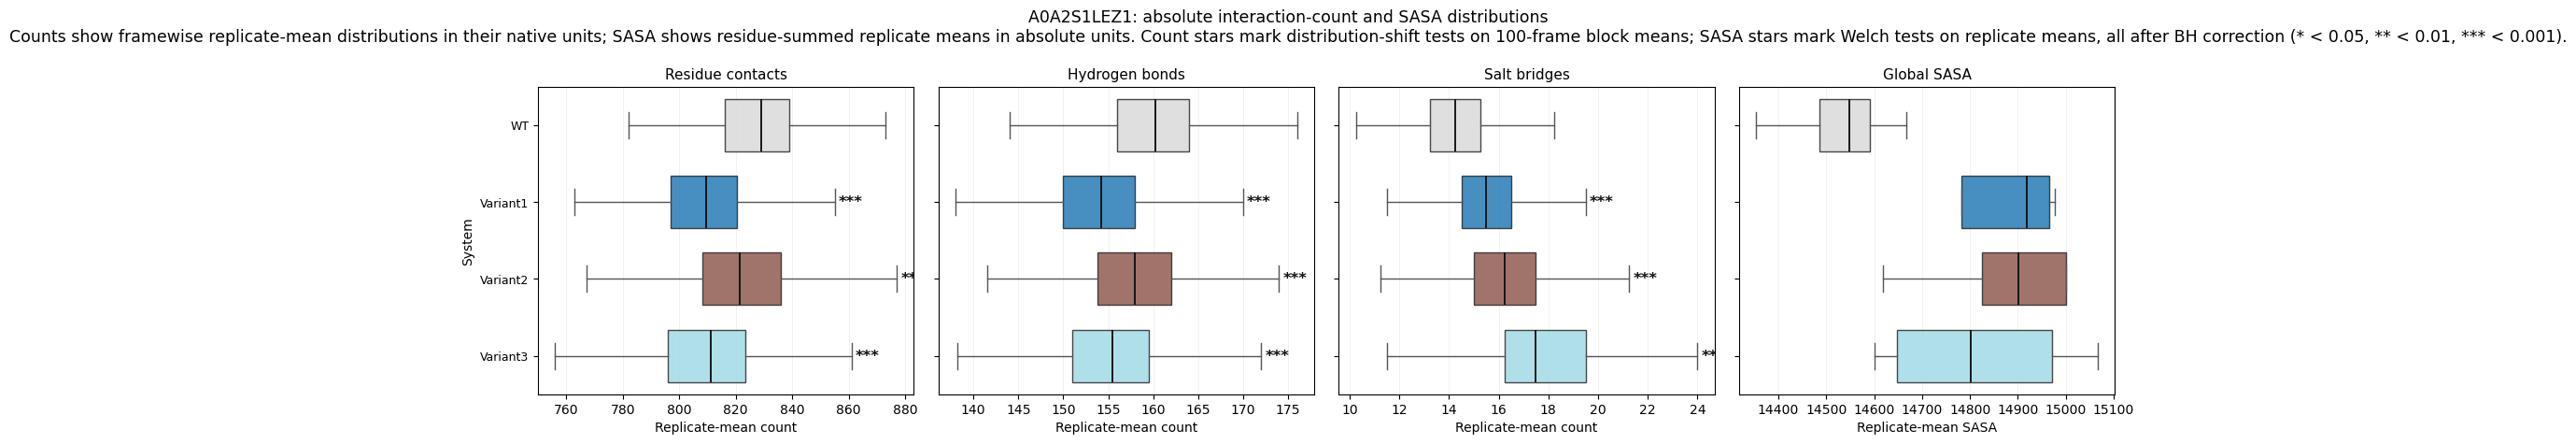

,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,A0A372IUB3,103_New_19XXX_0,Global SASA,14828.738816,14992.476967,-163.738151,welch_ttest,4,4,0.183698,0.239235,,lower
1,A0A372IUB3,104_New_19XXX_0,Global SASA,14886.897988,14992.476967,-105.578978,welch_ttest,4,4,0.354715,0.441424,,lower
2,A0A372IUB3,1792_model_x_0,Global SASA,14894.736912,14992.476967,-97.740055,welch_ttest,4,4,0.479988,0.548558,,lower
3,A0A372IUB3,1805_model_x_0,Global SASA,14701.904341,14992.476967,-290.572626,welch_ttest,4,4,0.066139,0.090336,,lower
4,A0A372IUB3,1846_model_x_0,Global SASA,14889.312822,14992.476967,-103.164145,welch_ttest,4,4,0.394830,0.480663,,lower
5,A0A372IUB3,1847_model_x_0,Global SASA,14988.658586,14992.476967,-3.818380,welch_ttest,4,4,0.974468,0.974468,,lower
6,A0A372IUB3,1852_model_x_0,Global SASA,15016.312968,14992.476967,23.836001,welch_ttest,4,4,0.832701,0.858731,,higher
7,A0A372IUB3,1852_model_x_1,Global SASA,14958.689358,14992.476967,-33.787609,welch_ttest,4,4,0.843397,0.858731,,lower
8,A0A372IUB3,1860_model_x_0,Global SASA,14902.534552,14992.476967,-89.942415,welch_ttest,4,4,0.542648,0.584390,,lower
9,A0A372IUB3,1897_model_x_0,Global SASA,14650.146829,14992.476967,-342.330138,welch_ttest,4,4,0.069788,0.093050,,lower


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_boxplots/A0A372IUB3_absolute_metric_boxplots.png


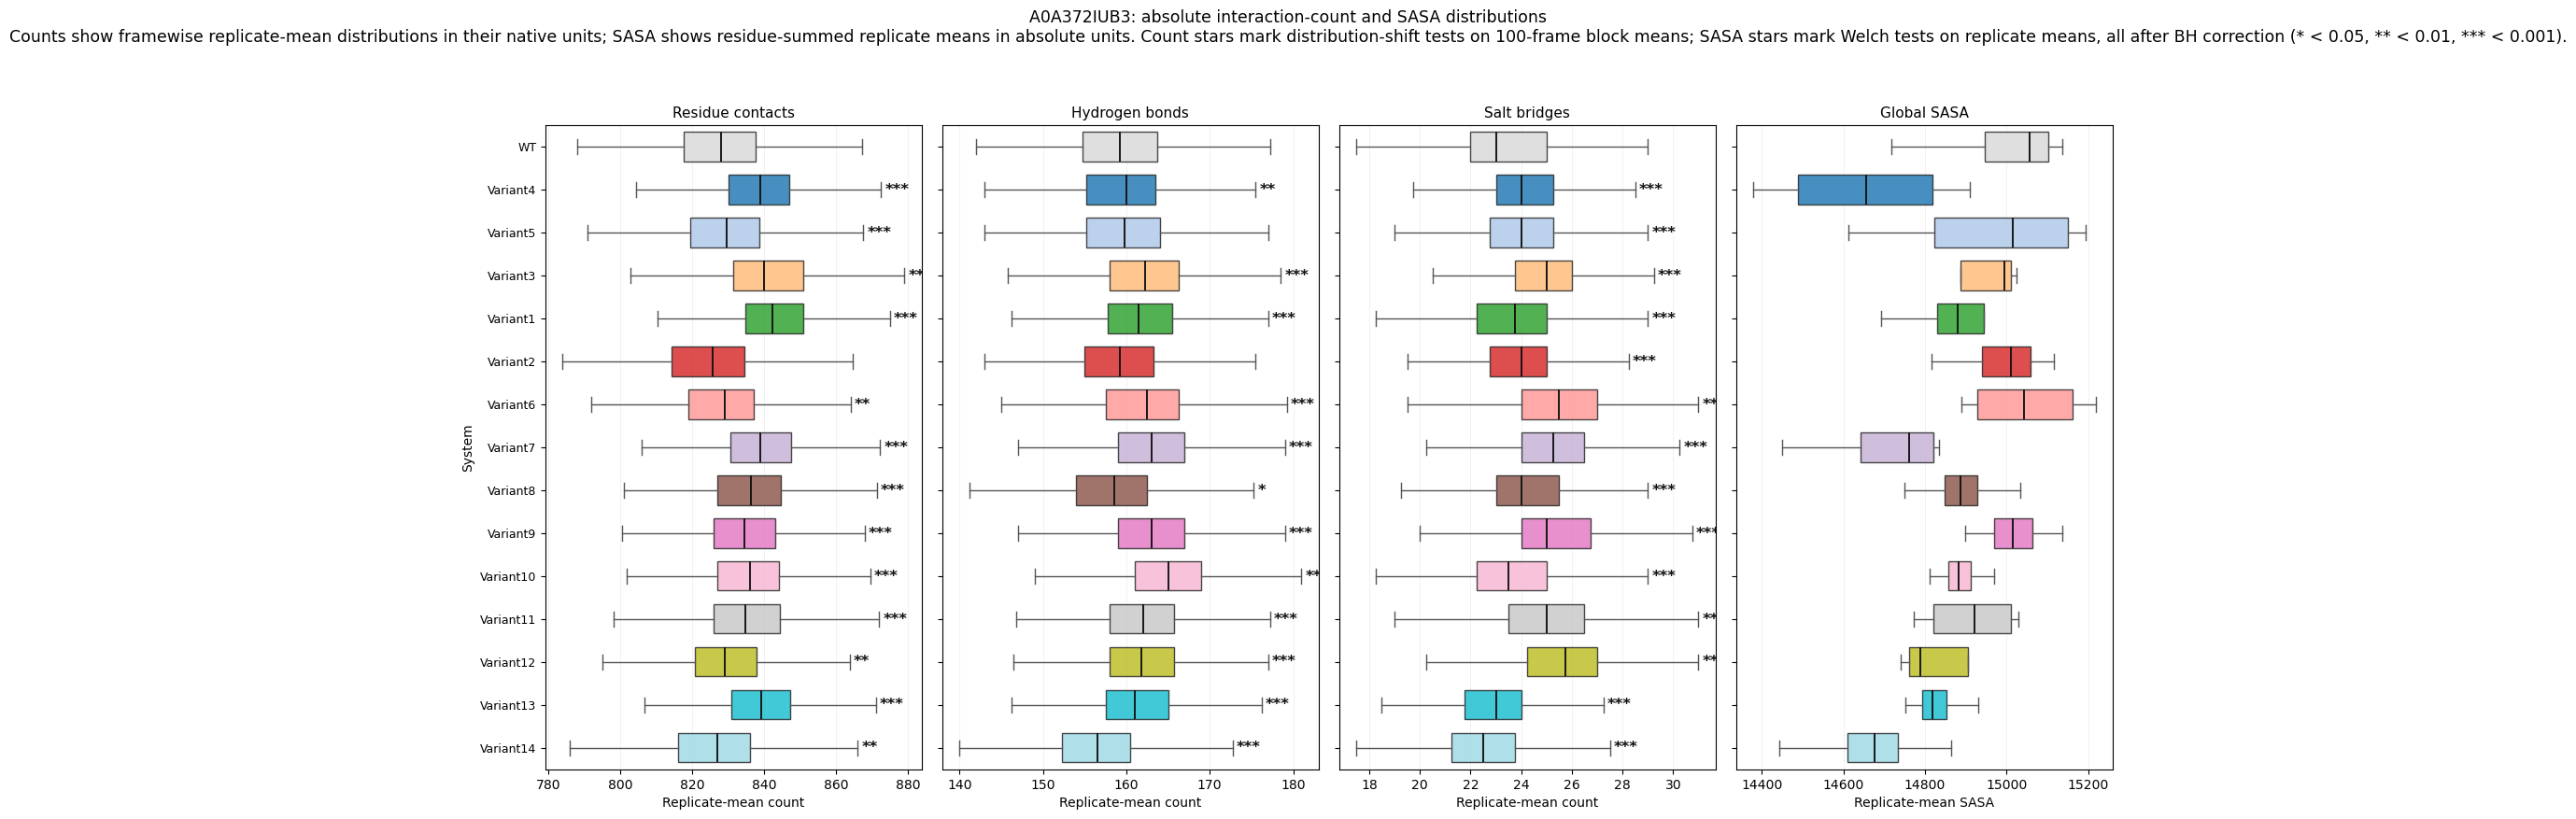

,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,MGYP001421927114,1306_model_x_0,Global SASA,15123.088581,15186.102512,-63.013931,welch_ttest,4,4,0.684455,0.782235,,lower
1,MGYP001421927114,1344_model_x_0,Global SASA,15180.330757,15186.102512,-5.771755,welch_ttest,4,4,0.959784,0.959784,,lower
2,MGYP001421927114,1306_model_x_0,Hydrogen bonds,157.501929,154.134871,3.367057,block_permutation_ks,700,700,0.000500,0.001000,***,higher
3,MGYP001421927114,1344_model_x_0,Hydrogen bonds,155.662886,154.134871,1.528014,block_permutation_ks,700,700,0.000500,0.001000,***,higher
4,MGYP001421927114,1306_model_x_0,Residue contacts,845.526243,842.695557,2.830686,block_permutation_ks,700,700,0.001000,0.001333,**,higher
5,MGYP001421927114,1344_model_x_0,Residue contacts,841.860743,842.695557,-0.834814,block_permutation_ks,700,700,0.001000,0.001333,**,lower
6,MGYP001421927114,1306_model_x_0,Salt bridges,20.296886,19.278229,1.018657,block_permutation_ks,700,700,0.000500,0.001000,***,higher
7,MGYP001421927114,1344_model_x_0,Salt bridges,20.946914,19.278229,1.668686,block_permutation_ks,700,700,0.000500,0.001000,***,higher


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_boxplots/MGYP001421927114_absolute_metric_boxplots.png


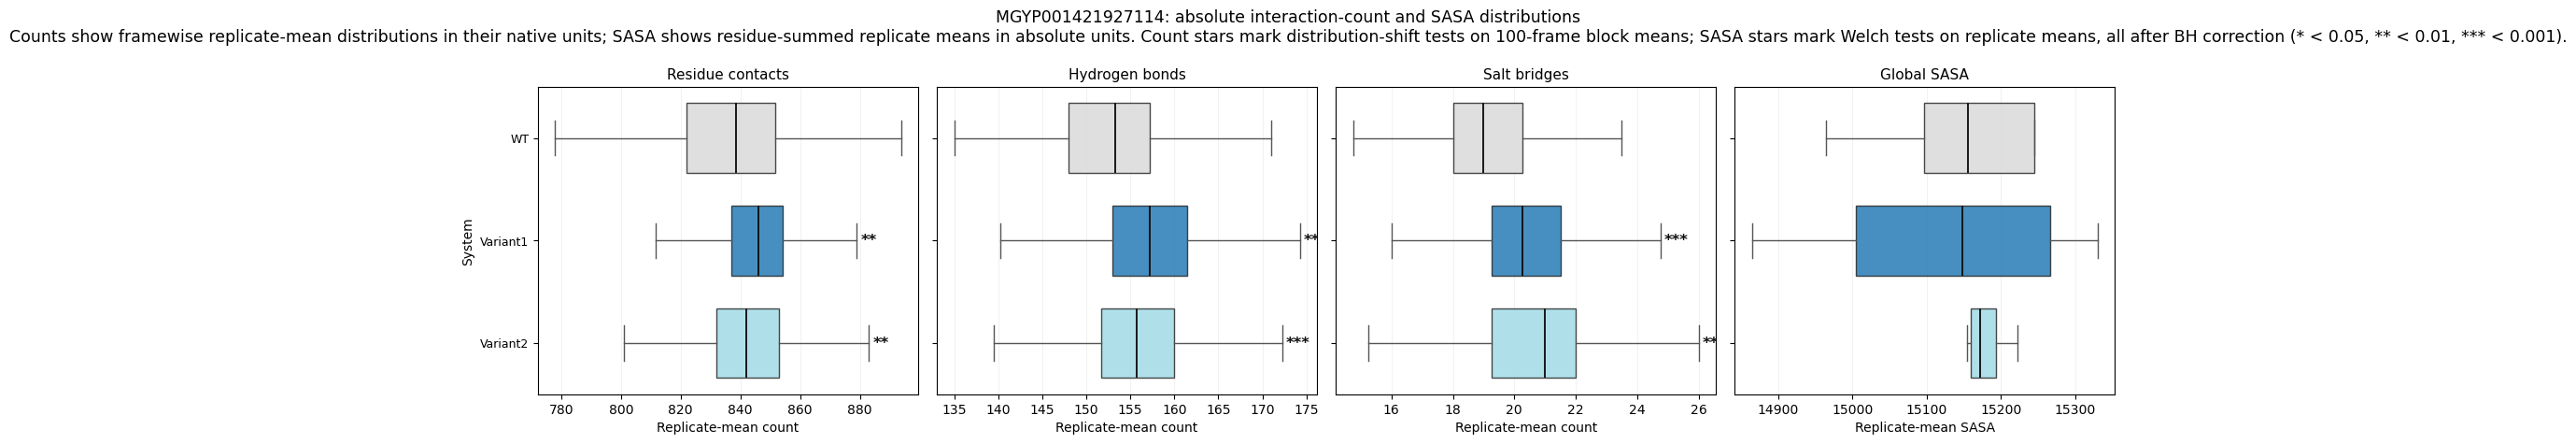

,family,system,short_label,wildtype_system,metric_key,metric_label,test_name,n_variant_samples,n_wildtype_samples,variant_mean,wildtype_mean,mean_difference,test_statistic,p_value,p_value_fdr,significant_fdr,stars,direction_vs_wt
0,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,4,4,14817.488461,14529.039562,288.448898,2.241041,0.076649,0.076649,False,,higher
1,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,4,4,14924.561150,14529.039562,395.521587,2.637561,0.053197,0.063836,False,,higher
2,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,362_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,4,4,14828.552879,14529.039562,299.513317,2.312130,0.070499,0.076649,False,,higher
3,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,A0A2S1LEZ1,hbond_counts,Hydrogen bonds,block_permutation_ks,700,700,156.153371,160.744929,-4.591557,0.358571,0.000500,0.000666,True,***,lower
4,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,A0A2S1LEZ1,hbond_counts,Hydrogen bonds,block_permutation_ks,700,700,157.353186,160.744929,-3.391743,0.295714,0.000500,0.000666,True,***,lower
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,MGYP001421927114,MGYP001421927114_1344_model_x_0,1344_model_x_0,MGYP001421927114,hbond_counts,Hydrogen bonds,block_permutation_ks,700,700,155.662886,154.134871,1.528014,0.118571,0.000500,0.001000,True,***,higher
72,MGYP001421927114,MGYP001421927114_1306_model_x_0,1306_model_x_0,MGYP001421927114,residue_contacts,Residue contacts,block_permutation_ks,700,700,845.526243,842.695557,2.830686,0.118571,0.001000,0.001333,True,**,higher
73,MGYP001421927114,MGYP001421927114_1344_model_x_0,1344_model_x_0,MGYP001421927114,residue_contacts,Residue contacts,block_permutation_ks,700,700,841.860743,842.695557,-0.834814,0.121429,0.001000,0.001333,True,**,lower
74,MGYP001421927114,MGYP001421927114_1306_model_x_0,1306_model_x_0,MGYP001421927114,saltbridge,Salt bridges,block_permutation_ks,700,700,20.296886,19.278229,1.018657,0.254286,0.000500,0.001000,True,***,higher


In [13]:
absolute_metric_significance_tables = []

for family_id in md_variant_bundle.family_ids:
    family_significance_df = helper_fugure4.compute_md_variant_absolute_metric_significance_df(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_block_by_metric=md_variant_bundle.interaction_count_block_by_metric,
        interaction_count_replicate_by_metric=md_variant_bundle.interaction_count_replicate_by_metric,
        global_sasa_replicate_df=md_variant_bundle.global_sasa_replicate_df,
    )
    absolute_metric_significance_tables.append(family_significance_df)
    display(
        family_significance_df[
            [
                'family', 'short_label', 'metric_label', 'variant_mean', 'wildtype_mean',
                'mean_difference', 'test_name', 'n_variant_samples', 'n_wildtype_samples',
                'p_value', 'p_value_fdr', 'stars', 'direction_vs_wt',
            ]
        ]
    )
    figure = helper_fugure4.plot_md_family_absolute_metric_boxplots(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_summary_by_metric=md_variant_bundle.interaction_count_summary_by_metric,
        interaction_count_block_by_metric=md_variant_bundle.interaction_count_block_by_metric,
        interaction_count_replicate_by_metric=md_variant_bundle.interaction_count_replicate_by_metric,
        global_sasa_replicate_df=md_variant_bundle.global_sasa_replicate_df,
        significance_df=family_significance_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_boxplots' / f'{family_id}_absolute_metric_boxplots.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)

absolute_metric_significance_df = pd.concat(absolute_metric_significance_tables, ignore_index=True)
absolute_metric_significance_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_absolute_metric_significance_vs_wt.csv',
    index=False,
)
display(absolute_metric_significance_df)


### Occupancy heatmaps for contacts, salt bridges, and H-bonds

How to read these panels:

- **Rows** are residue-residue interaction pairs.
- **Columns** are WT plus all variants in one family.
- **Color** is the mean occupancy of that pair across replicates, on a 0 to 1 scale.
- The row set is not all possible pairs. It is limited to the **top WT-divergent pairs**, ranked by the **largest absolute occupancy shift to WT across variants in the family**.

This is a practical ranking for interpretation, not a formal significance filter.



A0A2S1LEZ1: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,VAL124 - LEU128,1.000000,0.750000
1,2,THR126 - LEU130,1.000000,0.500004
2,3,THR126 - TYR130,1.000000,0.500000
3,4,VAL122 - THR126,0.999967,0.749839
4,5,VAL124 - TYR127,0.999933,0.749934
5,6,SER119 - VAL122,0.999917,0.749906
6,7,PHE152 - ILE156,0.999903,0.249976
7,8,THR124 - TYR127,0.999900,0.749925
8,9,PRO121 - VAL124,0.999797,0.749567
9,10,PRO121 - THR124,0.999757,0.749818


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_heatmaps/A0A2S1LEZ1_pair_occupancy_heatmaps.png


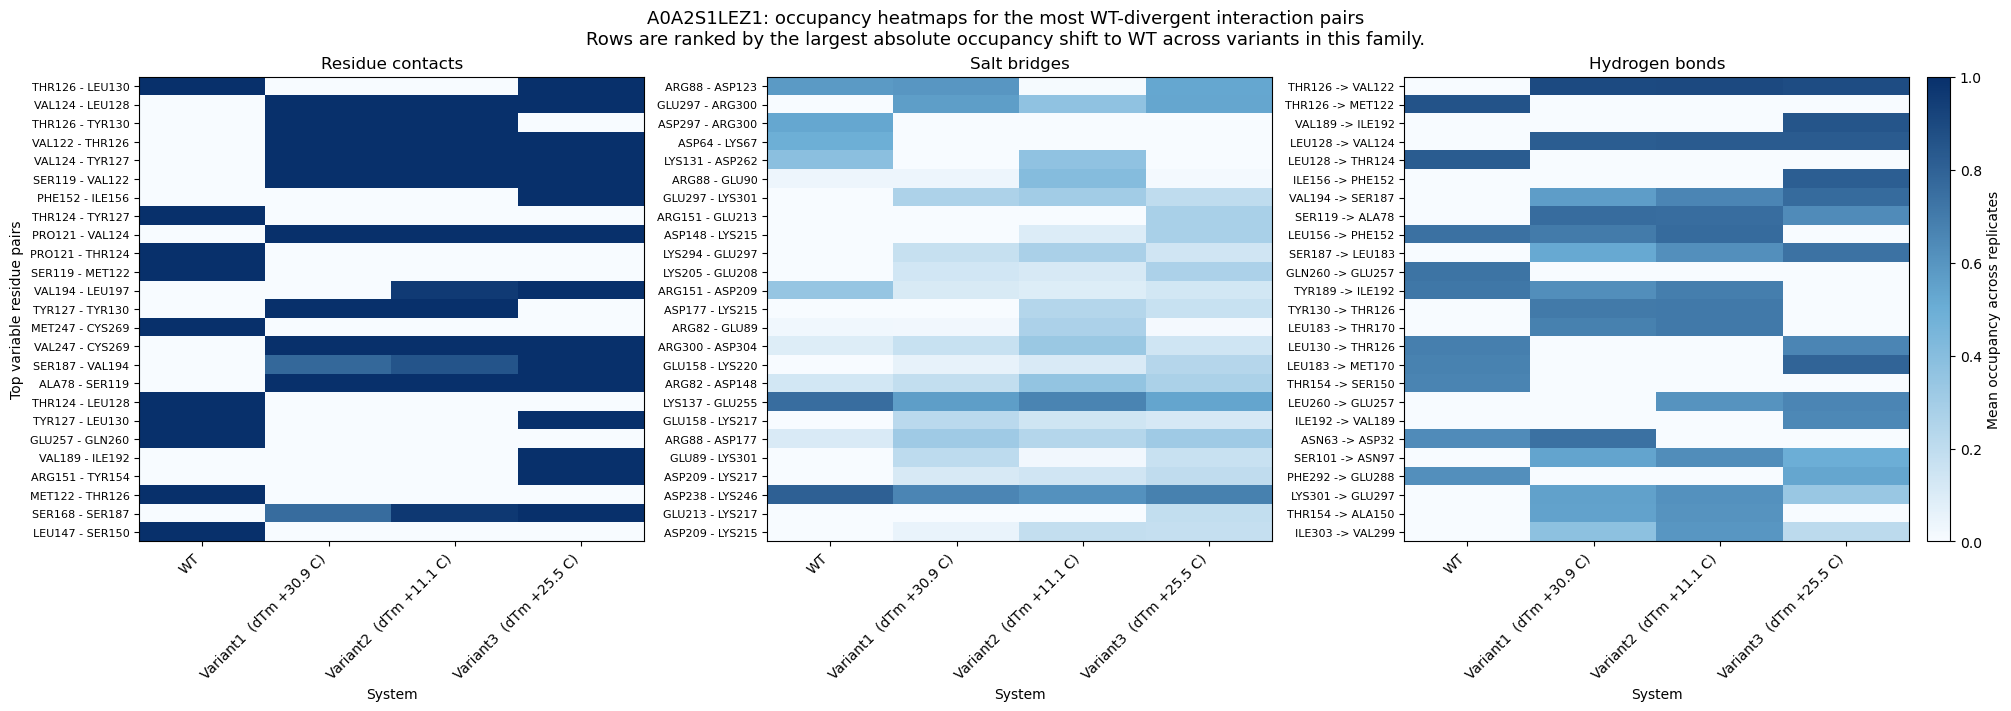


A0A372IUB3: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,TYR253 - TYR264,1.0,0.799852
1,2,THR285 - LYS289,1.0,0.465761
2,3,LYS270 - LYS278,1.0,0.399993
3,4,PRO136 - ARG139,1.0,0.399990
4,5,VAL270 - LYS278,1.0,0.333329
5,6,VAL270 - GLU277,1.0,0.333321
6,7,ALA252 - VAL265,1.0,0.133331
7,8,LEU248 - CYS269,1.0,0.066681
8,9,VAL74 - LEU115,1.0,0.066669
9,10,LEU115 - ILE141,1.0,0.066668


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_heatmaps/A0A372IUB3_pair_occupancy_heatmaps.png


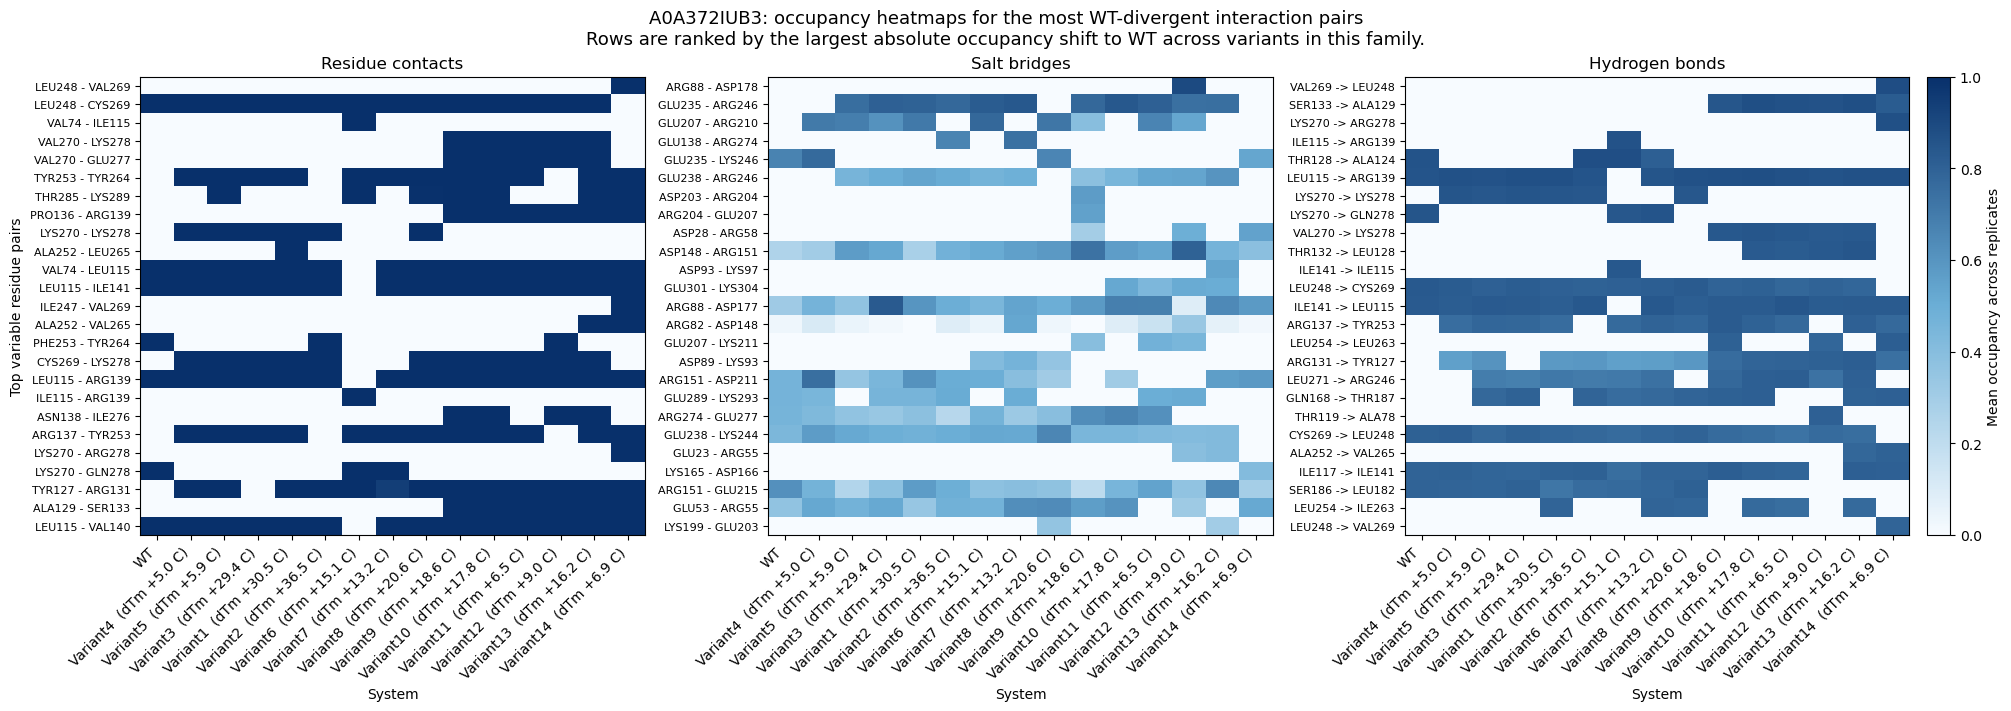


MGYP001421927114: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,ALA258 - ALA271,1.000000,0.666667
1,2,ALA258 - VAL271,0.999983,0.666256
2,3,LEU130 - SER134,0.999967,0.666500
3,4,LEU130 - CYS134,0.999863,0.666576
4,5,ALA257 - ALA271,0.999800,0.666533
5,6,ARG131 - GLU135,0.999787,0.666524
6,7,ARG131 - SER134,0.999723,0.664310
7,8,PHE171 - MET183,0.999650,0.666433
8,9,ARG131 - GLY135,0.999593,0.664996
9,10,GLY106 - TYR110,0.999503,0.662449


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/interaction_heatmaps/MGYP001421927114_pair_occupancy_heatmaps.png


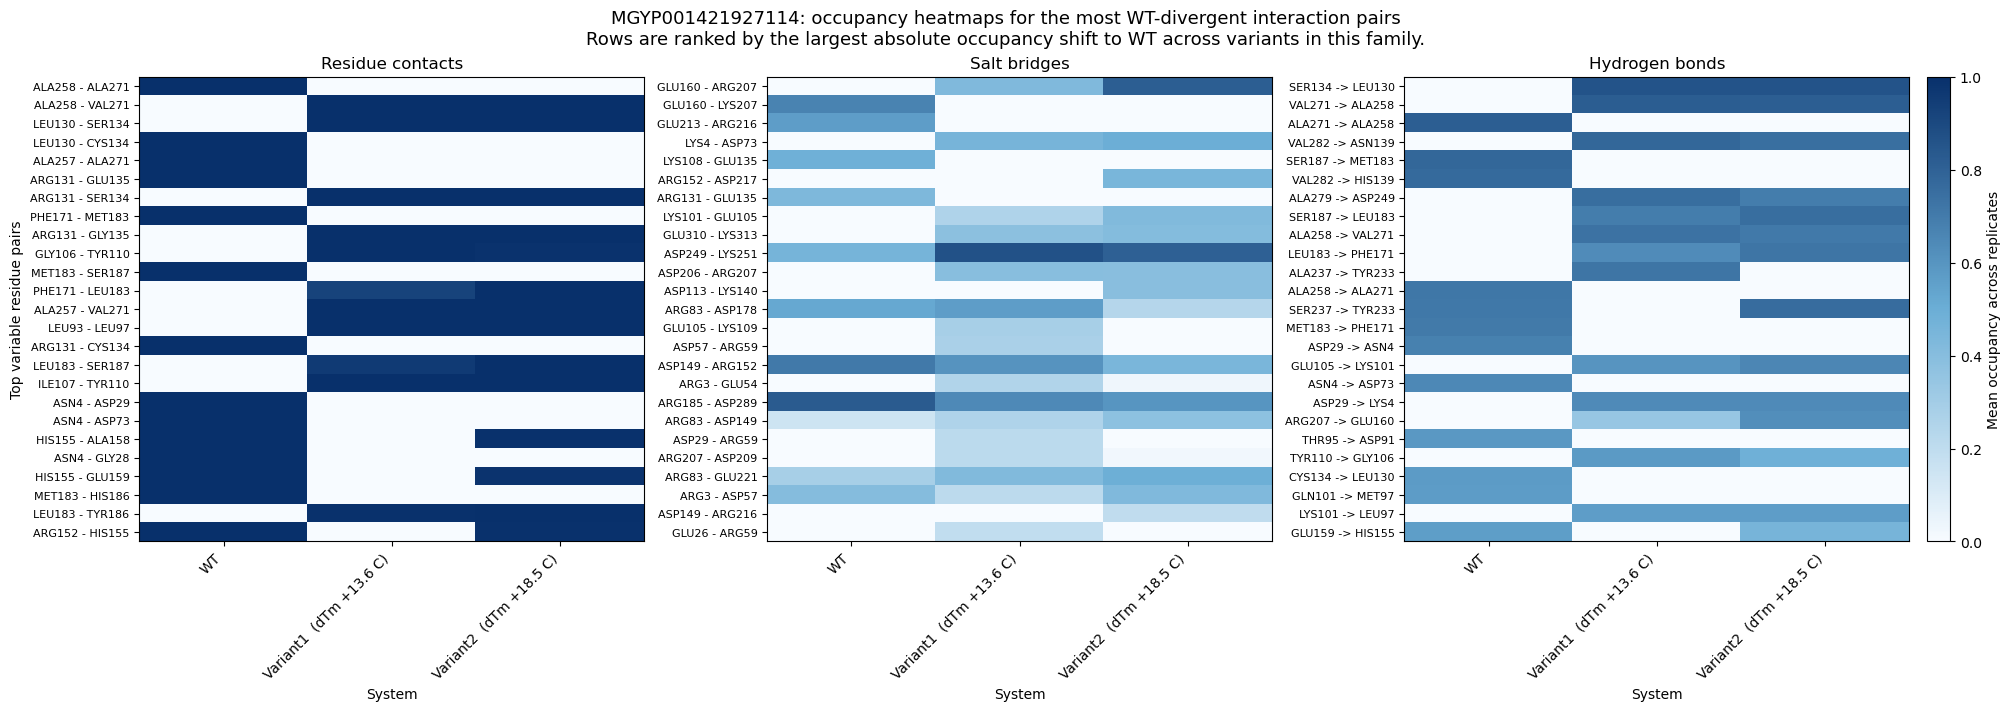

In [14]:
for family_id in md_variant_bundle.family_ids:
    print()
    print(f'{family_id}: top WT-divergent residue-contact pairs')
    display(
        md_family_pair_interest_tables[family_id]['residue_contact_pairs'][
            ['interest_rank', 'pair_label', 'max_abs_delta_vs_wt', 'mean_abs_delta_vs_wt']
        ].head(10)
    )
    figure = plot_md_family_pair_heatmaps(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        pair_summary_by_metric=md_variant_bundle.pair_summary_by_metric,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_heatmaps' / f'{family_id}_pair_occupancy_heatmaps.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Per-variant gained and lost interaction bars

How to read these panels:

- **Bars to the right of zero**: occupancy gained relative to WT.
- **Bars to the left of zero**: occupancy lost relative to WT.
- **Black outlines**: pairs that touch the local mutation neighborhood.
- Each panel shows the most extreme gained and lost pairs for one variant.

The notebook saves these plots for every variant but only previews the top-ranked variant from each family inline to keep the notebook readable.


A0A2S1LEZ1: previewing A0A2S1LEZ1_337_New_17444_0


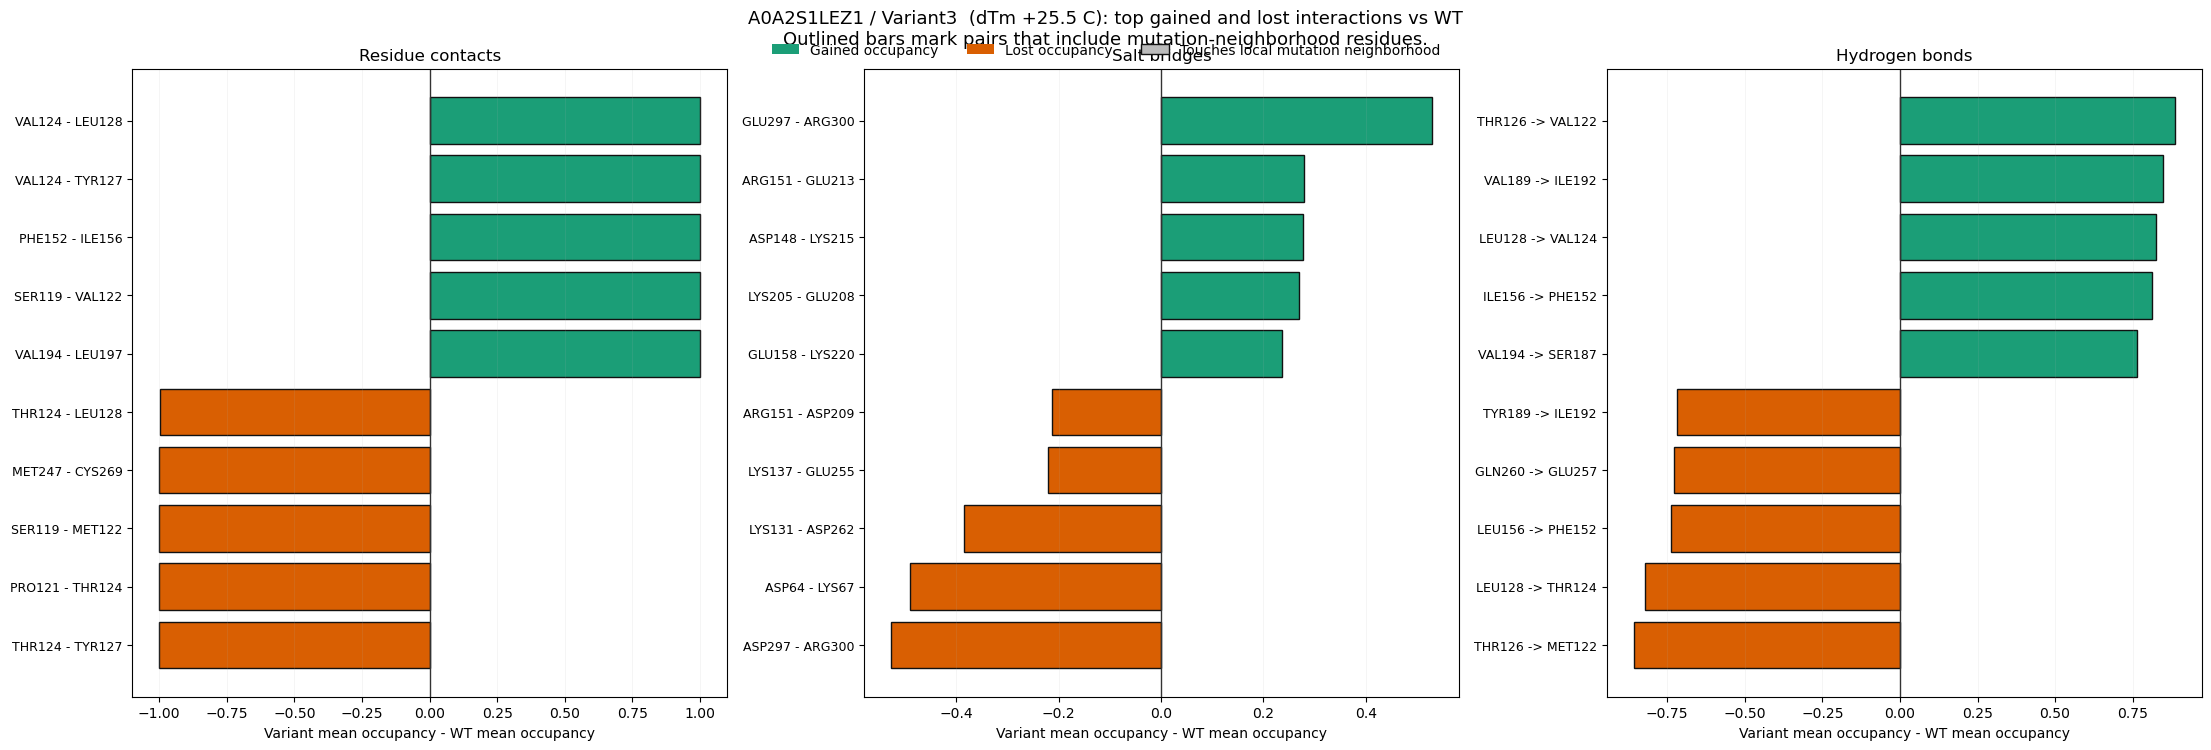

A0A372IUB3: previewing A0A372IUB3_103_New_19XXX_0


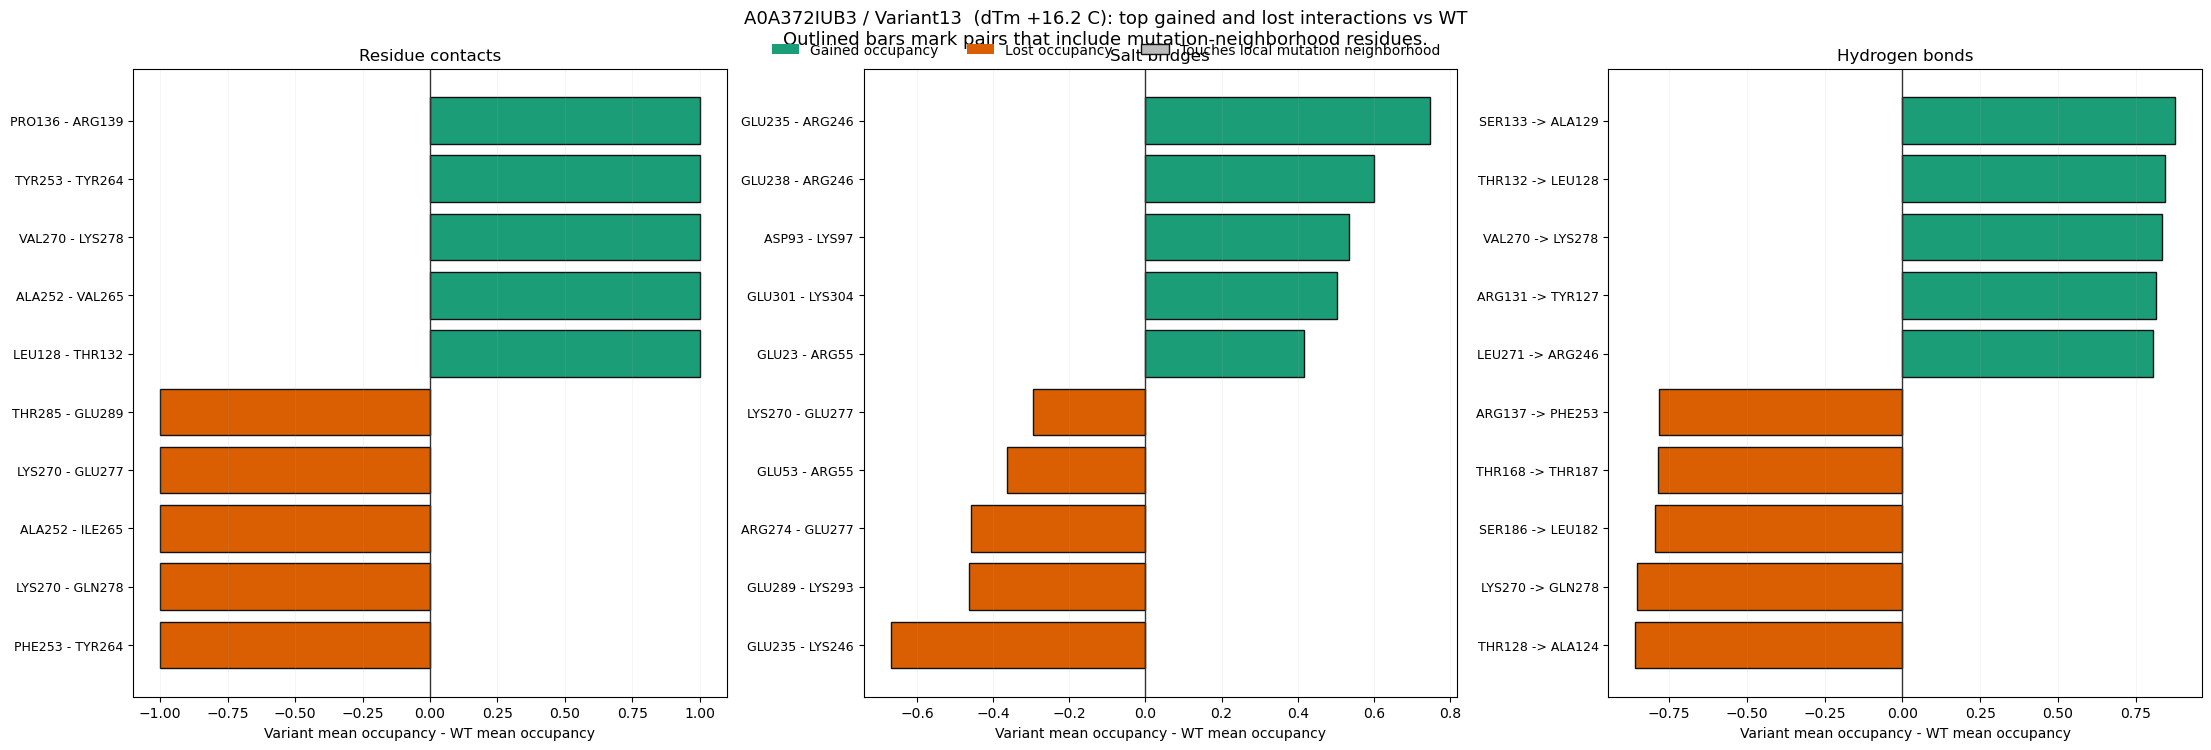

MGYP001421927114: previewing MGYP001421927114_1344_model_x_0


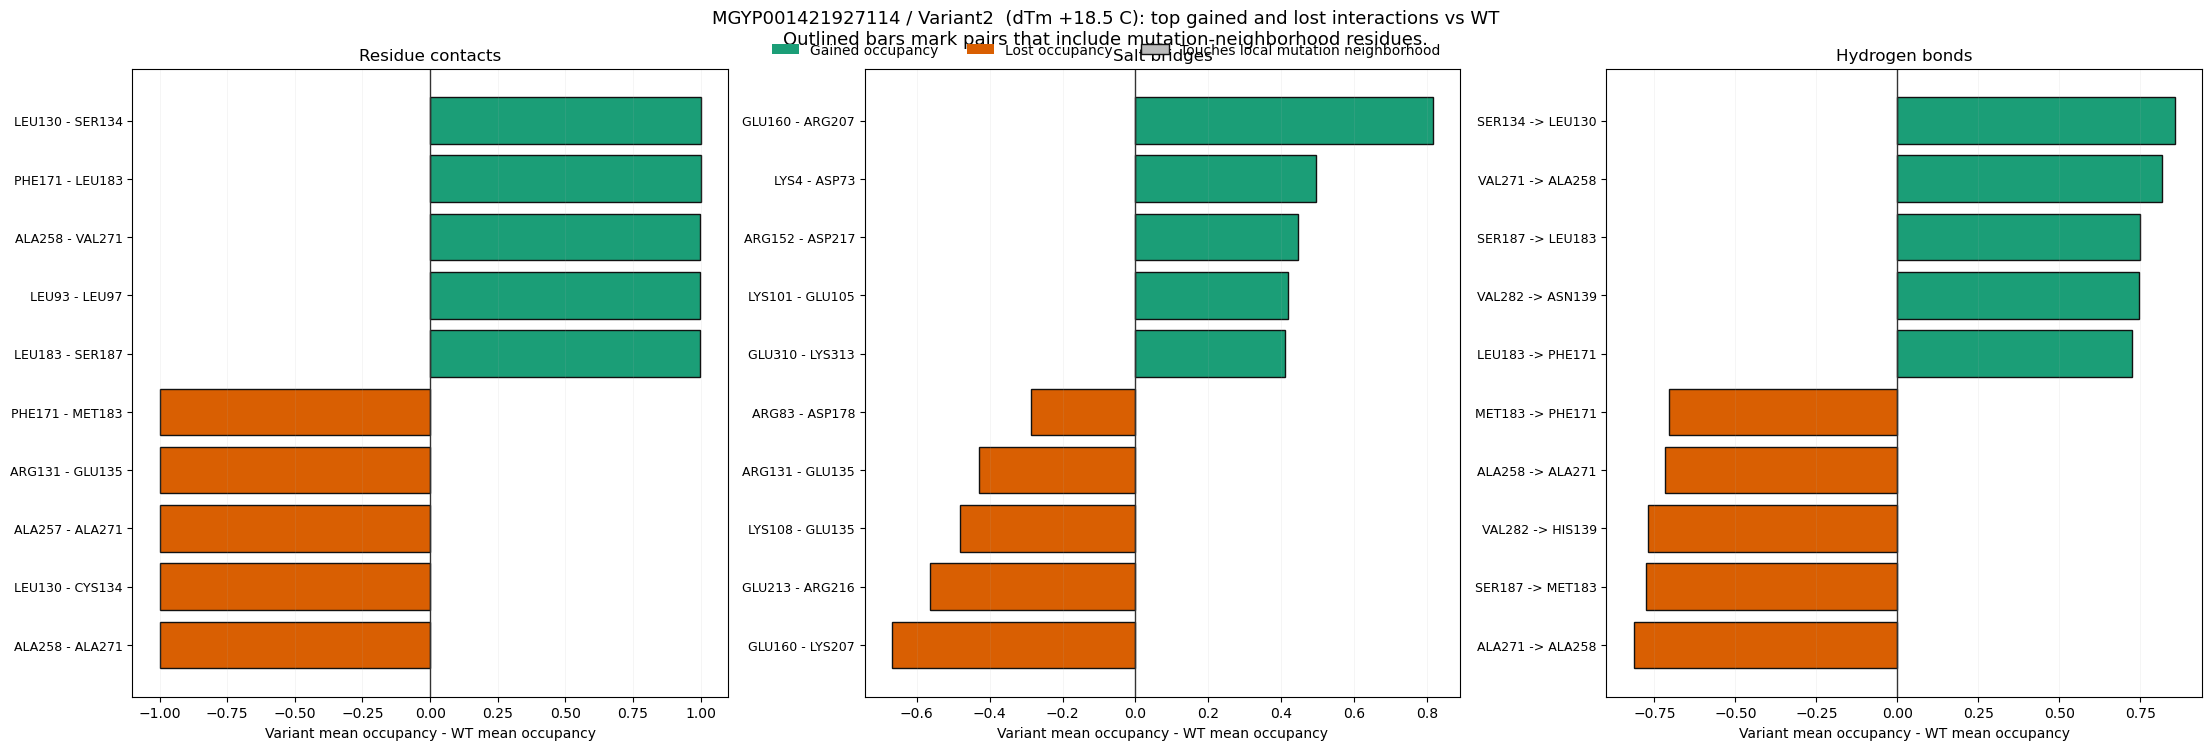

In [15]:
top_variant_by_family = (
    md_variant_bundle.variant_signal_df
    .sort_values(['family', 'family_rank', 'global_rank'])
    .groupby('family', as_index=False)
    .first()
)
preview_variant_lookup = {
    row['family']: row['variant_system']
    for _, row in top_variant_by_family.iterrows()
}

for family_id in md_variant_bundle.family_ids:
    preview_variant = preview_variant_lookup.get(family_id)
    for variant_system in compute_md_variant_order(md_variant_bundle.metadata_df, family_id):
        figure = plot_md_variant_pair_delta_bars(
            family_id=family_id,
            variant_system=variant_system,
            metadata_df=md_variant_bundle.metadata_df,
            pair_delta_by_metric=md_variant_bundle.pair_delta_by_metric,
        )
        if SAVE_MD_VARIANT_PLOTS:
            output_path = MD_VARIANT_PLOT_DIR / 'top_pair_deltas' / family_id / f'{variant_system}_top_pair_deltas.png'
            save_md_variant_figure(figure, output_path)
        if variant_system == preview_variant:
            print(f'{family_id}: previewing {variant_system}')
            plt.show()
        plt.close(figure)


### Local mutation-neighborhood summary

These heatmaps collapse the WT-vs-variant comparisons down to the mutation neighborhood.

- Each row is a variant.
- Each column is a local summary metric, such as neighborhood RMSF delta or local contact gain.
- The colors are **within-family z-scores**, so the heatmap emphasizes which variants are relatively stronger or weaker within the same WT family.

This is useful for checking whether stabilizing signatures are concentrated around mutation sites rather than being fully global.


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/neighborhood/A0A2S1LEZ1_local_neighborhood_summary.png


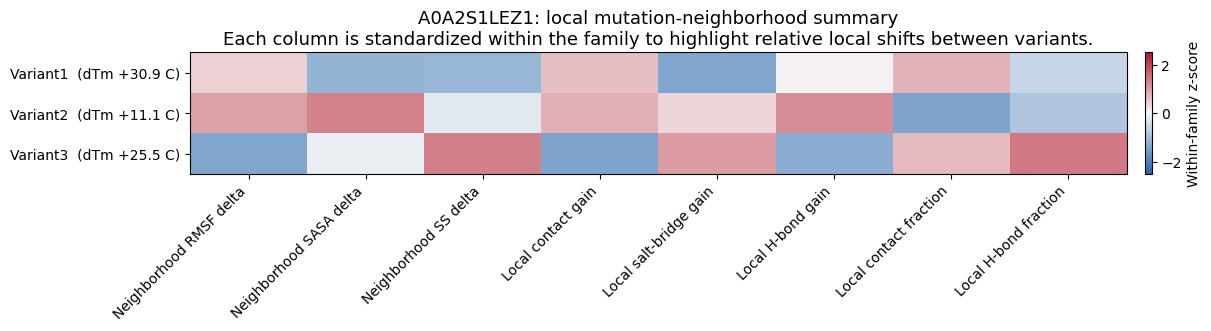

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/neighborhood/A0A372IUB3_local_neighborhood_summary.png


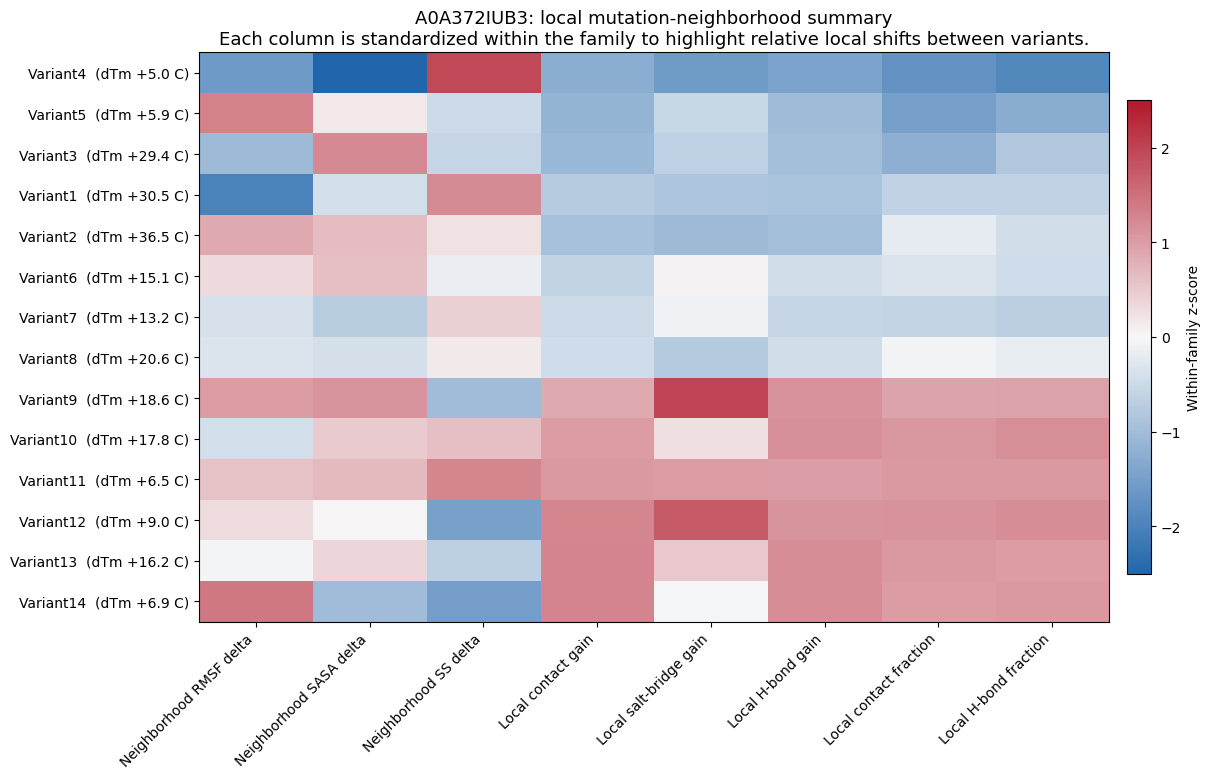

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/neighborhood/MGYP001421927114_local_neighborhood_summary.png


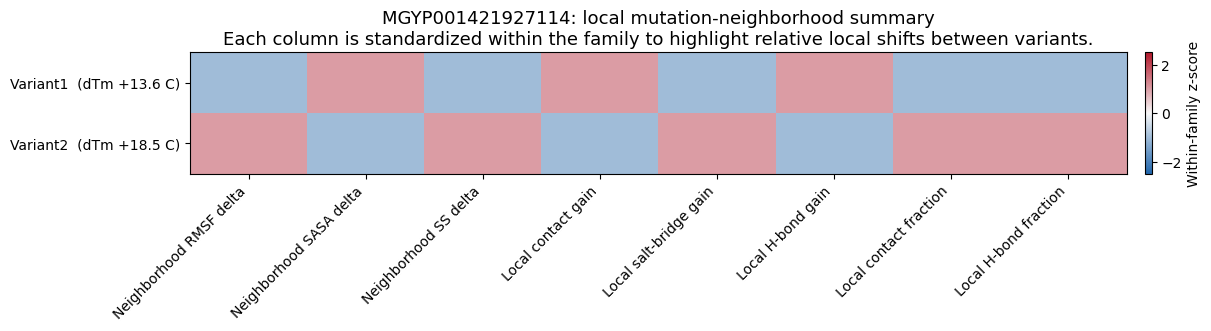

In [16]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_local_signal_heatmap(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        variant_signal_df=md_variant_bundle.variant_signal_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'neighborhood' / f'{family_id}_local_neighborhood_summary.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Secondary-structure retention

How to read these plots:

- **Stacked bars**: global mean helix, strand, and loop fractions for each WT or variant system.
- **Helix heatmap**: per-residue helix occupancy change in the variant relative to WT.
- **Strand heatmap**: per-residue strand occupancy change in the variant relative to WT.

Positive values mean that the variant preserves that ordered state more often than WT at that residue.


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/secondary_structure/A0A2S1LEZ1_secondary_structure_summary.png


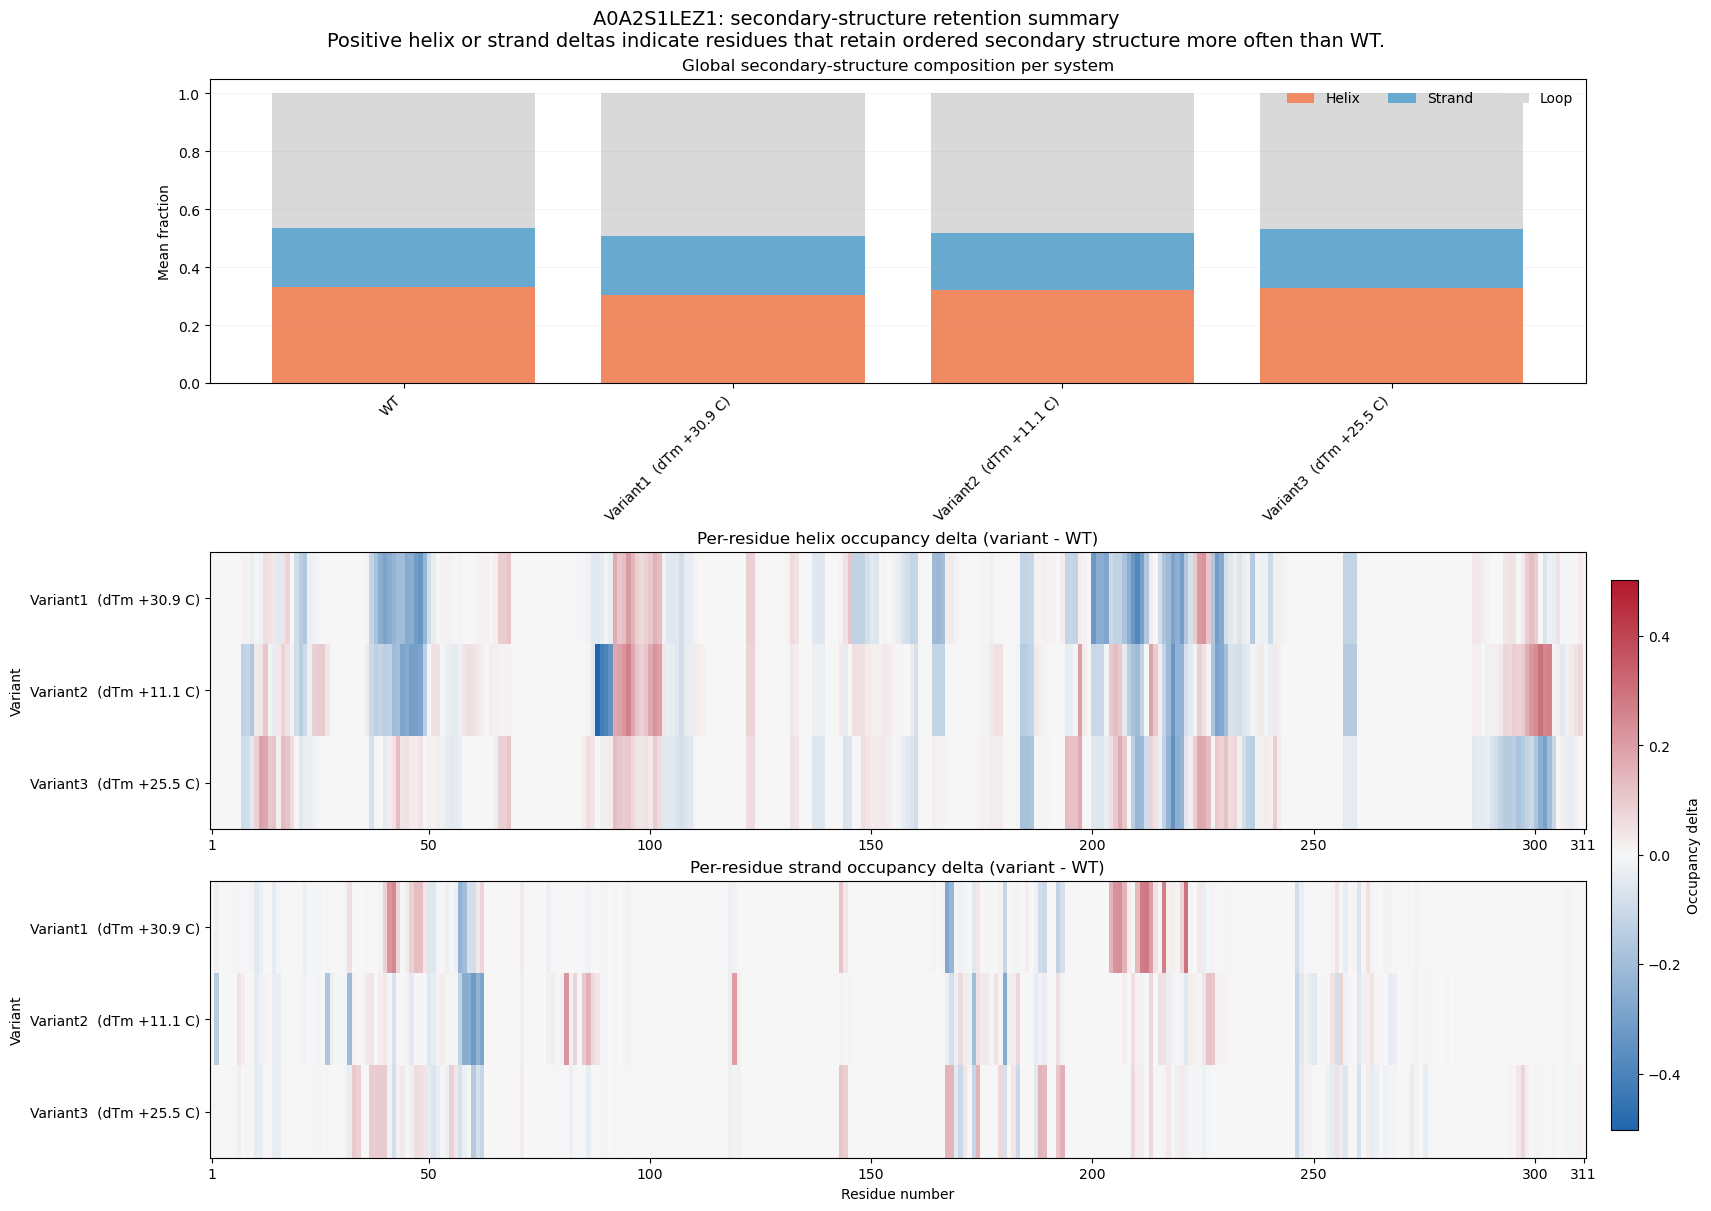

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/secondary_structure/A0A372IUB3_secondary_structure_summary.png


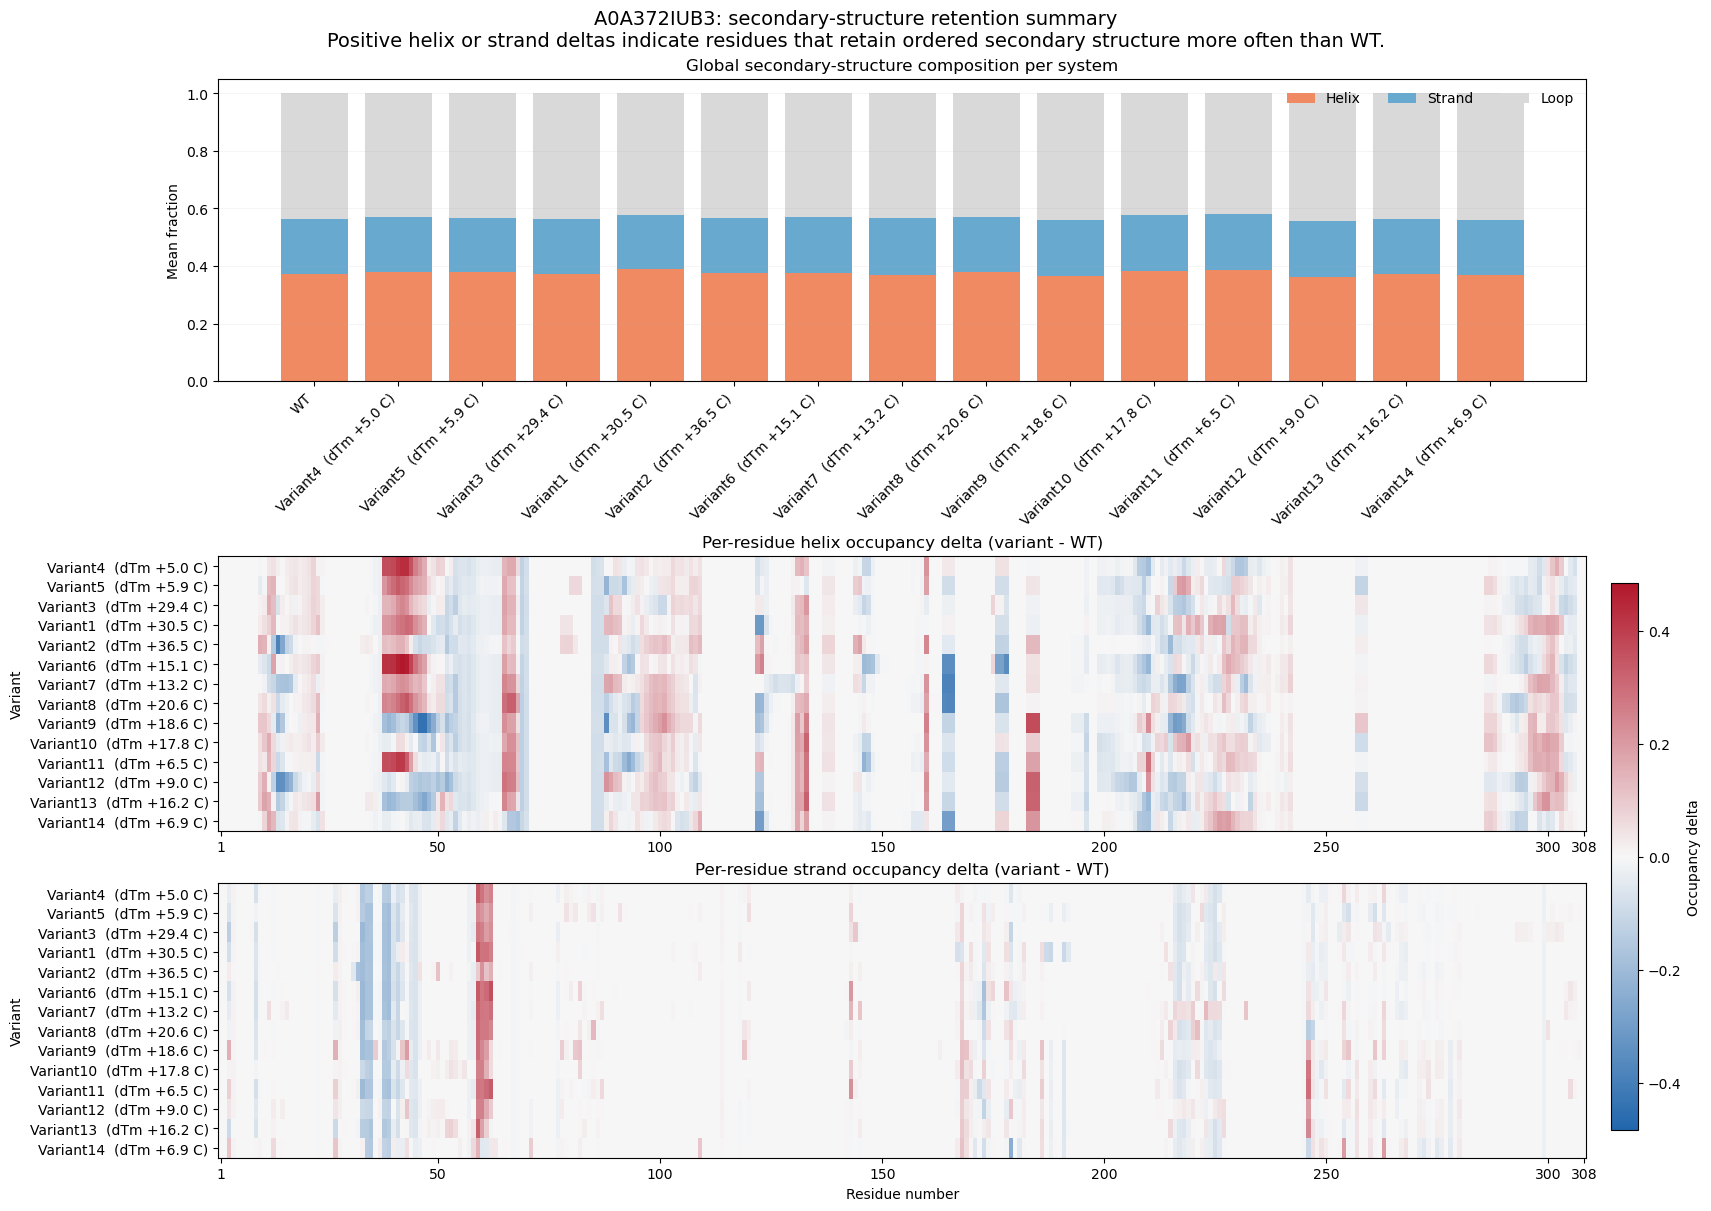

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/secondary_structure/MGYP001421927114_secondary_structure_summary.png


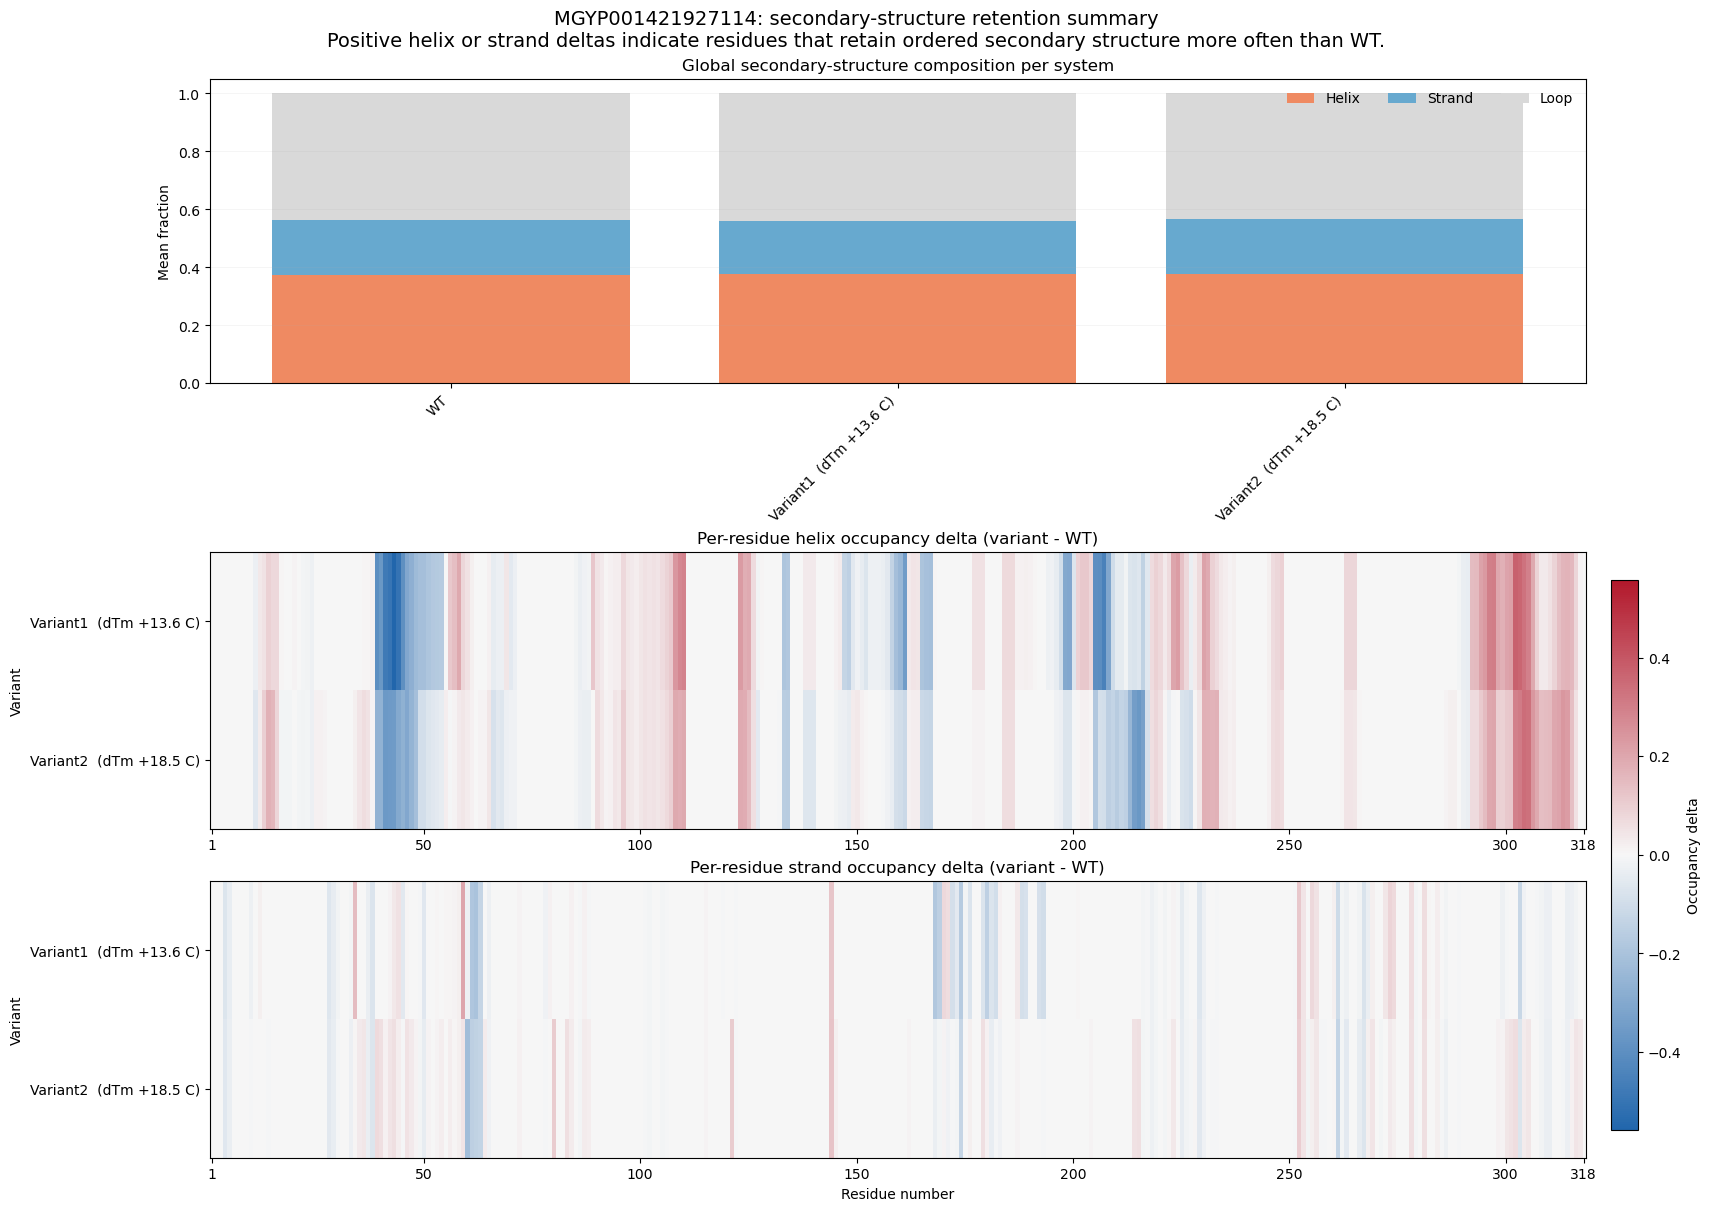

In [17]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_secondary_structure_summary(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        ss_counts_summary_df=md_variant_bundle.ss_counts_summary_df,
        ss_residue_delta_df=md_variant_bundle.ss_residue_delta_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'secondary_structure' / f'{family_id}_secondary_structure_summary.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Summary dashboard and shared patterns

The dashboard ranks variants by a simple composite score built from six WT-relative signals:

1. lower RMSF in the mutation neighborhood,
2. increased residue-contact occupancy,
3. increased salt-bridge occupancy,
4. increased H-bond occupancy,
5. lower SASA in the mutation neighborhood,
6. higher ordered secondary-structure retention in the mutation neighborhood.

Each signal is converted to a percentile-style rank and the composite score is the mean of those ranks. This is a **heuristic prioritization score**, not a trained predictor of melting temperature.


/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/dashboard/variant_signal_dashboard.png


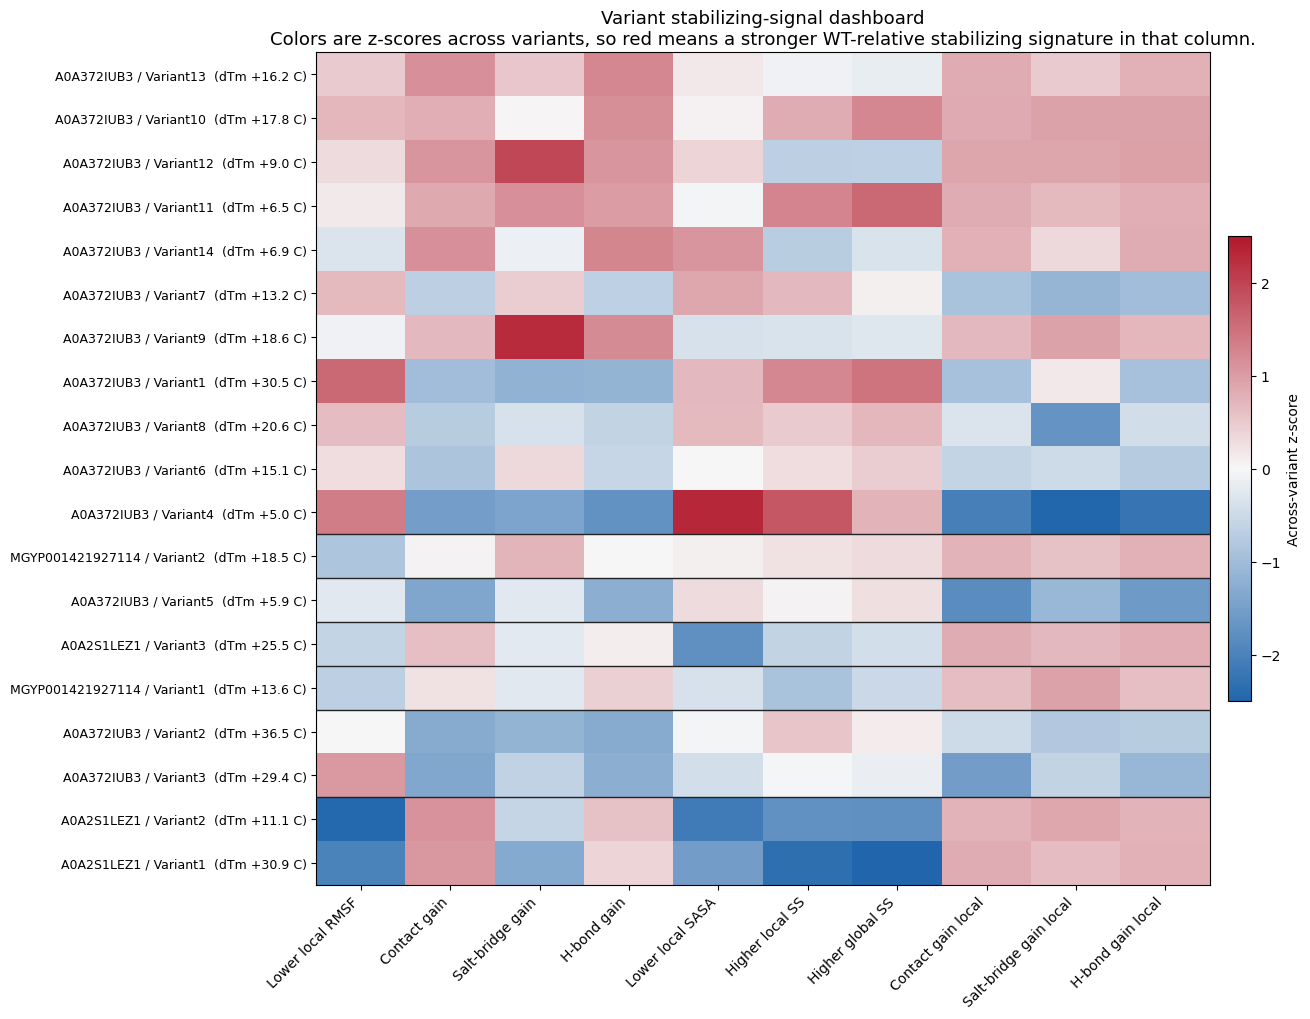

/Users/sandravi/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_longest_stop_mixed_stop/plots/dashboard/family_shared_pattern_heatmap.png


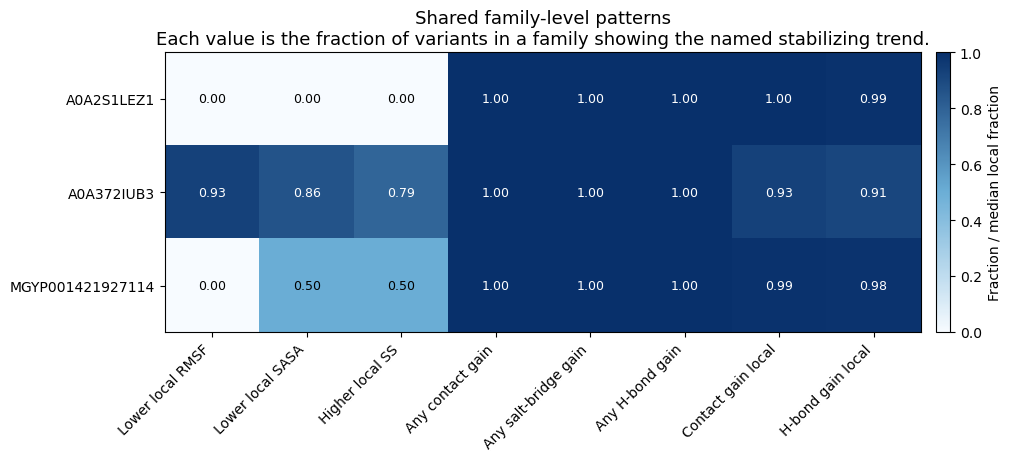

,global_rank,family,family_rank,variant_label,median_tm_celsius,delta_tm_to_wildtype_celsius,composite_stabilizing_score,delta_rmsf_neighborhood_mean,contact_gain_total,saltbridge_gain_total,hbond_gain_total,delta_sasa_neighborhood_mean,delta_ordered_ss_neighborhood_mean,delta_ordered_fraction_global
0,1.0,A0A372IUB3,1.0,Variant13 (dTm +16.2 C),72.1360,16.2240,0.736842,-0.225170,266.062617,7.248557,52.618347,-0.268407,0.001705,-0.001007
1,2.0,A0A372IUB3,2.0,Variant10 (dTm +17.8 C),73.7585,17.8465,0.728070,-0.286242,247.182120,6.557090,51.753197,-0.199738,0.012395,0.012293
2,3.0,A0A372IUB3,3.0,Variant12 (dTm +9.0 C),64.8800,8.9680,0.701754,-0.169883,262.852857,9.131543,51.090457,-0.440176,-0.004989,-0.005660
3,3.0,A0A372IUB3,3.0,Variant11 (dTm +6.5 C),62.3620,6.4500,0.701754,-0.125057,250.228057,8.033803,50.212993,-0.106245,0.017690,0.015699
4,4.0,A0A372IUB3,4.0,Variant14 (dTm +6.9 C),62.8599,6.9479,0.675439,0.004546,266.162907,6.373910,52.670340,-0.987639,-0.005293,-0.002651
5,5.0,A0A372IUB3,5.0,Variant7 (dTm +13.2 C),69.0969,13.1849,0.657895,-0.275765,163.982213,7.143280,33.802343,-0.834524,0.010868,0.001393
6,6.0,A0A372IUB3,6.0,Variant9 (dTm +18.6 C),74.5336,18.6216,0.596491,-0.058596,241.060423,9.535437,52.110477,0.125579,-0.001130,-0.002129
7,7.0,A0A372IUB3,7.0,Variant1 (dTm +30.5 C),86.3846,30.4726,0.570175,-0.535807,146.506923,4.962773,29.058610,-0.678345,0.017183,0.014405
8,8.0,A0A372IUB3,8.0,Variant8 (dTm +20.6 C),76.5092,20.5972,0.552632,-0.269847,161.052490,6.039580,34.304283,-0.672196,0.008496,0.007460
9,9.0,A0A372IUB3,9.0,Variant6 (dTm +15.1 C),70.9832,15.0712,0.517544,-0.166600,153.437960,6.978040,34.906717,-0.131384,0.006076,0.004906


,family,n_variants,fraction_lower_local_rmsf,fraction_lower_local_sasa,fraction_higher_local_ss,fraction_contact_gain,fraction_saltbridge_gain,fraction_hbond_gain,median_composite_score,median_contact_local_fraction,median_hbond_local_fraction
0,A0A2S1LEZ1,3,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.350877,0.995469,0.987504
1,A0A372IUB3,14,0.928571,0.857143,0.785714,1.0,1.0,1.0,0.583333,0.926708,0.909380
2,MGYP001421927114,2,0.000000,0.500000,0.500000,1.0,1.0,1.0,0.447368,0.988142,0.983670
3,ALL,19,0.684211,0.684211,0.631579,1.0,1.0,1.0,0.517544,0.988443,0.984471


In [18]:
dashboard_figure = plot_md_variant_signal_dashboard(md_variant_bundle.variant_signal_df)
if SAVE_MD_VARIANT_PLOTS:
    output_path = MD_VARIANT_PLOT_DIR / 'dashboard' / 'variant_signal_dashboard.png'
    save_md_variant_figure(dashboard_figure, output_path)
    print(output_path)
plt.show()
plt.close(dashboard_figure)

family_pattern_figure = plot_md_variant_family_pattern_heatmap(md_variant_bundle.family_pattern_summary_df)
if SAVE_MD_VARIANT_PLOTS:
    output_path = MD_VARIANT_PLOT_DIR / 'dashboard' / 'family_shared_pattern_heatmap.png'
    save_md_variant_figure(family_pattern_figure, output_path)
    print(output_path)
plt.show()
plt.close(family_pattern_figure)

display(
    md_variant_bundle.variant_signal_df[
        [
            'global_rank', 'family', 'family_rank', 'variant_label',
            'median_tm_celsius', 'delta_tm_to_wildtype_celsius',
            'composite_stabilizing_score', 'delta_rmsf_neighborhood_mean',
            'contact_gain_total', 'saltbridge_gain_total', 'hbond_gain_total',
            'delta_sasa_neighborhood_mean', 'delta_ordered_ss_neighborhood_mean',
            'delta_ordered_fraction_global',
        ]
    ]
)
display(md_variant_bundle.family_pattern_summary_df)


## WT-anchored interactive structure views

This section is a clean restart. It creates one Mol* view that loads the three wildtype structures only, after CA-based alignment to a shared WT reference and export into one combined PDB for direct superposition.


In [19]:
WT_SUPERPOSITION_OUTPUT_DIR = FIGURE4_MOLSTAR_OUTPUT_DIR / 'wildtype_superposition' / md_variant_bundle.metric_window_suffix
wt_superposition_export = export_wildtype_superposition_molstar_view(
    structure_family_df=structure_family_df,
    output_dir=WT_SUPERPOSITION_OUTPUT_DIR,
    viewer_height_px=FIGURE4_MOLSTAR_VIEWER_HEIGHT_PX,
    reference_family_id=FIGURE4_WT_SUPERPOSITION_REFERENCE_FAMILY,
)

wt_superposition_alignment_df = wt_superposition_export.alignment_summary_df.copy()
wt_superposition_html_relpath = Path(wt_superposition_export.html_path).relative_to(PROJECT_ROOT).as_posix()
wt_superposition_html_iframe_src = f"/files/{wt_superposition_html_relpath.lstrip('/')}"
wt_superposition_pdb_relpath = Path(wt_superposition_export.pdb_path).relative_to(PROJECT_ROOT).as_posix()

display(pd.DataFrame([{
    'reference_family_id': wt_superposition_alignment_df['reference_family_id'].iloc[0],
    'wildtype_count': len(wt_superposition_alignment_df),
    'html_relpath': wt_superposition_html_relpath,
    'pdb_relpath': wt_superposition_pdb_relpath,
}]))

display(
    wt_superposition_alignment_df[
        [
            'family_id', 'reference_family_id', 'alignment_method', 'aligned_length',
            'rmsd_angstrom', 'tm_score_to_reference', 'chain_id', 'aligned_pdb_path',
        ]
    ].sort_values(['family_id'])
)


,reference_family_id,wildtype_count,html_relpath,pdb_relpath
0,A0A2S1LEZ1,3,Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/wildtype_superposition.html,Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/wildtype_superposition_aligned_to_A0A2S1LEZ1.pdb


,family_id,reference_family_id,alignment_method,aligned_length,rmsd_angstrom,tm_score_to_reference,chain_id,aligned_pdb_path
0,A0A2S1LEZ1,A0A2S1LEZ1,reference_identity,311,0.000000,1.000000,A,/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/aligned_wildtypes/A0A2S1LEZ1_aligned_to_A0A2S1LEZ1.pdb
1,A0A372IUB3,A0A2S1LEZ1,ca_superposition,308,2.748322,0.881313,B,/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/aligned_wildtypes/A0A372IUB3_aligned_to_A0A2S1LEZ1.pdb
2,MGYP001421927114,A0A2S1LEZ1,ca_superposition,311,7.721481,0.545904,C,/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/aligned_wildtypes/MGYP001421927114_aligned_to_A0A2S1LEZ1.pdb


In [20]:
display(HTML(
    f"<p><strong>Wildtype structural superposition</strong> | reference WT <strong>{wt_superposition_alignment_df['reference_family_id'].iloc[0]}</strong> | "
    f"{len(wt_superposition_alignment_df)} aligned WT structures</p>"
))
display(IFrame(
    src=wt_superposition_html_iframe_src,
    width='100%',
    height=FIGURE4_MOLSTAR_VIEWER_HEIGHT_PX + 120,
))


## WT ChimeraX residue-color commands

This section builds **family-averaged WT residue coloring commands for ChimeraX** from the MD bundle that is already loaded above.

- `metric = 'rmsf'`: residue colors come from the **mean WT-relative RMSF delta across all variants** in the family.
- `metric = 'saltbridge_pairs'` or `metric = 'hbond_pairs'`: residue colors come from the **mean WT-relative interaction occupancy shift across all variants**, collapsed from residue-pair changes down to per-residue scores.
- `metric = 'interaction_change'` with `color_mode = 'combined'`: each residue is assigned to the **strongest interaction-change class after within-family z-scoring** across four channels: H-bond gain, H-bond loss, salt-bridge gain, or salt-bridge loss. Explicit z-score breaks control how many colored intervals are used; residues below the first break remain neutral.
- `target_layout = 'combined_model'`: color one combined WT superposition model with family-specific chains (`A/B/C`).
- `target_layout = 'separate_models'`: color separately opened WT models such as `#1`, `#2`, `#3`, all on the same chain such as `A`.
- `color_mode = 'signed'`: blue means lower / lost relative to WT and red means higher / gained relative to WT. The default signed mode now uses **explicit family-wise z-score bins** so the shades correspond to concrete |z| intervals.
- `color_mode = 'destabilizing'`: only the destabilizing direction is highlighted in red: **RMSF increase** or **interaction loss**.
- `color_mode = 'stabilizing'`: only the stabilizing direction is highlighted in red: **RMSF decrease** or **interaction gain**.
- `color_mode = 'combined'`: only for `interaction_change`; residues get one of four colors depending on whether the strongest standardized signal is H-bond gain, H-bond loss, salt-bridge gain, or salt-bridge loss.
- `color_mode = 'majority_significance'`: only for `saltbridge_pairs` and `hbond_pairs`; residues are colored only when a **majority of variants in the family** show an FDR-significant occupancy shift vs WT in the same direction, using explicit fraction bins.
- `emphasize_colored_residues = True`: optional ChimeraX overlay that also **shows the colored residues as atoms** and switches them to a chosen atom style such as `ball`, making them stand out more strongly from the rest of the structure.

The section writes both a residue score table and `.cxc` command files into `Results/Figure4/chimerax/<metric_window>/`.


In [21]:
CHIMERAX_OUTPUT_DIR = FIGURE4_OUTPUT_DIR / 'chimerax' / md_variant_bundle.metric_window_suffix
CHIMERAX_METRIC = 'rmsf'  # 'rmsf', 'saltbridge_pairs', 'hbond_pairs', or 'interaction_change'
CHIMERAX_COLOR_MODE = 'signed'  # 'signed', 'destabilizing', 'stabilizing', 'combined', or 'majority_significance'
CHIMERAX_SIGNED_SCORE_MODE = 'zscore'  # 'zscore' or 'raw'
CHIMERAX_SIGNED_Z_BREAKS = (1.0, 2.0, 3.0)
CHIMERAX_TARGET_LAYOUT = 'separate_models'  # 'combined_model' or 'separate_models'
CHIMERAX_MODEL_ID = '#1'  # used for the combined-model layout
CHIMERAX_SEPARATE_MODEL_CHAIN_ID = 'A'  # used for the separate-model layout
CHIMERAX_MODEL_ID_BY_FAMILY = {
    row.family_id: f'#{row_index + 1}'
    for row_index, row in enumerate(
        wt_superposition_alignment_df.sort_values('family_id').itertuples(index=False)
    )
}  # example: {'A0A2S1LEZ1': '#1', 'A0A372IUB3': '#2', 'MGYP001421927114': '#3'}
CHIMERAX_INTERACTION_Z_BREAKS = (2.0,)  # one value = neutral below z=2, one colored interval at z>=2
CHIMERAX_INTERACTION_COLORS = {
    'saltbridge_gain': ('#D55E00',),  # vermillion
    'saltbridge_loss': ('#007A5E',),  # bluish green / teal
    'hbond_gain': ('#B88600',),       # dark yellow / gold
    'hbond_loss': ('#0072B2',),       # blue 
}
CHIMERAX_SIGNIFICANCE_ALPHA = 0.05
CHIMERAX_MAJORITY_FRACTION_THRESHOLD = 0.5
CHIMERAX_EMPHASIZE_COLORED_RESIDUES = False  # opt in to write separate *_highlight exports
CHIMERAX_EMPHASIS_STYLE = 'sphere'  # 'ball', 'stick', or 'sphere'
CHIMERAX_NEUTRAL_COLOR = '#c1c1c1'

display(pd.DataFrame([{
    'target_layout': CHIMERAX_TARGET_LAYOUT,
    'signed_score_mode': CHIMERAX_SIGNED_SCORE_MODE,
    'signed_z_breaks': CHIMERAX_SIGNED_Z_BREAKS,
    'combined_model_id': CHIMERAX_MODEL_ID,
    'separate_model_chain_id': CHIMERAX_SEPARATE_MODEL_CHAIN_ID,
    'separate_model_id_by_family': CHIMERAX_MODEL_ID_BY_FAMILY,
    'interaction_z_breaks': CHIMERAX_INTERACTION_Z_BREAKS,
    'interaction_colors': CHIMERAX_INTERACTION_COLORS,
    'significance_alpha': CHIMERAX_SIGNIFICANCE_ALPHA,
    'majority_fraction_threshold': CHIMERAX_MAJORITY_FRACTION_THRESHOLD,
    'emphasize_colored_residues': CHIMERAX_EMPHASIZE_COLORED_RESIDUES,
    'emphasis_style': CHIMERAX_EMPHASIS_STYLE,
    'output_dir': CHIMERAX_OUTPUT_DIR,
}]))


,target_layout,signed_score_mode,signed_z_breaks,combined_model_id,separate_model_chain_id,separate_model_id_by_family,interaction_z_breaks,interaction_colors,significance_alpha,majority_fraction_threshold,emphasize_colored_residues,emphasis_style,output_dir
0,separate_models,zscore,"(1.0, 2.0, 3.0)",#1,A,"{'A0A2S1LEZ1': '#1', 'A0A372IUB3': '#2', 'MGYP001421927114': '#3'}","(2.0,)","{'saltbridge_gain': ('#D55E00',), 'saltbridge_loss': ('#007A5E',), 'hbond_gain': ('#B88600',), 'hbond_loss': ('#0072B2',)}",0.05,0.5,False,sphere,/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/chimerax/0_longest_stop_mixed_stop


In [22]:
CHIMERAX_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wt_chimerax_bundle = build_wildtype_chimerax_command_bundle(
    md_variant_bundle=md_variant_bundle,
    wildtype_alignment_df=wt_superposition_alignment_df,
    metric_name=CHIMERAX_METRIC,
    color_mode=CHIMERAX_COLOR_MODE,
    combined_pdb_path=wt_superposition_export.pdb_path,
    model_id=CHIMERAX_MODEL_ID,
    target_layout=CHIMERAX_TARGET_LAYOUT,
    separate_model_id_by_family=CHIMERAX_MODEL_ID_BY_FAMILY,
    separate_model_chain_id=CHIMERAX_SEPARATE_MODEL_CHAIN_ID,
    interaction_change_z_breaks=CHIMERAX_INTERACTION_Z_BREAKS,
    interaction_colors=CHIMERAX_INTERACTION_COLORS,
    significance_alpha=CHIMERAX_SIGNIFICANCE_ALPHA,
    majority_fraction_threshold=CHIMERAX_MAJORITY_FRACTION_THRESHOLD,
    emphasize_colored_residues=CHIMERAX_EMPHASIZE_COLORED_RESIDUES,
    emphasis_style=CHIMERAX_EMPHASIS_STYLE,
    signed_score_mode=CHIMERAX_SIGNED_SCORE_MODE,
    signed_z_breaks=CHIMERAX_SIGNED_Z_BREAKS,
    neutral_color=CHIMERAX_NEUTRAL_COLOR,
)

if wt_chimerax_bundle.residue_color_df.empty:
    print('No WT ChimeraX residue scores could be built for the selected metric.')
else:
    selected_metric_name = str(wt_chimerax_bundle.residue_color_df['metric_name'].iloc[0])
    emphasis_suffix = (
        f'_{CHIMERAX_EMPHASIS_STYLE}_highlight'
        if CHIMERAX_EMPHASIZE_COLORED_RESIDUES
        else ''
    )
    selected_slug = f'{selected_metric_name}_{CHIMERAX_COLOR_MODE}{emphasis_suffix}'
    wt_chimerax_apply_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{selected_slug}_apply_to_existing_model.cxc'
    wt_chimerax_open_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{selected_slug}_open_and_color.cxc'
    wt_chimerax_table_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{selected_slug}_residue_scores.csv'

    wt_chimerax_apply_path.write_text(wt_chimerax_bundle.apply_command + '\n')
    wt_chimerax_open_path.write_text(wt_chimerax_bundle.open_command + '\n')
    wt_chimerax_bundle.residue_color_df.to_csv(wt_chimerax_table_path, index=False)

    display(pd.DataFrame([{
        'metric_name': selected_metric_name,
        'color_mode': CHIMERAX_COLOR_MODE,
        'target_layout': CHIMERAX_TARGET_LAYOUT,
        'combined_pdb_relpath': Path(wt_superposition_export.pdb_path).relative_to(PROJECT_ROOT).as_posix(),
        'apply_command_relpath': wt_chimerax_apply_path.relative_to(PROJECT_ROOT).as_posix(),
        'open_command_relpath': wt_chimerax_open_path.relative_to(PROJECT_ROOT).as_posix(),
        'score_table_relpath': wt_chimerax_table_path.relative_to(PROJECT_ROOT).as_posix(),
    }]))

    preview_columns = [
        'family_id', 'target_model_id', 'target_chain_id', 'resid', 'resname', 'n_variants',
        'mean_score_raw', 'mean_score_z', 'mean_gain_raw', 'mean_loss_raw',
        'fraction_variants_positive', 'fraction_variants_negative',
        'signed_z_bin_label', 'dominant_label', 'dominant_score_z', 'dominant_score_raw',
        'normalized_value', 'color_hex', 'residue_spec',
    ]
    preview_columns = [
        column_name for column_name in preview_columns
        if column_name in wt_chimerax_bundle.residue_color_df.columns
    ]
    display(wt_chimerax_bundle.residue_color_df[preview_columns].head(30))

    print('Apply to the current ChimeraX WT layout:')
    print(wt_chimerax_bundle.apply_command)
    print()
    print('Open the exported aligned WT structures and color them in a fresh ChimeraX session:')
    print(wt_chimerax_bundle.open_command)


,metric_name,color_mode,target_layout,combined_pdb_relpath,apply_command_relpath,open_command_relpath,score_table_relpath
0,rmsf,signed,separate_models,Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/wildtype_superposition_aligned_to_A0A2S1LEZ1.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_residue_scores.csv


,family_id,target_model_id,target_chain_id,resid,resname,n_variants,mean_score_raw,mean_score_z,mean_gain_raw,mean_loss_raw,fraction_variants_positive,fraction_variants_negative,signed_z_bin_label,normalized_value,color_hex,residue_spec
0,A0A2S1LEZ1,#1,A,1,MET,3,0.433345,0.114895,0.433345,0.000000,1.000000,0.000000,|z| < 1,0.038298,#c1c1c1,#1/A:1
1,A0A2S1LEZ1,#1,A,2,LYS,3,0.433712,0.115514,0.433712,0.000000,1.000000,0.000000,|z| < 1,0.038505,#c1c1c1,#1/A:2
2,A0A2S1LEZ1,#1,A,3,VAL,3,0.372519,0.012630,0.372519,0.000000,1.000000,0.000000,|z| < 1,0.004210,#c1c1c1,#1/A:3
3,A0A2S1LEZ1,#1,A,4,SER,3,0.354385,-0.017860,0.354385,0.000000,1.000000,0.000000,|z| < 1,-0.005953,#c1c1c1,#1/A:4
4,A0A2S1LEZ1,#1,A,5,ILE,3,0.329965,-0.058916,0.329965,0.000000,1.000000,0.000000,|z| < 1,-0.019639,#c1c1c1,#1/A:5
5,A0A2S1LEZ1,#1,A,6,ILE,3,0.277186,-0.147654,0.277186,0.000000,1.000000,0.000000,|z| < 1,-0.049218,#c1c1c1,#1/A:6
6,A0A2S1LEZ1,#1,A,7,GLY,3,0.301094,-0.107457,0.301094,0.000000,1.000000,0.000000,|z| < 1,-0.035819,#c1c1c1,#1/A:7
7,A0A2S1LEZ1,#1,A,8,ALA,3,0.237139,-0.214985,0.237139,0.000000,1.000000,0.000000,|z| < 1,-0.071662,#c1c1c1,#1/A:8
8,A0A2S1LEZ1,#1,A,9,GLY,3,0.190980,-0.292592,0.273501,-0.082522,0.666667,0.333333,|z| < 1,-0.097531,#c1c1c1,#1/A:9
9,A0A2S1LEZ1,#1,A,10,ASN,3,0.207318,-0.265123,0.257814,-0.050496,0.333333,0.666667,|z| < 1,-0.088374,#c1c1c1,#1/A:10


Apply to the current ChimeraX WT layout:
# Figure 4 WT ChimeraX coloring | metric: RMSF | mode: signed
# Target layout: separate_models
# Target mapping: A0A2S1LEZ1=#1/chain A | A0A372IUB3=#2/chain A | MGYP001421927114=#3/chain A
# Neutral color: #c1c1c1
# Scale cap: 3
# Signed score mode: zscore | explicit |z| bins with neutral below 1
#   negative 1 <= |z| < 2: #c2d3e4 | positive 1 <= |z| < 2: #e5bec3
#   negative 2 <= |z| < 3: #578abf | positive 2 <= |z| < 3: #d48690
#   negative |z| >= 3: #2166ac | positive |z| >= 3: #b2182b
color #1 #c1c1c1
color #2 #c1c1c1
color #3 #c1c1c1
color #1/A:310-311 #2166ac
color #1/A:189,211,215-216,223-224,302 #578abf
color #1/A:50,82-83,87-94,96,187,212-213,216-217,222,225-226,303,307-309 #c2d3e4
color #1/A:40-41,49,55-56,58-61,63,162-166,208,257-260,292 #e5bec3
color #1/A:42,45-48,53-54,57,197 #d48690
color #1/A:43-44,50-52 #b2182b
color #2/A:55-64 #2166ac
color #2/A:53-55,58,65,109,304 #578abf
color #2/A:38,44,50-53,66,99,109-111,218-220,224,302-305

In [23]:
all_wt_chimerax_export_rows = []
metric_color_modes = {
    'rmsf': ('signed', 'destabilizing', 'stabilizing'),
    'saltbridge_pairs': ('signed', 'destabilizing', 'stabilizing', 'majority_significance'),
    'hbond_pairs': ('signed', 'destabilizing', 'stabilizing', 'majority_significance'),
    'interaction_change': ('combined',),
}
for metric_name, color_modes in metric_color_modes.items():
    for color_mode in color_modes:
        export_bundle = build_wildtype_chimerax_command_bundle(
            md_variant_bundle=md_variant_bundle,
            wildtype_alignment_df=wt_superposition_alignment_df,
            metric_name=metric_name,
            color_mode=color_mode,
            combined_pdb_path=wt_superposition_export.pdb_path,
            model_id=CHIMERAX_MODEL_ID,
            target_layout=CHIMERAX_TARGET_LAYOUT,
            separate_model_id_by_family=CHIMERAX_MODEL_ID_BY_FAMILY,
            separate_model_chain_id=CHIMERAX_SEPARATE_MODEL_CHAIN_ID,
            interaction_change_z_breaks=CHIMERAX_INTERACTION_Z_BREAKS,
            interaction_colors=CHIMERAX_INTERACTION_COLORS,
            significance_alpha=CHIMERAX_SIGNIFICANCE_ALPHA,
            majority_fraction_threshold=CHIMERAX_MAJORITY_FRACTION_THRESHOLD,
            emphasize_colored_residues=CHIMERAX_EMPHASIZE_COLORED_RESIDUES,
            emphasis_style=CHIMERAX_EMPHASIS_STYLE,
            signed_score_mode=CHIMERAX_SIGNED_SCORE_MODE,
            signed_z_breaks=CHIMERAX_SIGNED_Z_BREAKS,
            neutral_color=CHIMERAX_NEUTRAL_COLOR,
        )
        if export_bundle.residue_color_df.empty:
            continue

        emphasis_suffix = (
            f'_{CHIMERAX_EMPHASIS_STYLE}_highlight'
            if CHIMERAX_EMPHASIZE_COLORED_RESIDUES
            else ''
        )
        export_slug = f'{metric_name}_{color_mode}{emphasis_suffix}'
        apply_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{export_slug}_apply_to_existing_model.cxc'
        open_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{export_slug}_open_and_color.cxc'
        table_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{export_slug}_residue_scores.csv'

        apply_path.write_text(export_bundle.apply_command + '\n')
        open_path.write_text(export_bundle.open_command + '\n')
        export_bundle.residue_color_df.to_csv(table_path, index=False)

        all_wt_chimerax_export_rows.append({
            'metric_name': metric_name,
            'color_mode': color_mode,
            'emphasize_colored_residues': CHIMERAX_EMPHASIZE_COLORED_RESIDUES,
            'emphasis_style': CHIMERAX_EMPHASIS_STYLE if CHIMERAX_EMPHASIZE_COLORED_RESIDUES else '',
            'target_layout': CHIMERAX_TARGET_LAYOUT,
            'n_residues': len(export_bundle.residue_color_df),
            'n_colored_residues': int((export_bundle.residue_color_df['color_hex'] != CHIMERAX_NEUTRAL_COLOR).sum()),
            'apply_command_relpath': apply_path.relative_to(PROJECT_ROOT).as_posix(),
            'open_command_relpath': open_path.relative_to(PROJECT_ROOT).as_posix(),
            'score_table_relpath': table_path.relative_to(PROJECT_ROOT).as_posix(),
        })

wt_chimerax_export_index_df = pd.DataFrame(all_wt_chimerax_export_rows)
display(wt_chimerax_export_index_df)


,metric_name,color_mode,emphasize_colored_residues,emphasis_style,target_layout,n_residues,n_colored_residues,apply_command_relpath,open_command_relpath,score_table_relpath
0,rmsf,signed,False,,separate_models,1061,193,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_signed_residue_scores.csv
1,rmsf,destabilizing,False,,separate_models,1061,572,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_destabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_destabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_destabilizing_residue_scores.csv
2,rmsf,stabilizing,False,,separate_models,1061,489,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_stabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_stabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_rmsf_stabilizing_residue_scores.csv
3,saltbridge_pairs,signed,False,,separate_models,237,44,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_signed_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_signed_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_signed_residue_scores.csv
4,saltbridge_pairs,destabilizing,False,,separate_models,237,95,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_destabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_destabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_destabilizing_residue_scores.csv
5,saltbridge_pairs,stabilizing,False,,separate_models,237,142,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_stabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_stabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_stabilizing_residue_scores.csv
6,saltbridge_pairs,majority_significance,False,,separate_models,223,22,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_majority_significance_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_majority_significance_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_majority_significance_residue_scores.csv
7,hbond_pairs,signed,False,,separate_models,1119,223,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_signed_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_signed_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_signed_residue_scores.csv
8,hbond_pairs,destabilizing,False,,separate_models,1119,531,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_destabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_destabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_destabilizing_residue_scores.csv
9,hbond_pairs,stabilizing,False,,separate_models,1119,588,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_stabilizing_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_stabilizing_open_and_color.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_stabilizing_residue_scores.csv


## WT ChimeraX gained-interaction focus commands

This section keeps the **WT-aligned ChimeraX workflow** but now selects actual **interaction pairs** that are repeatedly gained across variants in each family.

- `metric_name = 'saltbridge_pairs'` or `'hbond_pairs'`: selection is done at the **pair level**.
- Each variant-vs-WT pair is tested with a **Welch t-test on replicate occupancies**, followed by **within-variant FDR correction**.
- `selection_rule = 'fraction_or_count'`: keep a pair when it reaches the requested **significant-gain fraction and/or absolute variant count** within a WT family.
- Each exported `.cxc` file focuses one WT family/pair, shows the two residues as atoms, and switches them to `stick` style so they are ready for manual zoom-ins.


In [24]:
CHIMERAX_FOCUS_METRICS = ('saltbridge_pairs', 'hbond_pairs')
CHIMERAX_FOCUS_SELECTION_RULE = 'fraction_or_count'  # 'fraction_or_count', 'fraction_and_count', 'fraction_only', or 'count_only'
CHIMERAX_FOCUS_MIN_SIGNIFICANT_FRACTION = 0.5
CHIMERAX_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT = 2
CHIMERAX_FOCUS_MAX_PAIRS_PER_FAMILY = 3
CHIMERAX_FOCUS_EMPHASIS_STYLE = 'stick'  # 'ball', 'stick', or 'sphere'

display(pd.DataFrame([{
    'metrics': CHIMERAX_FOCUS_METRICS,
    'selection_rule': CHIMERAX_FOCUS_SELECTION_RULE,
    'minimum_significant_fraction': CHIMERAX_FOCUS_MIN_SIGNIFICANT_FRACTION,
    'minimum_significant_variant_count': CHIMERAX_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT,
    'max_pairs_per_family': CHIMERAX_FOCUS_MAX_PAIRS_PER_FAMILY,
    'emphasis_style': CHIMERAX_FOCUS_EMPHASIS_STYLE,
    'target_layout': CHIMERAX_TARGET_LAYOUT,
    'output_dir': CHIMERAX_OUTPUT_DIR,
}]))


,metrics,selection_rule,minimum_significant_fraction,minimum_significant_variant_count,max_pairs_per_family,emphasis_style,target_layout,output_dir
0,"(saltbridge_pairs, hbond_pairs)",fraction_or_count,0.5,2,3,stick,separate_models,/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/chimerax/0_longest_stop_mixed_stop


In [25]:
focus_command_rows = []
focus_preview_columns = [
    'family_id', 'pair_label', 'resid_a', 'resname_a', 'resid_b', 'resname_b',
    'n_variants', 'n_variants_tested', 'n_variants_significant_positive',
    'fraction_variants_significant_positive', 'mean_gain_raw',
    'significant_positive_variant_labels', 'target_model_id', 'target_chain_id',
    'command_slug',
]

for metric_name in CHIMERAX_FOCUS_METRICS:
    focus_df = build_wildtype_chimerax_interaction_gain_focus_table(
        md_variant_bundle=md_variant_bundle,
        wildtype_alignment_df=wt_superposition_alignment_df,
        metric_name=metric_name,
        combined_pdb_path=wt_superposition_export.pdb_path,
        model_id=CHIMERAX_MODEL_ID,
        target_layout=CHIMERAX_TARGET_LAYOUT,
        separate_model_id_by_family=CHIMERAX_MODEL_ID_BY_FAMILY,
        separate_model_chain_id=CHIMERAX_SEPARATE_MODEL_CHAIN_ID,
        significance_alpha=CHIMERAX_SIGNIFICANCE_ALPHA,
        minimum_significant_fraction=CHIMERAX_FOCUS_MIN_SIGNIFICANT_FRACTION,
        minimum_significant_variant_count=CHIMERAX_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT,
        selection_rule=CHIMERAX_FOCUS_SELECTION_RULE,
        max_pairs_per_family=CHIMERAX_FOCUS_MAX_PAIRS_PER_FAMILY,
        emphasis_style=CHIMERAX_FOCUS_EMPHASIS_STYLE,
        neutral_color=CHIMERAX_NEUTRAL_COLOR,
    )
    if focus_df.empty:
        print(f'No interaction-focus pairs passed the selection thresholds for {metric_name}.')
        continue

    focus_table_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{metric_name}_gain_focus_pairs.csv'
    focus_df.drop(columns=['apply_command', 'open_command']).to_csv(focus_table_path, index=False)

    metric_export_rows = []
    for row in focus_df.itertuples(index=False):
        apply_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{row.command_slug}_apply_to_existing_model.cxc'
        open_path = CHIMERAX_OUTPUT_DIR / f'wildtype_{row.command_slug}_open_and_color.cxc'
        apply_path.write_text(row.apply_command + '\n')
        open_path.write_text(row.open_command + '\n')

        export_row = {
            'metric_name': metric_name,
            'family_id': row.family_id,
            'pair_label': row.pair_label,
            'focus_rank': int(row.focus_rank),
            'n_variants_significant_positive': int(row.n_variants_significant_positive),
            'fraction_variants_significant_positive': float(row.fraction_variants_significant_positive),
            'mean_gain_raw': float(row.mean_gain_raw),
            'significant_positive_variant_labels': row.significant_positive_variant_labels,
            'target_layout': CHIMERAX_TARGET_LAYOUT,
            'target_model_id': row.target_model_id,
            'target_chain_id': row.target_chain_id,
            'command_slug': row.command_slug,
            'pair_table_relpath': focus_table_path.relative_to(PROJECT_ROOT).as_posix(),
            'apply_command_relpath': apply_path.relative_to(PROJECT_ROOT).as_posix(),
            'open_command_relpath': open_path.relative_to(PROJECT_ROOT).as_posix(),
        }
        metric_export_rows.append(export_row)
        focus_command_rows.append(export_row)

    metric_index_df = pd.DataFrame(metric_export_rows).sort_values(['family_id', 'focus_rank'])
    display(metric_index_df)

    preview_columns = [
        column_name for column_name in focus_preview_columns
        if column_name in focus_df.columns
    ]
    display(focus_df[preview_columns])

    example_row = focus_df.iloc[0]
    print(
        f"Example apply command for {metric_name} | "
        f"{example_row['family_id']} | {example_row['pair_label']}:"
    )
    print(example_row['apply_command'])
    print()
    print('Example open command:')
    print(example_row['open_command'])
    print()

wt_chimerax_focus_index_df = pd.DataFrame(focus_command_rows)
if not wt_chimerax_focus_index_df.empty:
    wt_chimerax_focus_index_path = CHIMERAX_OUTPUT_DIR / 'wildtype_gained_interaction_focus_command_index.csv'
    wt_chimerax_focus_index_df.to_csv(wt_chimerax_focus_index_path, index=False)
    display(wt_chimerax_focus_index_df.sort_values(['metric_name', 'family_id', 'focus_rank']))
    print('Saved WT gained-interaction focus command index to:')
    print(wt_chimerax_focus_index_path.relative_to(PROJECT_ROOT).as_posix())
else:
    print('No WT gained-interaction focus commands were exported.')


,metric_name,family_id,pair_label,focus_rank,n_variants_significant_positive,fraction_variants_significant_positive,mean_gain_raw,significant_positive_variant_labels,target_layout,target_model_id,target_chain_id,command_slug,pair_table_relpath,apply_command_relpath,open_command_relpath
0,saltbridge_pairs,A0A2S1LEZ1,GLU297 - LYS301,1,2,0.666667,0.255554,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C),separate_models,#1,A,focus_saltbridge_pairs_a0a2s1lez1_pair_01_glu297_lys301,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a2s1lez1_pair_01_glu297_lys301_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a2s1lez1_pair_01_glu297_lys301_open_and_color.cxc
1,saltbridge_pairs,A0A372IUB3,GLU235 - ARG246,1,10,0.714286,0.791036,Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant12 (dTm +9.0 C); Variant13 (dTm +16.2 C); Variant2 (dTm +36.5 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1...,separate_models,#2,A,focus_saltbridge_pairs_a0a372iub3_pair_01_glu235_arg246,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_01_glu235_arg246_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_01_glu235_arg246_open_and_color.cxc
2,saltbridge_pairs,A0A372IUB3,LYS293 - GLU297,2,4,0.285714,0.170447,Variant10 (dTm +17.8 C); Variant14 (dTm +6.9 C); Variant5 (dTm +5.9 C); Variant9 (dTm +18.6 C),separate_models,#2,A,focus_saltbridge_pairs_a0a372iub3_pair_02_lys293_glu297,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_02_lys293_glu297_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_02_lys293_glu297_open_and_color.cxc
3,saltbridge_pairs,A0A372IUB3,GLU207 - ARG210,3,3,0.214286,0.644172,Variant11 (dTm +6.5 C); Variant5 (dTm +5.9 C); Variant8 (dTm +20.6 C),separate_models,#2,A,focus_saltbridge_pairs_a0a372iub3_pair_03_glu207_arg210,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_03_glu207_arg210_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_a0a372iub3_pair_03_glu207_arg210_open_and_color.cxc
4,saltbridge_pairs,MGYP001421927114,GLU310 - LYS313,1,2,1.000000,0.395885,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),separate_models,#3,A,focus_saltbridge_pairs_mgyp001421927114_pair_01_glu310_lys313,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_mgyp001421927114_pair_01_glu310_lys313_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_mgyp001421927114_pair_01_glu310_lys313_open_and_color.cxc
5,saltbridge_pairs,MGYP001421927114,LYS101 - GLU105,2,2,1.000000,0.337858,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),separate_models,#3,A,focus_saltbridge_pairs_mgyp001421927114_pair_02_lys101_glu105,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_saltbridge_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_mgyp001421927114_pair_02_lys101_glu105_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_saltbridge_pairs_mgyp001421927114_pair_02_lys101_glu105_open_and_color.cxc
6,saltbridge_pairs,MGYP00142192711

,family_id,pair_label,resid_a,resname_a,resid_b,resname_b,n_variants,n_variants_tested,n_variants_significant_positive,fraction_variants_significant_positive,mean_gain_raw,significant_positive_variant_labels,target_model_id,target_chain_id,command_slug
0,A0A2S1LEZ1,GLU297 - LYS301,297,GLU,301,LYS,3,3,2,0.666667,0.255554,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C),#1,A,focus_saltbridge_pairs_a0a2s1lez1_pair_01_glu297_lys301
1,A0A372IUB3,GLU235 - ARG246,235,GLU,246,ARG,14,14,10,0.714286,0.791036,Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant12 (dTm +9.0 C); Variant13 (dTm +16.2 C); Variant2 (dTm +36.5 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1...,#2,A,focus_saltbridge_pairs_a0a372iub3_pair_01_glu235_arg246
2,A0A372IUB3,LYS293 - GLU297,293,LYS,297,GLU,14,14,4,0.285714,0.170447,Variant10 (dTm +17.8 C); Variant14 (dTm +6.9 C); Variant5 (dTm +5.9 C); Variant9 (dTm +18.6 C),#2,A,focus_saltbridge_pairs_a0a372iub3_pair_02_lys293_glu297
3,A0A372IUB3,GLU207 - ARG210,207,GLU,210,ARG,14,14,3,0.214286,0.644172,Variant11 (dTm +6.5 C); Variant5 (dTm +5.9 C); Variant8 (dTm +20.6 C),#2,A,focus_saltbridge_pairs_a0a372iub3_pair_03_glu207_arg210
4,MGYP001421927114,GLU310 - LYS313,310,GLU,313,LYS,2,2,2,1.000000,0.395885,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),#3,A,focus_saltbridge_pairs_mgyp001421927114_pair_01_glu310_lys313
5,MGYP001421927114,LYS101 - GLU105,101,LYS,105,GLU,2,2,2,1.000000,0.337858,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),#3,A,focus_saltbridge_pairs_mgyp001421927114_pair_02_lys101_glu105
6,MGYP001421927114,GLU160 - ARG207,160,GLU,207,ARG,2,2,1,0.500000,0.620790,Variant2 (dTm +18.5 C),#3,A,focus_saltbridge_pairs_mgyp001421927114_pair_03_glu160_arg207


Example apply command for saltbridge_pairs | A0A2S1LEZ1 | GLU297 - LYS301:
# Figure 4 WT ChimeraX gained-interaction focus
# Metric: Salt bridges
# Family: A0A2S1LEZ1
# Pair: GLU297 - LYS301
# Selection: significant gain in the family | rule=fraction_or_count | fraction=0.667 | count=2/3 | FDR alpha=0.05
# Significant positive variants: Variant1  (dTm +30.9 C); Variant2  (dTm +11.1 C)
color #1 #c1c1c1
show #1/A:297,301 atoms
style #1/A:297,301 stick
color #1/A:297,301 #d95f02

Example open command:
# Figure 4 WT ChimeraX gained-interaction focus
# Metric: Salt bridges
# Family: A0A2S1LEZ1
# Pair: GLU297 - LYS301
# Selection: significant gain in the family | rule=fraction_or_count | fraction=0.667 | count=2/3 | FDR alpha=0.05
# Significant positive variants: Variant1  (dTm +30.9 C); Variant2  (dTm +11.1 C)
open "/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/aligned_wildtypes/A0A2S1LEZ1_aligned_to_A0A2S1LEZ1.pdb"

/Users/sandravi/miniforge3/envs/jupyterlab/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/sandravi/miniforge3/envs/jupyterlab/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,metric_name,family_id,pair_label,focus_rank,n_variants_significant_positive,fraction_variants_significant_positive,mean_gain_raw,significant_positive_variant_labels,target_layout,target_model_id,target_chain_id,command_slug,pair_table_relpath,apply_command_relpath,open_command_relpath
0,hbond_pairs,A0A2S1LEZ1,THR126 -> VAL122,1,3,1.000000,0.891401,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122_open_and_color.cxc
1,hbond_pairs,A0A2S1LEZ1,LEU128 -> VAL124,2,3,1.000000,0.823652,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124_open_and_color.cxc
2,hbond_pairs,A0A2S1LEZ1,TYR130 -> THR126,3,2,0.666667,0.707037,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126_open_and_color.cxc
3,hbond_pairs,A0A372IUB3,ARG131 -> TYR127,1,11,0.785714,0.672404,Variant1 (dTm +30.5 C); Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant12 (dTm +9.0 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant4 (dTm +5.0...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127_open_and_color.cxc
4,hbond_pairs,A0A372IUB3,GLN168 -> THR187,2,10,0.714286,0.791198,Variant10 (dTm +17.8 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187_open_and_color.cxc
5,hbond_pairs,A0A372IUB3,ARG137 -> TYR253,3,10,0.714286,0.783524,Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_03_arg137_tyr253,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_03_arg137_tyr253_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub

,family_id,pair_label,resid_a,resname_a,resid_b,resname_b,n_variants,n_variants_tested,n_variants_significant_positive,fraction_variants_significant_positive,mean_gain_raw,significant_positive_variant_labels,target_model_id,target_chain_id,command_slug
0,A0A2S1LEZ1,THR126 -> VAL122,126,THR,122,VAL,3,3,3,1.000000,0.891401,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),#1,A,focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122
1,A0A2S1LEZ1,LEU128 -> VAL124,128,LEU,124,VAL,3,3,3,1.000000,0.823652,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),#1,A,focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124
2,A0A2S1LEZ1,TYR130 -> THR126,130,TYR,126,THR,3,3,2,0.666667,0.707037,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C),#1,A,focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126
3,A0A372IUB3,ARG131 -> TYR127,131,ARG,127,TYR,14,14,11,0.785714,0.672404,Variant1 (dTm +30.5 C); Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant12 (dTm +9.0 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant4 (dTm +5.0...,#2,A,focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127
4,A0A372IUB3,GLN168 -> THR187,168,GLN,187,THR,14,14,10,0.714286,0.791198,Variant10 (dTm +17.8 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,#2,A,focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187
5,A0A372IUB3,ARG137 -> TYR253,137,ARG,253,TYR,14,14,10,0.714286,0.783524,Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,#2,A,focus_hbond_pairs_a0a372iub3_pair_03_arg137_tyr253
6,MGYP001421927114,SER134 -> LEU130,134,SER,130,LEU,2,2,2,1.000000,0.856387,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),#3,A,focus_hbond_pairs_mgyp001421927114_pair_01_ser134_leu130
7,MGYP001421927114,VAL271 -> ALA258,271,VAL,258,ALA,2,2,2,1.000000,0.816252,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),#3,A,focus_hbond_pairs_mgyp001421927114_pair_02_val271_ala258
8,MGYP001421927114,VAL282 -> ASN139,282,VAL,139,ASN,2,2,2,1.000000,0.763577,Variant1 (dTm +13.6 C); Variant2 (dTm +18.5 C),#3,A,focus_hbond_pairs_mgyp001421927114_pair_03_val282_asn139


Example apply command for hbond_pairs | A0A2S1LEZ1 | THR126 -> VAL122:
# Figure 4 WT ChimeraX gained-interaction focus
# Metric: Hydrogen bonds
# Family: A0A2S1LEZ1
# Pair: THR126 -> VAL122
# Selection: significant gain in the family | rule=fraction_or_count | fraction=1 | count=3/3 | FDR alpha=0.05
# Significant positive variants: Variant1  (dTm +30.9 C); Variant2  (dTm +11.1 C); Variant3  (dTm +25.5 C)
color #1 #c1c1c1
show #1/A:126,122 atoms
style #1/A:126,122 stick
color #1/A:126,122 #1b9e77

Example open command:
# Figure 4 WT ChimeraX gained-interaction focus
# Metric: Hydrogen bonds
# Family: A0A2S1LEZ1
# Pair: THR126 -> VAL122
# Selection: significant gain in the family | rule=fraction_or_count | fraction=1 | count=3/3 | FDR alpha=0.05
# Significant positive variants: Variant1  (dTm +30.9 C); Variant2  (dTm +11.1 C); Variant3  (dTm +25.5 C)
open "/Users/sandravi/Documents/Projects/THOR_Analysis/Results/Figure4/molstar/wildtype_superposition/0_longest_stop_mixed_stop/aligned_wil

,metric_name,family_id,pair_label,focus_rank,n_variants_significant_positive,fraction_variants_significant_positive,mean_gain_raw,significant_positive_variant_labels,target_layout,target_model_id,target_chain_id,command_slug,pair_table_relpath,apply_command_relpath,open_command_relpath
7,hbond_pairs,A0A2S1LEZ1,THR126 -> VAL122,1,3,1.000000,0.891401,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_01_thr126_val122_open_and_color.cxc
8,hbond_pairs,A0A2S1LEZ1,LEU128 -> VAL124,2,3,1.000000,0.823652,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C); Variant3 (dTm +25.5 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_02_leu128_val124_open_and_color.cxc
9,hbond_pairs,A0A2S1LEZ1,TYR130 -> THR126,3,2,0.666667,0.707037,Variant1 (dTm +30.9 C); Variant2 (dTm +11.1 C),separate_models,#1,A,focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a2s1lez1_pair_03_tyr130_thr126_open_and_color.cxc
10,hbond_pairs,A0A372IUB3,ARG131 -> TYR127,1,11,0.785714,0.672404,Variant1 (dTm +30.5 C); Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant12 (dTm +9.0 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant4 (dTm +5.0...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_01_arg131_tyr127_open_and_color.cxc
11,hbond_pairs,A0A372IUB3,GLN168 -> THR187,2,10,0.714286,0.791198,Variant10 (dTm +17.8 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant2 (dTm +36.5 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_02_gln168_thr187_open_and_color.cxc
12,hbond_pairs,A0A372IUB3,ARG137 -> TYR253,3,10,0.714286,0.783524,Variant10 (dTm +17.8 C); Variant11 (dTm +6.5 C); Variant13 (dTm +16.2 C); Variant14 (dTm +6.9 C); Variant3 (dTm +29.4 C); Variant5 (dTm +5.9 C); Variant6 (dTm +15.1 C); Variant7 (dTm +13.2...,separate_models,#2,A,focus_hbond_pairs_a0a372iub3_pair_03_arg137_tyr253,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_hbond_pairs_gain_focus_pairs.csv,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372iub3_pair_03_arg137_tyr253_apply_to_existing_model.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_focus_hbond_pairs_a0a372

Saved WT gained-interaction focus command index to:
Results/Figure4/chimerax/0_longest_stop_mixed_stop/wildtype_gained_interaction_focus_command_index.csv


## Variant ChimeraX close-ups for statistically enriched interactions

This section selects enriched H-bond and salt-bridge pairs using the same family-frequency and FDR-significance calculations as the WT focus analysis, then chooses one representative **significant-gain variant** for each pair. The representative is ranked by WT-relative occupancy gain, variant occupancy, adjusted p-value, and structure availability.

The initial implementation opens a static variant structure. Only the two interaction residues show sidechains: substituted interaction endpoints and unchanged/original endpoints use different colors. The remaining protein stays as a neutral, optionally transparent cartoon. An optional dashed connector joins the closest heavy sidechain atoms in the static model; it is an illustrative guide and not a claim that this single static conformation is the MD interaction frame.


In [26]:
CHIMERAX_VARIANT_FOCUS_METRICS = ('saltbridge_pairs', 'hbond_pairs')
CHIMERAX_VARIANT_FOCUS_STRUCTURE_ROOT = FIGURE4_STRUCTURE_DIR / 'Variant_structures'
CHIMERAX_VARIANT_FOCUS_ALIGNMENT_REFERENCE_PDB = CHIMERAX_VARIANT_FOCUS_STRUCTURE_ROOT / 'A0A2S1LEZ1.pdb'
CHIMERAX_VARIANT_FOCUS_MODEL_ID_START_BY_METRIC = {
    'saltbridge_pairs': 101,
    'hbond_pairs': 201,
}
CHIMERAX_VARIANT_FOCUS_SELECTION_RULE = 'fraction_or_count'
CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_FRACTION = 0.5
CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT = 2
CHIMERAX_VARIANT_FOCUS_MAX_PAIRS_PER_FAMILY = 2
CHIMERAX_VARIANT_FOCUS_SUBSTITUTED_COLOR = '#D55E00'
CHIMERAX_VARIANT_FOCUS_ORIGINAL_COLOR = '#0072B2'
CHIMERAX_VARIANT_FOCUS_NEUTRAL_COLOR = '#c1c1c1'
CHIMERAX_VARIANT_FOCUS_BACKBONE_TRANSPARENCY_PERCENT = 45
CHIMERAX_VARIANT_FOCUS_SHOW_DASHED_INTERACTION = True
CHIMERAX_VARIANT_FOCUS_LINE_COLOR = '#4d4d4d'
CHIMERAX_VARIANT_FOCUS_LINE_DASHES = 8
CHIMERAX_VARIANT_FOCUS_LINE_RADIUS = 0.08
CHIMERAX_VARIANT_FOCUS_ZOOM_PAD_FRACTION = 0.5

display(pd.DataFrame([{
    'structure_root': CHIMERAX_VARIANT_FOCUS_STRUCTURE_ROOT,
    'alignment_reference': CHIMERAX_VARIANT_FOCUS_ALIGNMENT_REFERENCE_PDB,
    'model_id_start_by_metric': CHIMERAX_VARIANT_FOCUS_MODEL_ID_START_BY_METRIC,
    'metrics': CHIMERAX_VARIANT_FOCUS_METRICS,
    'selection_rule': CHIMERAX_VARIANT_FOCUS_SELECTION_RULE,
    'minimum_significant_fraction': CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_FRACTION,
    'minimum_significant_variant_count': CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT,
    'max_pairs_per_family': CHIMERAX_VARIANT_FOCUS_MAX_PAIRS_PER_FAMILY,
    'substituted_interaction_color': CHIMERAX_VARIANT_FOCUS_SUBSTITUTED_COLOR,
    'original_interaction_color': CHIMERAX_VARIANT_FOCUS_ORIGINAL_COLOR,
    'backbone_transparency_percent': CHIMERAX_VARIANT_FOCUS_BACKBONE_TRANSPARENCY_PERCENT,
    'show_dashed_interaction': CHIMERAX_VARIANT_FOCUS_SHOW_DASHED_INTERACTION,
}]))


,structure_root,alignment_reference,model_id_start_by_metric,metrics,selection_rule,minimum_significant_fraction,minimum_significant_variant_count,max_pairs_per_family,substituted_interaction_color,original_interaction_color,backbone_transparency_percent,show_dashed_interaction
0,/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/Variant_structures,/Users/sandravi/Documents/Projects/THOR_Analysis/Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,"{'saltbridge_pairs': 101, 'hbond_pairs': 201}","(saltbridge_pairs, hbond_pairs)",fraction_or_count,0.5,2,2,#D55E00,#0072B2,45,True


In [27]:
variant_focus_output_dir = CHIMERAX_OUTPUT_DIR / 'variant_interaction_closeups'
variant_focus_output_dir.mkdir(parents=True, exist_ok=True)
variant_focus_export_rows = []

for metric_name in CHIMERAX_VARIANT_FOCUS_METRICS:
    closeup_df = build_variant_chimerax_interaction_closeup_table(
        md_variant_bundle=md_variant_bundle,
        metric_name=metric_name,
        variant_structure_root=CHIMERAX_VARIANT_FOCUS_STRUCTURE_ROOT,
        significance_alpha=CHIMERAX_SIGNIFICANCE_ALPHA,
        minimum_significant_fraction=CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_FRACTION,
        minimum_significant_variant_count=CHIMERAX_VARIANT_FOCUS_MIN_SIGNIFICANT_VARIANT_COUNT,
        selection_rule=CHIMERAX_VARIANT_FOCUS_SELECTION_RULE,
        max_pairs_per_family=CHIMERAX_VARIANT_FOCUS_MAX_PAIRS_PER_FAMILY,
        substituted_interaction_color=CHIMERAX_VARIANT_FOCUS_SUBSTITUTED_COLOR,
        original_interaction_color=CHIMERAX_VARIANT_FOCUS_ORIGINAL_COLOR,
        neutral_color=CHIMERAX_VARIANT_FOCUS_NEUTRAL_COLOR,
        backbone_transparency_percent=CHIMERAX_VARIANT_FOCUS_BACKBONE_TRANSPARENCY_PERCENT,
        show_dashed_interaction=CHIMERAX_VARIANT_FOCUS_SHOW_DASHED_INTERACTION,
        interaction_line_color=CHIMERAX_VARIANT_FOCUS_LINE_COLOR,
        interaction_line_dashes=CHIMERAX_VARIANT_FOCUS_LINE_DASHES,
        interaction_line_radius=CHIMERAX_VARIANT_FOCUS_LINE_RADIUS,
        closeup_pad_fraction=CHIMERAX_VARIANT_FOCUS_ZOOM_PAD_FRACTION,
        alignment_reference_pdb_path=CHIMERAX_VARIANT_FOCUS_ALIGNMENT_REFERENCE_PDB,
        aligned_structure_output_dir=variant_focus_output_dir / 'aligned_structures',
        model_id_start=CHIMERAX_VARIANT_FOCUS_MODEL_ID_START_BY_METRIC[metric_name],
    )
    if closeup_df.empty:
        print(f'No representative variant close-ups were available for {metric_name}.')
        continue

    metric_table_path = variant_focus_output_dir / f'{metric_name}_representative_variants.csv'
    closeup_df.drop(columns=['open_command']).to_csv(metric_table_path, index=False)
    for row in closeup_df.itertuples(index=False):
        command_path = variant_focus_output_dir / f'{row.command_slug}_open_and_focus.cxc'
        command_path.write_text(row.open_command + '\n')
        variant_focus_export_rows.append({
            'metric_name': metric_name,
            'family_id': row.family_id,
            'pair_family_rank': int(row.pair_family_rank),
            'pair_label': row.pair_label,
            'representative_variant': row.variant_system,
            'representative_variant_label': row.variant_label,
            'mean_occupancy_gain': float(row.mean_difference),
            'p_value_fdr': float(row.p_value_fdr),
            'fraction_variants_significant_positive': float(row.fraction_variants_significant_positive),
            'substituted_interaction_resids': row.substituted_interaction_resids,
            'original_interaction_resids': row.original_interaction_resids,
            'static_interaction_distance_angstrom': row.static_interaction_distance_angstrom,
            'target_model_id': row.target_model_id,
            'source_structure_path': Path(row.source_variant_structure_path).relative_to(PROJECT_ROOT).as_posix(),
            'aligned_structure_path': Path(row.aligned_variant_structure_path).relative_to(PROJECT_ROOT).as_posix(),
            'alignment_reference_path': Path(row.alignment_reference_pdb_path).relative_to(PROJECT_ROOT).as_posix(),
            'alignment_rmsd_angstrom': float(row.alignment_rmsd_angstrom),
            'alignment_tm_score_to_reference': float(row.alignment_tm_score_to_reference),
            'command_path': command_path.relative_to(PROJECT_ROOT).as_posix(),
            'statistics_path': metric_table_path.relative_to(PROJECT_ROOT).as_posix(),
        })

variant_interaction_closeup_index_df = pd.DataFrame(variant_focus_export_rows)
if not variant_interaction_closeup_index_df.empty:
    variant_focus_index_path = variant_focus_output_dir / 'variant_interaction_closeup_index.csv'
    variant_interaction_closeup_index_df.to_csv(variant_focus_index_path, index=False)
    display(variant_interaction_closeup_index_df.sort_values(['family_id', 'metric_name', 'pair_family_rank']))
    print(f'Saved variant close-up index to {variant_focus_index_path.relative_to(PROJECT_ROOT).as_posix()}')
else:
    print('No statistically enriched variant-interaction close-ups were exported.')


/Users/sandravi/miniforge3/envs/jupyterlab/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/sandravi/miniforge3/envs/jupyterlab/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,metric_name,family_id,pair_family_rank,pair_label,representative_variant,representative_variant_label,mean_occupancy_gain,p_value_fdr,fraction_variants_significant_positive,substituted_interaction_resids,original_interaction_resids,static_interaction_distance_angstrom,target_model_id,source_structure_path,aligned_structure_path,alignment_reference_path,alignment_rmsd_angstrom,alignment_tm_score_to_reference,command_path,statistics_path
5,hbond_pairs,A0A2S1LEZ1,1,THR126 -> VAL122,A0A2S1LEZ1_344_New_17444_0,Variant2 (dTm +11.1 C),0.895880,0.001762,1.000000,122,126,4.019472,#201,Data/Figure4/Variant_structures/A0A2S1LEZ1_344_New_17444_0.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/aligned_structures/A0A2S1LEZ1_344_New_17444_0_aligned_to_A0A2S1LEZ1.pdb,Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,0.532053,0.993655,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_focus_hbond_pairs_a0a2s1lez1_pair_01_a0a2s1lez1_344_new_17444_0_open_and_focus.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/hbond_pairs_representative_variants.csv
6,hbond_pairs,A0A2S1LEZ1,2,LEU128 -> VAL124,A0A2S1LEZ1_337_New_17444_0,Variant3 (dTm +25.5 C),0.826160,0.002081,1.000000,124,128,5.728899,#202,Data/Figure4/Variant_structures/A0A2S1LEZ1_337_New_17444_0.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/aligned_structures/A0A2S1LEZ1_337_New_17444_0_aligned_to_A0A2S1LEZ1.pdb,Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,0.471027,0.994907,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_focus_hbond_pairs_a0a2s1lez1_pair_02_a0a2s1lez1_337_new_17444_0_open_and_focus.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/hbond_pairs_representative_variants.csv
0,saltbridge_pairs,A0A2S1LEZ1,1,GLU297 - LYS301,A0A2S1LEZ1_344_New_17444_0,Variant2 (dTm +11.1 C),0.301177,0.013955,0.666667,297 301,,4.992594,#101,Data/Figure4/Variant_structures/A0A2S1LEZ1_344_New_17444_0.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/aligned_structures/A0A2S1LEZ1_344_New_17444_0_aligned_to_A0A2S1LEZ1.pdb,Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,0.532053,0.993655,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_focus_saltbridge_pairs_a0a2s1lez1_pair_01_a0a2s1lez1_344_new_17444_0_open_and_focus.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/saltbridge_pairs_representative_variants.csv
7,hbond_pairs,A0A372IUB3,1,ARG131 -> TYR127,A0A372IUB3_103_New_19XXX_0,Variant13 (dTm +16.2 C),0.814047,0.000674,0.785714,127,131,3.272538,#203,Data/Figure4/Variant_structures/A0A372IUB3_103_New_19XXX_0.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/aligned_structures/A0A372IUB3_103_New_19XXX_0_aligned_to_A0A2S1LEZ1.pdb,Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,2.716514,0.882729,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_focus_hbond_pairs_a0a372iub3_pair_01_a0a372iub3_103_new_19xxx_0_open_and_focus.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/hbond_pairs_representative_variants.csv
8,hbond_pairs,A0A372IUB3,2,GLN168 -> THR187,A0A372IUB3_104_New_19XXX_0,Variant10 (dTm +17.8 C),0.811820,0.000239,0.714286,168,187,3.812018,#204,Data/Figure4/Variant_structures/A0A372IUB3_104_New_19XXX_0.pdb,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/aligned_structures/A0A372IUB3_104_New_19XXX_0_aligned_to_A0A2S1LEZ1.pdb,Data/Figure4/Variant_structures/A0A2S1LEZ1.pdb,2.702430,0.883740,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_focus_hbond_pairs_a0a372iub3_pair_02_a0a372iub3_104_new_19xxx_0_open_and_focus.cxc,Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/hbond_pairs_

Saved variant close-up index to Results/Figure4/chimerax/0_longest_stop_mixed_stop/variant_interaction_closeups/variant_interaction_closeup_index.csv
